Run to install the appropriate version of Torch that works with Laplace:

In [1]:
!pip uninstall -y curvlinops-for-pytorch curvlinops laplace-torch
!pip install "curvlinops-for-pytorch<3" laplace-torch

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.4/67.4 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.4/77.4 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.7/89.7 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.6/196.6 kB 23.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 125.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 64.2 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
shap 0.52.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.13.0.92 requires

# Install Packages

In [1]:
import numpy as np
import gc
import tensorflow as tf
import keras
from tensorflow.keras import regularizers
from datasets import load_dataset
from scipy import stats
from matplotlib import pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score
import hashlib
from google.colab import drive
import warnings
drive.mount("/content/drive")
import os
import torch
import torch.nn as nn
from torchvision import models
from torchvision.models import MobileNet_V2_Weights
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from laplace import Laplace
from laplace.curvature.asdl import AsdlGGN
import timm

#import scipy

Mounted at /content/drive


## Define the directory where this file is placed
(EX: "/content/drive/MyDrive/Colab Notebooks/My Colab Folder")

In [2]:
BASE_DIR = "/content/drive/MyDrive/Colab Notebooks/Master code"
#os.system("tar -xzf /content/drive/MyDrive/Colab\\ Notebooks/Master\\ code/CINIC-10.tar.gz -C /content")

### Define pre-Parameters

In [3]:
n_batch_max = 256 # Maximum value to decompose the prediction inferences

mia_mode = "external"

# Heuristic pars for rMIA/BASE
mia_pars:dict = {
    "alpha":1,
    "gamma":1
}

colour_list = ["orange", "blue", "brown", "purple", "cyan", "yellow"]
colour_mcdp = "red"
colour_la = "black"
colour_vi = "grey"
colour_swag = "green"

# Load ALL Functions

## Dataset functions

In [4]:
#Optional function
def load_cifar_datasets(dataset, dataset_name="cifar10", norm=255, seed=42):
    """
    dataset must be keras.datasets.
    Assumes images as inputs
    """
    print("Using alternative load dataset method.")
    ds = load_dataset(f"uoft-cs/{dataset_name}")
    train_set = ds["train"].with_format("numpy")
    test_set  = ds["test"].with_format("numpy")

    X_train = np.stack([np.asarray(img) for img in train_set["img"]])
    y_train = np.asarray(train_set["fine_label"])

    X_test = np.stack([np.asarray(img) for img in test_set["img"]])
    y_test = np.asarray(test_set["fine_label"])

    dataset_inputs = np.concatenate((X_train, X_test), axis=0)
    dataset_labels = np.concatenate((y_train, y_test), axis=0)


    dataset_inputs = dataset_inputs / norm

    assert len(dataset_inputs) == len(dataset_labels), "The imported dataset has a mismatch between the number of images and the number of labels"
    assert len(dataset_labels) == 60000, f"The imported dataset does not have the expected number of images {len(dataset_labels)}"
    assert dataset_inputs[0, :].shape == (32, 32, 3), f"The imported dataset does not have the expected shape {dataset_inputs[0, :].shape}"

    rng = np.random.default_rng(seed)
    randomization_index = rng.choice(len(dataset_labels), size=len(dataset_labels), replace=False)
    dataset_inputs = dataset_inputs[randomization_index, :]
    dataset_labels = dataset_labels[randomization_index]

    return dataset_inputs, dataset_labels

In [5]:
def load_cifar_datasets(dataset, dataset_name="cifar10", norm=255, seed=42):
    """
    Install Cifar10 and Cifar100 datasets and save it in two numpy arrays: dataset_inputs and dataset_labels.
    Assumes images as Tensor Flow Image format as inputs.
    Apply normalization and seed-based shuffling to the dataset.
    """
    try:
        (train_images1, train_labels1), (test_images1, test_labels1) = dataset.load_data()

        dataset_inputs = np.concatenate((train_images1, test_images1), axis=0)
        dataset_labels = np.concatenate((train_labels1, test_labels1), axis=0)
        dataset_labels = dataset_labels.flatten()

    except Exception as e:
        print("Error type:", type(e).__name__)
        print("Message:", e)
        print("\n")
        print("Using alternative load dataset method.")
        ds = load_dataset(dataset_name)
        train_set = ds["train"].with_format("numpy")
        test_set  = ds["test"].with_format("numpy")

        X_train = np.stack(train_set[:]["img"])
        y_train = np.array(train_set[:]["label"])

        X_test = np.stack(test_set[:]["img"])
        y_test = np.array(test_set[:]["label"])

        dataset_inputs = np.concatenate((X_train, X_test), axis=0)
        dataset_labels = np.concatenate((y_train, y_test), axis=0)


    dataset_inputs = dataset_inputs / norm

    assert len(dataset_inputs) == len(dataset_labels), "The imported dataset has a mismatch between the number of images and the number of labels"
    assert len(dataset_labels) == 60000, f"The imported dataset does not have the expected number of images {len(dataset_labels)}"
    assert dataset_inputs[0, :].shape == (32, 32, 3), f"The imported dataset does not have the expected shape {dataset_inputs[0, :].shape}"

    rng = np.random.default_rng(seed)
    randomization_index = rng.choice(len(dataset_labels), size=len(dataset_labels), replace=False)
    dataset_inputs = dataset_inputs[randomization_index, :]
    dataset_labels = dataset_labels[randomization_index]

    return dataset_inputs, dataset_labels

In [6]:
def load_cinic_datasets(norm=1, seed=42):
    """
    Install Cinic10 dataset from Online website or pre-installed and save it in two numpy arrays: dataset_inputs and dataset_labels.
    Assumes images as Tensor Flow Image format as inputs.
    Apply normalization and seed-based shuffling to the dataset.
    """

    # Use to load installed Cinic10 file
    saved_directory = "tar -xzf /content/drive/MyDrive/Colab\\ Notebooks/Master\\ code/CINIC-10.tar.gz -C /content"

    # Check Cinic 10 file existence and download it
    if not os.path.exists(f"{BASE_DIR}/CINIC-10.tar.gz"):
        print("Cinic 10 dataset not present. Starting Download and Unpacking")
        os.system("wget https://datashare.is.ed.ac.uk/bitstream/handle/10283/3192/CINIC-10.tar.gz")
        os.system("tar -xzf CINIC-10.tar.gz")
        if not os.path.exists("train") or os.path.exists("valid") or os.path.exists("test"):
            print("Web download failed.")
            raise Exception(f"The Cinic 10 dataset is missing in the main directory.\n Try a manual download at https://datashare.is.ed.ac.uk/bitstream/handle/10283/3192/CINIC-10.tar.gz")

    if not os.path.exists("/content/train"):
        print("Cinic 10 dataset not memorized. Starting Unpacking the saved dataset. Change the <saved_directory> below based on the correct one.")
        os.system(saved_directory)

    if not os.path.exists("train"):
        raise Exception("The Unpacking of the Cinic 10 file failed.")

    ds_train = tf.keras.utils.image_dataset_from_directory(
      "train",
      image_size=(32, 32),
      batch_size=128,
      shuffle=False
    )
    ds_val = tf.keras.utils.image_dataset_from_directory(
      "valid",
      image_size=(32, 32),
      batch_size=128,
      shuffle=False
    )

    ds_test = tf.keras.utils.image_dataset_from_directory(
      "test",
      image_size=(32, 32),
      batch_size=128,
      shuffle=False
    )

    train_inputs = np.concatenate([x.numpy() for x, _ in ds_train], axis=0)
    train_outputs = np.concatenate([y.numpy() for _, y in ds_train], axis=0)

    val_inputs = np.concatenate([x.numpy() for x, _ in ds_val], axis=0)
    val_outputs = np.concatenate([y.numpy() for _, y in ds_val], axis=0)

    test_inputs = np.concatenate([x.numpy() for x, _ in ds_test], axis=0)
    test_outputs = np.concatenate([y.numpy() for _, y in ds_test], axis=0)


    dataset_inputs = np.concatenate((train_inputs, val_inputs, test_inputs), axis=0)
    dataset_labels = np.concatenate((train_outputs, val_outputs, test_outputs), axis=0)
    dataset_labels = dataset_labels.flatten()
    dataset_inputs = dataset_inputs / norm

    assert len(dataset_inputs) == len(dataset_labels), "The imported dataset has a mismatch between the number of images and the number of labels"
    assert len(dataset_labels) == 270000, f"The imported dataset does not have the expected number of images {len(dataset_labels)}"
    assert dataset_inputs[0, :].shape == (32, 32, 3), f"The imported dataset does not have the expected shape {dataset_inputs[0, :].shape}"

    rng = np.random.default_rng(seed)
    randomization_index = rng.choice(len(dataset_labels), size=len(dataset_labels), replace=False)
    dataset_inputs = dataset_inputs[randomization_index, :]
    dataset_labels = dataset_labels[randomization_index]

    return dataset_inputs, dataset_labels

## SWAG

In [7]:
class WeightStatsCallback(tf.keras.callbacks.Callback):
    """
    Tracks elementwise mean and (low-rank+diag)-covariance of all weights across training iterations (batches).
    Return the means, the matrices to build the covariance and the name for each variable of the network
    """
    def __init__(self, start_count=1000, k=20,skip_batches=10):
        self.k = k
        self.skip_batches = skip_batches
        self.start_count = start_count

    def on_train_batch_end(self, batch, logs=None):   # called after each training step (batch)
        self.tracked_vars = [var for var in self.model.trainable_variables if var.name != "gamma" and var.name != "beta"]

        # initialize structure
        if not hasattr(self, "stats"):
            self.stats = []
            for var in self.tracked_vars:
                name = var.name
                if name == "gamma" or name == "beta":
                    print("Error!")
                shape = tuple(var.shape.as_list())
                flat_shape = np.prod(shape)
                self.stats.append( {
                    'shape': shape,
                    'name': name,
                    'count': 0,
                    'mean': np.zeros((flat_shape,), dtype=np.float64),
                    'var': np.zeros((flat_shape,), dtype=np.float64),
                    'D': [],
                })
        k = self.k
        skip_batches = self.skip_batches


        for var, s in zip(self.tracked_vars, self.stats):
            x = (var.numpy().astype(np.float64)).flatten()
            s['count'] += 1
            if s['count'] > self.start_count and (s['count']-self.start_count) % skip_batches == 0:
                n = (s['count']-self.start_count)/skip_batches
                s['mean'] = (n * s['mean'] + x) / (n + 1)
                s['var'] = (n * s['var'] + x**2)/ (n + 1)
                s['D'].append(x - s['mean'])
                if len(s['D']) > k:
                    s['D'].pop(0)


    def on_train_end(self, logs=None):
        # finalize: compute mean variance
        k = self.k
        for s in self.stats:
            s['var'] = s['var'] - s['mean']**2
            s['D'] = np.asarray(s['D']) / np.sqrt(k-1)

    def get_stats(self):

        out = []
        for s in self.stats:
            out.append({
                'mean': s['mean'],
                'D': s['D'],
                'var': s['var'],
                'count': int(s['count']),
                'name': s['name'],
                'shape': s['shape']
            })

        return out

In [8]:
def create_swag_models(swag_model, current_stats, n_models, name="unnamed_model", test_inputs=None, test_labels=None):
    """
    Create and save n_models BNN shadow models with SWAG using the stats of the original model.
    """
    if test_inputs is not None and test_labels is not None:
        print(f"Original Model Test Accuracy: ")
        swag_model.evaluate(test_inputs, test_labels)

    for n in range(n_models):

        # Initialize an identical model
        new_model = tf.keras.models.clone_model(swag_model)
        new_model.build(swag_model.input_shape)
        new_model.set_weights(swag_model.get_weights())

        for layer in new_model.layers:
            if isinstance(layer, tf.keras.layers.BatchNormalization):
                layer.trainable = False

        for var, s in zip(new_model.trainable_variables,  current_stats):
            if var.name == "gamma" or var.name == "beta":
                print("Error!")
            assert var.shape == s['shape'], "The shape of the variables are different"
            w_mean = s['mean']
            low_rank_M = s['D']
            k, N = low_rank_M.shape
            diag_M = s['var']

            eps1 = np.random.randn(N)
            sample1 = np.sqrt(0.5 * diag_M) * eps1

            eps2 = np.random.randn(k)
            sample2 = np.transpose(low_rank_M) @ eps2 / np.sqrt(2)

            sample = w_mean + sample1 + sample2
            var.assign(sample.reshape(var.shape))
        if test_inputs is not None and test_labels is not None:
            print(f"Model {n} Test Accuracy: ")
            new_model.evaluate(test_inputs, test_labels)
        new_model.save(f"{BASE_DIR}/saved_models_swag/shadow_model_offline,{n}_{name}.keras")

## Model Functions

### Define Resnet

In [9]:
def residual_block(x, filters, stride=1, weight_decay=1e-4, seed=None):
    shortcut = x
    tf.keras.utils.set_random_seed(seed)
    ki = tf.keras.initializers.HeNormal(seed=seed)

    x = tf.keras.layers.Conv2D(
        filters, kernel_size=3, strides=stride, padding="same", use_bias=False,
        kernel_initializer=ki,
        kernel_regularizer=tf.keras.regularizers.l2(weight_decay)
    )(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.ReLU()(x)

    x = tf.keras.layers.Conv2D(
        filters, kernel_size=3, strides=1, padding="same", use_bias=False,
        kernel_initializer=ki,
        kernel_regularizer=tf.keras.regularizers.l2(weight_decay)
    )(x)
    x = tf.keras.layers.BatchNormalization()(x)

    if stride != 1 or shortcut.shape[-1] != filters:
        shortcut = tf.keras.layers.Conv2D(
            filters, kernel_size=1, strides=stride, padding="same", use_bias=False,
            kernel_initializer=ki,
            kernel_regularizer=tf.keras.regularizers.l2(weight_decay)
        )(shortcut)
        shortcut = tf.keras.layers.BatchNormalization()(shortcut)

    x = tf.keras.layers.Add()([x, shortcut])
    x = tf.keras.layers.ReLU()(x)
    return x


def build_resnet(input_shape=(32, 32, 3), num_classes=10, weight_decay=1e-4, fin_dropout=0.25, use_logits=False, seed=None):

    seed_gen = tf.keras.random.SeedGenerator(seed) if seed is not None else None
    ki = tf.keras.initializers.HeNormal(seed=seed_gen)

    inputs = tf.keras.layers.Input(shape=input_shape)
    x = tf.keras.layers.Rescaling(1./255)(inputs)

    x = tf.keras.layers.Conv2D(
        32, kernel_size=3, strides=1, padding="same", use_bias=False,
        kernel_initializer=ki,
        kernel_regularizer=tf.keras.regularizers.l2(weight_decay)
    )(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.ReLU()(x)

    x = residual_block(x, 64, seed=seed)
    x = residual_block(x, 64, seed=seed)

    x = residual_block(x, 128, stride=2, seed=seed)
    x = residual_block(x, 128, seed=seed)

    x = residual_block(x, 256, stride=2, seed=seed)
    x = residual_block(x, 256, seed=seed)

    x = residual_block(x, 512, stride=2, seed=seed)
    x = residual_block(x, 512, seed=seed)

    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dropout(fin_dropout, seed=seed)(x)
    outputs = tf.keras.layers.Dense(num_classes, activation=None if use_logits else "softmax", kernel_initializer=ki)(x)

    return tf.keras.Model(inputs, outputs)

In [10]:
def resnet_model(input_shape=(32, 32, 3), output_shape = 10, train_inputs = np.array([]), train_labels = np.array([]), epochs=15, batch_size=128, fin_dropout=0.25, training=True, verbose=False, sample_weights=False, use_logits=False):
    """
    Create a (large) ResNet model from a random initialization according to the specific parameters and train it on the select datasets.
    Optimized for Cinic-10.
    Can return the SWAG stats of the model.
    Assumes images as unnormalized inputs and N separate labels as probability/logits outcomes.
    """
    if sample_weights:
        start_count = 2*len(train_inputs) // batch_size - 200
        weight_stats = WeightStatsCallback(start_count=start_count, k=20, skip_batches=5)


    if len(train_inputs) != 0:
        if np.abs(np.max(train_inputs)) <= 1:
            raise warnings.warn("The input seems to be normalized, while the model expects an unnormalized input")

    # Random seed:
    seed = int(np.random.randint(0, 2**31 - 1))
    model = build_resnet(input_shape=input_shape, num_classes=int(output_shape), fin_dropout=fin_dropout, use_logits=use_logits, seed=seed)

    if sample_weights:
        optimizer = tf.keras.optimizers.SGD(learning_rate=0.5, momentum=0.9)
    else:
        optimizer=tf.keras.optimizers.SGD(
            learning_rate=0.1, momentum=0.9, nesterov=True
        )

    model.compile(
        optimizer= optimizer,
        loss=tf.keras.losses.SparseCategoricalCrossentropy(),
        metrics=["accuracy"]
    )


    if training and np.ndim(train_inputs) == 4 and np.ndim(train_labels) == 1:
        AUTOTUNE = tf.data.AUTOTUNE
        # training set creation
        ds = tf.data.Dataset.from_tensor_slices((train_inputs, train_labels))
        ds = ds.shuffle(buffer_size=len(train_inputs))
        ds = ds .batch(batch_size).prefetch(AUTOTUNE)

        if verbose:
            if sample_weights:
                model.fit(ds, epochs=epochs, callbacks=None, verbose=2)
            else:
                model.fit(ds, epochs=epochs, verbose=2)

        else:
            if sample_weights:
                model.fit(ds, epochs=epochs, callbacks=None, verbose=0)
            else:
                model.fit(ds, epochs=epochs, verbose=0)

        # fine-tuning
        if sample_weights:
            optimizer = tf.keras.optimizers.SGD(learning_rate=0.05, momentum=0.9)
        else:
            optimizer=tf.keras.optimizers.SGD(
                learning_rate=0.01, momentum=0.9, nesterov=True
            )

        model.compile(
            optimizer= optimizer,
            loss=tf.keras.losses.SparseCategoricalCrossentropy(),
            metrics=["accuracy"]
        )
        epochs=2
        if verbose:
            if sample_weights:
                model.fit(ds, epochs=epochs, callbacks=[weight_stats], verbose=2)
            else:
                model.fit(ds, epochs=epochs, verbose=2)

        else:
            if sample_weights:
                model.fit(ds, epochs=epochs, callbacks=[weight_stats], verbose=0)
            else:
                model.fit(ds, epochs=epochs, verbose=0)

    if sample_weights:
        return model, weight_stats
    else:
        return model

### Define Small Resnet

In [11]:
def build_small_resnet(input_shape=(32, 32, 3), num_classes=10, weight_decay=1e-4, fin_dropout=0.3, use_logits=False, seed=None):
    seed_gen = tf.keras.random.SeedGenerator(seed) if seed is not None else None
    ki = tf.keras.initializers.HeNormal(seed=seed_gen)

    inputs = tf.keras.layers.Input(shape=input_shape)

    x = tf.keras.layers.Rescaling(1./255)(inputs)

    x = tf.keras.layers.Conv2D(
        16, kernel_size=3, strides=1, padding="same", use_bias=False,
        kernel_initializer=ki,
        kernel_regularizer=tf.keras.regularizers.l2(weight_decay)
    )(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.ReLU()(x)

    x = residual_block(x, 16, seed=seed)
    x = residual_block(x, 16, seed=seed)

    x = residual_block(x, 32, stride=2, seed=seed)
    x = residual_block(x, 32, seed=seed)

    x = residual_block(x, 64, stride=2, seed=seed)
    x = residual_block(x, 64, seed=seed)

    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dropout(fin_dropout, seed=seed)(x)
    outputs = tf.keras.layers.Dense(num_classes, activation=None if use_logits else "softmax", kernel_initializer=ki)(x)

    return tf.keras.Model(inputs, outputs)

In [12]:
def small_resnet_model(input_shape=(32, 32, 3), output_shape = 10, train_inputs = np.array([]), train_labels = np.array([]), epochs=15, batch_size=128, fin_dropout=0.30, training=True, verbose=False, sample_weights=False, use_logits=False):
    """
    Create a small ResNet model from a random initialization according to the specific parameters and train it on the select datasets.
    Optimized for Cifar-10.
    Can return the SWAG stats of the model.
    Assumes images as unnormalized inputs and N separate labels as probability/logits outcomes.
    """
    if sample_weights:
        start_count = (3) * len(train_inputs) // batch_size - 50
        weight_stats = WeightStatsCallback(start_count=start_count, k=20, skip_batches=1)

    if len(train_inputs) != 0:
        if np.abs(np.max(train_inputs)) <= 1:
            raise warnings.warn("The input seems to be normalized, while the model expects an unnormalized input")
    # Random seed:
    seed = int(np.random.randint(0, 2**31 - 1))
    model = build_small_resnet(input_shape=input_shape, num_classes=int(output_shape), fin_dropout=fin_dropout, use_logits=use_logits, seed=seed)

    if sample_weights:
        optimizer = tf.keras.optimizers.SGD(learning_rate=0.5, momentum=0.9)
    else:
        optimizer=tf.keras.optimizers.SGD(
            learning_rate=0.1, momentum=0.9, nesterov=True
        )
    model.compile(optimizer=optimizer,
        loss=tf.keras.losses.SparseCategoricalCrossentropy(),
        metrics=["accuracy"]
    )


    if training and np.ndim(train_inputs) == 4 and np.ndim(train_labels) == 1:
        AUTOTUNE = tf.data.AUTOTUNE
        # training set creation
        ds = tf.data.Dataset.from_tensor_slices((train_inputs, train_labels))
        ds = ds.shuffle(buffer_size=len(train_inputs))
        ds = ds .batch(batch_size).prefetch(AUTOTUNE)

        if verbose:
            if sample_weights:
                model.fit(ds, epochs=epochs, callbacks=None, verbose=2)
            else:
                model.fit(ds, epochs=epochs, verbose=2)

        else:
            if sample_weights:
                model.fit(ds, epochs=epochs, callbacks=None, verbose=0)
            else:
                model.fit(ds, epochs=epochs, verbose=0)

        # fine-tuning

        if sample_weights:
            optimizer = tf.keras.optimizers.SGD(learning_rate=0.05, momentum=0.9)
        else:
            optimizer=tf.keras.optimizers.SGD(
                learning_rate=0.01, momentum=0.9, nesterov=True
            )
        model.compile(
        optimizer=optimizer,
        loss=tf.keras.losses.SparseCategoricalCrossentropy(),
        metrics=["accuracy"]
        )

        epochs=3
        if verbose:
            if sample_weights:
                model.fit(ds, epochs=epochs, callbacks=[weight_stats], verbose=2)
            else:
                model.fit(ds, epochs=epochs, verbose=2)

        else:
            if sample_weights:
                model.fit(ds, epochs=epochs, callbacks=[weight_stats], verbose=0)
            else:
                model.fit(ds, epochs=epochs, verbose=0)

    if sample_weights:
        return model, weight_stats

    else:
        return model


### Define MobileNetv2

In [13]:
def mobilenetv2_model(input_shape=(32, 32, 3), output_shape = 10, train_inputs = np.array([]), train_labels = np.array([]), epochs=15, batch_size=128, training=True, verbose=False, sample_weights=False, use_logits=False):
    """
    Create a MobileNetV2 model from a pretrained set of weights for the backbone and random initialization for the head.
    All according to the specific parameters and train the head on the select datasets.
    Optimized for Cifar-10.
    Can return the SWAG stats of the model.
    Assumes images as unnormalized inputs and N separate labels as probability/logits outcomes.
    """
    if sample_weights:
        start_count = (epochs) * len(train_inputs) // batch_size - 50
        weight_stats = WeightStatsCallback(start_count=start_count, k=20, skip_batches=1)

    # Random seed:
    seed = int(np.random.randint(0, 2**31 - 1))
    ki = tf.keras.initializers.HeNormal(seed=seed)

    if len(train_inputs) != 0:
        if np.abs(np.max(train_inputs)) <= 1:
            raise warnings.warn("The input seems to be normalized, while the model expects an unnormalized input")
    base_model = tf.keras.applications.MobileNetV2( #Possibilities: ResNet50, MobileNetV2, EfficientNetB0
    weights="imagenet",
    include_top=False,
    input_shape=(96,96,3)
)
    base_model.trainable = False

    model = tf.keras.Sequential([
    tf.keras.Input(shape=input_shape),
    tf.keras.layers.Resizing(96, 96),
    tf.keras.layers.Rescaling(1./127.5, offset=-1),
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(128, activation="relu", kernel_initializer=ki, kernel_regularizer=regularizers.l2(1e-4)), # from 512
    tf.keras.layers.Dense(int(output_shape), kernel_initializer=ki, activation=None if use_logits else "softmax")
])


    if sample_weights:
        optimizer = tf.keras.optimizers.SGD(learning_rate=0.08, momentum=0.9)
    else:
        optimizer = tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9)

    loss = tf.keras.losses.SparseCategoricalCrossentropy()

    model.compile(optimizer=optimizer, loss=loss, metrics=['accuracy'])


    if training and np.ndim(train_inputs) == 4 and np.ndim(train_labels) == 1:
        AUTOTUNE = tf.data.AUTOTUNE
        # training set creation
        ds = tf.data.Dataset.from_tensor_slices((train_inputs, train_labels))
        ds = ds.shuffle(buffer_size=len(train_inputs))
        ds = ds .batch(batch_size).prefetch(AUTOTUNE)

        if verbose:
            if sample_weights:
                model.fit(ds, epochs=epochs, callbacks=[weight_stats], verbose=2)
            else:
                model.fit(ds, epochs=epochs, verbose=2)

        else:
            if sample_weights:
                model.fit(ds, epochs=epochs, callbacks=[weight_stats], verbose=0)
            else:
                model.fit(ds, epochs=epochs, verbose=0)
    if sample_weights:
        return model, weight_stats

    else:
        return model

### Define EfficientNetv2

In [14]:
def efficientnetv2_model(input_shape=(32, 32, 3), output_shape=10, train_inputs=np.array([]), train_labels=np.array([]), epochs=15, batch_size=128, training=True, verbose=False, sample_weights=False, use_logits=False):
    """
    Create a EfficientNetV2 model from a pretrained set of weights for the backbone and random initialization for the head.
    All according to the specific parameters and train the head, then fine-tune the model on the select datasets.
    Optimized for Cifar-100.
    Can return the SWAG stats of the model.
    Assumes images as unnormalized inputs and N separate labels as probability/logits outcomes.
    """

    if sample_weights:
        start_count = (5) * len(train_inputs) // batch_size - 100
        weight_stats = WeightStatsCallback(start_count=start_count, k=20, skip_batches=1)

    seed = int(np.random.randint(0, 2**31 - 1))
    ki = tf.keras.initializers.HeNormal(seed=seed)

    if len(train_inputs) != 0 and np.abs(np.max(train_inputs)) <= 1:
        warnings.warn("The input seems to be normalized, while the model expects an unnormalized input")

    base_model = tf.keras.applications.EfficientNetV2B0(
        weights="imagenet",
        include_top=False,
        pooling="avg",
        input_shape=(224, 224, 3)
    )
    if training:
        base_model.trainable = False

    model = tf.keras.Sequential([
        tf.keras.Input(shape=input_shape),
        tf.keras.layers.Resizing(224, 224),
        base_model,
        tf.keras.layers.Dense(1024, activation="relu",
                              kernel_initializer=ki,
                              kernel_regularizer=regularizers.l2(1e-3)),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(int(output_shape),
                              kernel_initializer=ki,
                              activation=None if use_logits else "softmax")
    ])

    optimizer = tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9)
    loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=use_logits)

    model.compile(optimizer=optimizer, loss=loss, metrics=["accuracy"])

    if training and np.ndim(train_inputs) == 4 and np.ndim(train_labels) == 1:
        AUTOTUNE = tf.data.AUTOTUNE
        ds = tf.data.Dataset.from_tensor_slices((train_inputs, train_labels))
        ds = ds.shuffle(buffer_size=len(train_inputs)).batch(batch_size).prefetch(AUTOTUNE)

        model.fit(ds, epochs=epochs, verbose=2 if verbose else 0)

        # Fine-tuning
        base_model.trainable = True
        for layer in base_model.layers:
            if isinstance(layer, tf.keras.layers.BatchNormalization):
                layer.trainable = False

        if sample_weights:
            optimizer = tf.keras.optimizers.SGD(learning_rate=8e-4, momentum=0.9)
        else:
            optimizer = tf.keras.optimizers.SGD(learning_rate=1e-4, momentum=0.9)

        model.compile(optimizer=optimizer, loss=loss, metrics=["accuracy"])

        fine_tune_epochs = 5
        if sample_weights:
            model.fit(ds, epochs=fine_tune_epochs, callbacks=[weight_stats], verbose=2 if verbose else 0)
        else:
            model.fit(ds, epochs=fine_tune_epochs, verbose=2 if verbose else 0)

    return (model, weight_stats) if sample_weights else model

## Define attack functions

In [15]:
def create_index_attack_set(part_attack_size, part_indices, rng=np.random.default_rng(None)):
    audit_idx = rng.choice(len(part_indices), size=part_attack_size, replace=False)
    audit_indices = part_indices[audit_idx]
    return audit_indices

In [16]:
def load_attack_set(full_inputs, full_labels, N, alpha, mode, model_function_name="unnamed_function", recreating=True, train_indices=[], len_train_inputs=0, model_index=0, saving=True, seed=None):
    """
    Create and Load the auditing data points, a different one for each target model.
    The non-members are in common.
    """

    train_attack_size = int(np.ceil(alpha*N))
    len_dataset= len(full_inputs)
    rng = np.random.default_rng(seed)

    # Check if folder exists:
    path = f"{BASE_DIR}/attack_data_indices"
    os.makedirs(path, exist_ok=True)

    if recreating:

          if mode == "members":
              if train_attack_size > len(train_indices):
                  warnings.warn(f"The total size of the audit members {train_attack_size} is larger than the total amount of members {len(train_indices)}. Using a reduced value of members for the sampling")
                  audit_indices_non_members = np.load(f"{path}/attack_inputs_N={N},{train_attack_size}_members,{model_function_name}_non_members_baseset.npy")

                  train_attack_size = len(train_indices)
                  test_attack_size = N - train_attack_size
              else:
                  audit_indices_non_members = np.load(f"{path}/attack_inputs_N={N},{train_attack_size}_members,{model_function_name}_non_members_baseset.npy")
                  test_attack_size = N - train_attack_size


              audit_indices_members = create_index_attack_set(part_attack_size=train_attack_size, part_indices=train_indices, rng=rng)
              audit_indices = np.concatenate((audit_indices_members, audit_indices_non_members[:test_attack_size]), axis=0)
              if saving:
                  np.save(f"{path}/attack_inputs_N={N},{train_attack_size}_members,{model_function_name}_{model_index}.npy", audit_indices)
          elif mode == "non_members":
              test_attack_size = N - train_attack_size
              test_indices = np.arange(len_train_inputs, len_dataset)
              test_dataset_len = len_dataset - len_train_inputs

              audit_indices = create_index_attack_set(part_attack_size=test_attack_size, part_indices=test_indices, rng=rng)
              np.save(f"{path}/attack_inputs_N={N},{train_attack_size}_members,{model_function_name}_non_members_baseset.npy", audit_indices)
              return full_inputs[audit_indices, :], full_labels[audit_indices]
          else:
              raise ValueError("Mode can only be <members> or <non_members>")

    else:
        audit_indices = np.load(f"{path}/attack_inputs_N={N},{train_attack_size}_members,{model_function_name}_{model_index}.npy")

    attack_inputs = full_inputs[audit_indices, :]
    attack_labels = full_labels[audit_indices]
    membership_values = np.concatenate((np.ones(train_attack_size, dtype=bool), np.zeros(N-train_attack_size, dtype=bool)), axis=0)

    return attack_inputs, attack_labels, membership_values

## Avoid repetitions in the data distribution

In [17]:
def _hash_image(x):
    # ensure stable memory layout and include shape for safety
    arr = np.ascontiguousarray(x)
    h = hashlib.md5()
    h.update(str(arr.dtype).encode())
    h.update(str(arr.shape).encode())
    h.update(arr.tobytes())
    return h.hexdigest()

In [18]:
def check_redundancies_in_test_dataset(test_inputs, test_labels, attack_inputs):
    """
    Remove the attack samples from the test dataset.
    Use md5 hashes of image bytes to detect duplicates.
    Extremely small collision risk.
    """
    attack_hashes = {_hash_image(a) for a in attack_inputs}
    target_present = np.array([_hash_image(x) in attack_hashes for x in test_inputs], dtype=bool)
    mask = ~target_present

    return test_inputs[mask], test_labels[mask]

## Common MIA Functions

### Inference Functions

In [19]:
def find_divisor(n_samples, n_batch_max=512):
      for n_batch in range(n_batch_max, 0, -1):
          if n_samples % n_batch == 0:
              return n_batch

In [20]:
def log_average(log_p_true, n_models):
    "Average probability computed with the logarithm: log(SUM[exp(log_p_true), axis=0]/n_models)"
    m = np.max(log_p_true, axis=0, keepdims=True)
    return np.squeeze(m + np.log(np.sum(np.exp(log_p_true - m), axis=0)) - np.log(n_models))


In [21]:
def forward_dropout_true(model, x):
    n_samples = len(np.asarray(x))
    output_dim = model.output_shape[-1]
    y = np.zeros((n_samples, output_dim)) # output_dim assumed 1D

    n_batches = find_divisor(n_samples)
    for i in range(0, n_samples, n_batches):
        current_x = x[i:i+n_batches]
        for layer in model.layers: # Could be removed if model is not compiled afterwards
            if isinstance(layer, tf.keras.layers.BatchNormalization):
                layer.trainable = False
        y[i:i+n_batches, :] = model(current_x, training=True)
    return y

In [22]:
def model_predictions(model, data_inputs, data_labels, inference_type="normal", strategy="lira"):
    """
    Determines the phi values for a model when using <lira>, the predicted labels when using <pred_label> or the true-label confidence when using other attack strategies
    """
    n_samples = len(data_labels)

    if inference_type == "normal":
        p = model.predict(data_inputs, verbose=0)
    elif inference_type == "dp":
        p = forward_dropout_true(model, data_inputs)

    p = np.asarray(p)
    if strategy == "pred_label":
        predictions = np.argmax(p, axis=1)
        return predictions

    row_index = np.arange(n_samples)
    p_true = p[row_index, data_labels]
    if strategy == "lira":
        mask = np.ones_like(p, dtype=bool)
        mask[row_index, data_labels] = False
        p_else = np.sum(p[mask].reshape(p.shape[0], p.shape[1]-1), axis=1) # assumes 2d p values

        predictions = np.log(p_true) - np.log(p_else)
        return predictions

    return np.log(p_true+1e-12)

### Shadow-Models Functions

In [23]:
def define_attack_batches(n_learning_samples, n_samples, total_length, n_models):
    """
    Function for mode == "normal".
    Define the size and number of attack-batches for a specific attack set and the n_learning_samples partition point between the attack and the external set
    """
    # Define the attack-batches quantities to make more varied samples for the shadow models
    n_learn_samples_att = int(n_learning_samples * n_samples // total_length) # (always smaller than n_samples)

    if n_models < n_samples / n_learn_samples_att:
        n_models = n_samples / n_learn_samples_att
    else:
        while n_samples % n_models != 0:
            n_models += 1
    print("Now using n_models=", n_models,"\n")

    sub_groups_size= int(n_samples / n_models)
    sub_groups_number = int(n_learn_samples_att // sub_groups_size) # how many attack-batches are needed inside each attack_sample
    n_learn_samples_ext = int(n_learning_samples - sub_groups_number * sub_groups_size)
    print(f"Using {sub_groups_number} attack-batches in each learning set of {sub_groups_size} elements, resulting in {sub_groups_number*sub_groups_size} sampled elements for the training.\n")
    print(f"Using {n_learn_samples_ext} elements for the training, sampled from the external dataset.\n")

    return sub_groups_size, sub_groups_number, n_learn_samples_ext, int(n_models)

In [24]:
def train_shadow_model(n_models, n_learn_samples_ext, ext_inputs, ext_labels, create_model_function, sub_groups_size=0, sub_groups_number=0, attack_inputs=np.array([]), attack_labels=np.array([]), epochs=20, batch_size=64, n_members=0, type="batch", rng=np.random.default_rng(None)):
    """
    Train n_models based on attack_inputs and labels, each using sub_groups_number batches of size sub_group_size, and the external data.
    It is assumed that the external dataset does not contain any attack point.
    """
    name = create_model_function.__name__
    if attack_inputs.ndim == 4 and attack_labels.ndim == 1: # In-Model can use the attack inputs
        # Check if folder exists:
        path = f"{BASE_DIR}/saved_models_with_batch"
        os.makedirs(path, exist_ok=True)

        n_attacks_tot = len(attack_labels) # How many points to analyze for the MIA
        # create models for each specific batch in the attack set
        print("Using audit points for the models training.")

        for n in range(n_models):
            att_indices = [k % n_attacks_tot for k in range(n * sub_groups_size,
                                                sub_groups_size*(n+sub_groups_number))]

            # Create a sample from the test dataset for the IN model
            index = rng.permutation(ext_inputs.shape[0])[:n_learn_samples_ext]

            sampled_inputs = np.concatenate((ext_inputs[index, :], attack_inputs[att_indices, :]), axis=0)
            sampled_labels = np.concatenate((ext_labels[index], attack_labels[att_indices]), axis=0)

            shadow_model = create_model_function(input_shape=ext_inputs.shape[1:], output_shape = (max(ext_labels) + 1), train_inputs = sampled_inputs, train_labels = sampled_labels, epochs=epochs, batch_size=batch_size, training=True, verbose=False)
            shadow_model.save(f"{path}/shadow_model_N_attacks={n_attacks_tot},n_members={n_members},batch_size={sub_groups_size},batch_number={sub_groups_number},{n}_{type}__{name}.keras")

    # Models made without audit points
    else:
        # Check if folder exists:
        path = f"{BASE_DIR}/saved_models_external"
        os.makedirs(path, exist_ok=True)

        print("No audit points for the models training.")
        ext_len = len(ext_labels)
        for n in range(n_models):
            index = rng.permutation(ext_inputs.shape[0])[:n_learn_samples_ext]
            sampled_inputs = ext_inputs[index, :]
            sampled_labels = ext_labels[index]
            shadow_model = create_model_function(input_shape=ext_inputs[0, :].shape, output_shape = (max(ext_labels) + 1),  train_inputs = sampled_inputs, train_labels = sampled_labels, epochs=epochs, batch_size=batch_size, training=True, verbose=False)
            shadow_model.save(f"{path}/shadow_model_offline_TOT_points={ext_len},{n}_{type}_{name}.keras")

            print(f"Shadow Model {n} Train Accuracy: ")
            shadow_model.evaluate(sampled_inputs, sampled_labels)
            print(f'\n')


### Multiple training MIA functions

In [25]:
def multiple_models_train(mode, n_learn_samples_ext, ext_inputs, ext_labels, create_model_function, epochs, batch_size, n_models=-1, n_members=-1, sub_groups_size=-1, sub_groups_number=-1, attack_inputs=np.zeros([]), attack_labels=np.zeros([]), training_dict={}, max_size=2000, max_la_val_size=10000, rng=np.random.default_rng(None)):
  """
  Train the shadow models and Bayesian models using ext_inputs and ext_labels using the chosen hyperparameters.
  The models are then saved in the correct folder.
  """
  output_shape = (max(ext_labels) + 1)
  name = create_model_function.__name__
  if mode == "normal":
        print("Training normal model:")
        print("\n")
        print(training_dict)
        # create new IN-models and OUT-models for the attack_batches
        train_shadow_model(n_models, n_learn_samples_ext, ext_inputs, ext_labels,
                           create_model_function, sub_groups_size=sub_groups_size,
                           sub_groups_number=sub_groups_number, attack_inputs=attack_inputs,
                           attack_labels=attack_labels, epochs=epochs, batch_size=batch_size,
                           n_members=n_members, type="batch", rng=rng)

  elif mode == "external":
        print("Training external model:")
        print("\n")
        print(training_dict)
        # create new external-models without audit points
        train_shadow_model(n_models, n_learn_samples_ext, ext_inputs, ext_labels,
                           create_model_function, epochs=epochs, batch_size=batch_size,
                           type="external", rng=rng)

  elif mode == "la":
        # Check if folder exists:
        path = f"{BASE_DIR}/saved_models_la"
        os.makedirs(path, exist_ok=True)
        train_inputs_la = ext_inputs[:n_learn_samples_ext,:]
        train_labels_la = ext_labels[:n_learn_samples_ext]

        val_inputs_la = ext_inputs[n_learn_samples_ext:n_learn_samples_ext+max_la_val_size, :]
        val_labels_la = ext_labels[n_learn_samples_ext:n_learn_samples_ext+max_la_val_size]

        print("Training la model:")
        print("\n")
        print(training_dict)

        shadow_model, la_model = create_model_function(input_shape=ext_inputs.shape[1:], output_shape = output_shape, train_inputs = train_inputs_la, train_labels = train_labels_la, val_inputs = val_inputs_la, val_labels = val_labels_la, epochs=epochs, batch_size=batch_size, training=True, verbose=True)

        if len(attack_inputs) != 0 and len(attack_labels) != 0:
            test_loader = make_loader(attack_inputs, attack_labels, batch_size=batch_size, shuffle=True)
            print("Train Laplace model: ")
            evaluate_laplace(la_model, train_inputs_la[:max_size], train_labels_la[:max_size], n_models=30)
            print("Test Laplace model: ")
            evaluate_laplace(la_model, attack_inputs[:max_size], attack_labels[:max_size], n_models=30)


        save_laplace(shadow_model, la_model, train_inputs_la, train_labels_la, name=name)

  elif mode == "vi":
      train_inputs_vi = ext_inputs[:n_learn_samples_ext,:]
      train_labels_vi= ext_labels[:n_learn_samples_ext]
      print("Training vi model:")
      print("\n")
      print(training_dict)
      shadow_model = create_model_function(input_shape=ext_inputs.shape[1:], output_shape = output_shape, training=False, use_logits=True)

      trainer = GFSVITrainer(
          shadow_model,
          num_classes=output_shape,
      )
      trainer.fit(
          train_inputs_vi,
          train_labels_vi,
          epochs=epochs,
          batch_size=batch_size,
      )

      loss, acc = trainer.evaluate(train_inputs_vi[:max_size], train_labels_vi[:max_size], num_samples = 30)
      print("Train accuracy: ", acc)
      if len(attack_inputs) != 0 and len(attack_labels) != 0:
          loss, acc = trainer.evaluate(attack_inputs[:max_size], attack_labels[:max_size], num_samples = 30)
          print("Test accuracy: ", acc)
      print(f'\n')

      trainer.save(name)
  elif mode == "dp":
      # Check if folder exists:
      path = f"{BASE_DIR}/saved_models_dp"
      os.makedirs(path, exist_ok=True)
      log_p_true = []
      print("Training dp model:")
      print("\n")
      print(training_dict)

      train_inputs_mcdp = ext_inputs[:n_learn_samples_ext,:]
      train_labels_mcdp = ext_labels[:n_learn_samples_ext]

      mcdp_model = create_model_function(input_shape=ext_inputs.shape[1:], output_shape = output_shape, train_inputs = train_inputs_mcdp, train_labels = train_labels_mcdp, epochs=epochs, batch_size=batch_size, training=True, verbose=True)
      print("DP Train: ")
      _, _ = evaluate_dropout_model(mcdp_model, train_inputs_mcdp[:max_size], train_labels_mcdp[:max_size], n_models=30)
      if len(attack_inputs) != 0 and len(attack_labels) != 0:
          print("DP Test: ")
          _, _ = evaluate_dropout_model(mcdp_model, attack_inputs[:max_size], attack_labels[:max_size], n_models=30)
      print(f'\n')
      mcdp_model.save(f"{path}/shadow_model_offline_{name}.keras")
  elif mode == "swag":
      # Check if folder exists:
      path = f"{BASE_DIR}/saved_models_swag"
      os.makedirs(path, exist_ok=True)
      print("Training SWAG model:")
      print("\n")
      print(training_dict)

      train_inputs_swag = ext_inputs[:n_learn_samples_ext,:]
      train_labels_swag = ext_labels[:n_learn_samples_ext]

      swag_model, weight_stats = create_model_function(input_shape=ext_inputs.shape[1:], output_shape = output_shape, train_inputs = train_inputs_swag, train_labels = train_labels_swag, epochs=epochs, batch_size=batch_size, training=True, verbose=True, sample_weights=True)
      current_stats = weight_stats.get_stats()
      print("SWAG Train: ")
      swag_model.evaluate(train_inputs_swag[:max_size], train_labels_swag[:max_size], verbose=2)
      print("\n")
      if len(attack_inputs) != 0 and len(attack_labels) != 0:
          create_swag_models(swag_model, current_stats, n_models, name=name, test_inputs=attack_inputs, test_labels=attack_labels)
      else:
          create_swag_models(swag_model, current_stats, n_models, name=name)

### Multiple modes MIA functions

In [26]:
def multiple_models_predict(data_inputs, data_labels, model_name=None, create_model_function=None, model_datasize=-1, n_members=-1, n_models=-1, sub_groups_number=-1, sub_groups_size=-1, output_shape=10, mode_type="external", do_average=True, strategy="base", return_acc=False, max_size=5000, use_global_std=False):
    """
    Use the different shadow models or the BNNs for predictions.
    return: log_p if strategy == BASE/rMIA,
            predicted_labels if strategy == pred_label,
            or
            phi_values mean and std if strategy==lira.
    Can average over the different models if do_average==True
    """
    if model_name == None:
        model_name = create_model_function.__name__

    if strategy == "pred_label":
        "The average can only be computed for probabilities outputs"
        do_average = False
    if mode_type == "external":
        preds = []
        # Check if folder exists:
        path = f"{BASE_DIR}/saved_models_external"
        os.makedirs(path, exist_ok=True)
        for n in range(n_models):
            try:
                current_model = tf.keras.models.load_model(f"{path}/shadow_model_offline_TOT_points={model_datasize},{n}_external_{model_name}.keras", compile=True)
                loss, acc = current_model.evaluate(data_inputs[:max_size], data_labels[:max_size], verbose=0)
                print("Loss: ", loss)
                print("Accuracy: ", acc)
                print(f'\n')
                preds.append(model_predictions(current_model, data_inputs, data_labels, inference_type="normal", strategy=strategy))
            finally:
                del current_model
                tf.keras.backend.clear_session()
                gc.collect()
        if strategy == "lira":
            preds = np.asarray(preds)
            if do_average:
                mu = np.mean(preds, axis=0)
                if use_global_std:
                    mu_glob = np.mean(mu)
                    std = np.mean(np.sqrt(np.abs(np.sum((preds - mu_glob)**2, axis=0) / n_models)))
                else:
                    std = np.sqrt(np.abs(np.sum((preds - mu)**2, axis=0) / n_models))
                preds = mu, std
        else:
            if do_average:
                preds = log_average(np.asarray(preds), n_models)
            else:
                preds = np.asarray(preds)

    elif mode_type == "normal":
        # Check if folder exists:
        path = f"{BASE_DIR}/saved_models_with_batch"
        os.makedirs(path, exist_ok=True)
        if strategy =="lira":
            preds = np.zeros((n_models, model_datasize))
        else:
             preds = np.zeros((n_models, model_datasize)) - np.inf
        for n in range(n_models):
            try:
                current_model = tf.keras.models.load_model(f"{path}/shadow_model_N_attacks={model_datasize},n_members={n_members},batch_size={sub_groups_size},batch_number={sub_groups_number},{n}_batch_{name}.keras", compile=True)
                loss, acc = current_model.evaluate(data_inputs[:max_size], data_labels[:max_size], verbose=0)
                print("Loss: ", loss)
                print("Accuracy: ", acc)
                print(f'\n')
                # total indices for the all-but-first batch-group (OUT) from the data set
                att_indices = [k % model_datasize for k in range((n+sub_groups_number)*sub_groups_size,
                                                sub_groups_size*(n+n_models))]
                preds[n, att_indices] = model_predictions(current_model, data_inputs[att_indices, :], data_labels[att_indices, :], inference_type="normal", strategy=strategy)
            finally:
                del current_model
                tf.keras.backend.clear_session()
                gc.collect()

        if strategy == "lira":
            if do_average:
                mu = np.sum(preds, axis=0) / (n_models-sub_groups_number)
                if use_global_std:
                    mu_glob = np.mean(mu)
                    std = np.mean(np.sqrt(np.abs(np.sum((preds - mu_glob)**2, axis=0) / (n_models-sub_groups_number))))
                else:
                    std = np.sqrt(np.abs(np.sum((preds - mu)**2, axis=0) / (n_models-sub_groups_number)))
                preds = mu, std
        else:
            if do_average:
                preds = log_average(np.asarray(preds), n_models-sub_groups_number)

    elif mode_type == "dp":
        preds = []
        # Check if folder exists:
        path = f"{BASE_DIR}/saved_models_dp"
        os.makedirs(path, exist_ok=True)
        current_model = tf.keras.models.load_model(f"{path}/shadow_model_offline_{model_name}.keras", compile=True)
        for n in range(n_models):
            acc, _ = evaluate_dropout_model(current_model, data_inputs[:max_size], data_labels[:max_size], n_models=n_models)
            print("\n")
            preds.append(model_predictions(current_model, data_inputs, data_labels, inference_type="dp", strategy=strategy))

        if strategy == "lira":
            preds = np.asarray(preds)
            if do_average:
                mu = np.mean(preds, axis=0)
                if use_global_std:
                    mu_glob = np.mean(mu)
                    std = np.mean(np.sqrt(np.abs(np.sum((preds - mu_glob)**2, axis=0) / n_models)))
                else:
                    std = np.sqrt(np.abs(np.sum((preds - mu)**2, axis=0) / n_models))
                preds = mu, std
        else:
            if do_average:
                preds = log_average(np.asarray(preds), n_models)
            else:
                preds = np.asarray(preds)

    elif mode_type == "la":
        input_shape = data_inputs.shape[1:]
        la_model = load_laplace(create_model_function, input_shape, output_shape, model_name=model_name)
        print("Test Laplace model: ")
        acc, loss = evaluate_laplace(la_model, data_inputs[:max_size], data_labels[:max_size], n_models=30)

        preds = (laplace_predictions(la_model, data_inputs, data_labels, n_samples=n_models, do_average = do_average, strategy=strategy))

    elif mode_type == "vi":
          current_model = create_model_function(input_shape=data_inputs.shape[1:], output_shape = output_shape, training=False, use_logits=True)

          trainer = GFSVITrainer(
              current_model,
              num_classes=output_shape,
          )

          trainer.load(model_name)
          loss, acc = trainer.evaluate(data_inputs[:max_size], data_labels[:max_size], num_samples = n_models)
          print("Loss: ", loss)
          print("Accuracy: ", acc)
          print(f'\n')
          preds = vi_predictions(trainer, data_inputs, data_labels, n_samples=n_models, do_average = do_average, strategy=strategy)

    elif mode_type == "swag":
        preds = []
        # Check if folder exists:
        path = f"{BASE_DIR}/saved_models_swag"
        os.makedirs(path, exist_ok=True)
        for n in range(n_models):
            try:
                current_model = tf.keras.models.load_model(f"{path}/shadow_model_offline,{n}_{model_name}.keras", compile=True)
                loss, acc = current_model.evaluate(data_inputs[:max_size], data_labels[:max_size], verbose=0)
                print("Loss: ", loss)
                print("Accuracy: ", acc)
                print(f'\n')
                preds.append(model_predictions(current_model, data_inputs, data_labels, inference_type="normal", strategy=strategy))
            finally:
                del current_model
                tf.keras.backend.clear_session()
                gc.collect()
        if strategy == "lira":
            preds = np.asarray(preds)
            if do_average:
                mu = np.mean(preds, axis=0)
                if use_global_std:
                    mu_glob = np.mean(mu)
                    std = np.mean(np.sqrt(np.abs(np.sum((preds - mu_glob)**2, axis=0) / n_models)))
                else:
                    std = np.sqrt(np.abs(np.sum((preds - mu)**2, axis=0) / n_models))
                preds = mu, std
        else:
            if do_average:
                preds = log_average(np.asarray(preds), n_models)
            else:
                preds = np.asarray(preds)
    else:
        preds = []
        print("Using randomly initialized models")
        for n in range(n_models):
            try:
                current_model = create_model_function(input_shape=data_inputs[0, :].shape, output_shape = output_shape, training=False)
                loss, acc = current_model.evaluate(data_inputs[:6000], data_labels[:6000], verbose=0)
                print("Loss: ", loss)
                print("Train accuracy: ", acc)
                print(f'\n')
                preds.append(model_predictions(current_model, data_inputs, data_labels, inference_type="normal", strategy=strategy))
            finally:
                del current_model
                tf.keras.backend.clear_session()
                gc.collect()
        if strategy == "lira":
            preds = np.asarray(preds)
            if do_average:
                mu = np.mean(preds, axis=0)
                if use_global_std:
                    mu_glob = np.mean(mu)
                    std = np.mean(np.sqrt(np.abs(np.sum((preds - mu_glob)**2, axis=0) / n_models)))
                else:
                    std = np.sqrt(np.abs(np.sum((preds - mu)**2, axis=0) / n_models))
                preds = mu, std
        else:
            if do_average:
                preds = log_average(np.asarray(preds), n_models)
            else:
                preds = np.asarray(preds)

    if return_acc:
        return preds, acc
    else:
        return preds

## MIA Functions

### LiRA function

In [27]:
def lira(target_model, attack_inputs, attack_labels, ext_inputs, ext_labels, create_model_function, type="online", retraining=True, mode="normal", training_dict = dict(), membership_values=0, tol=1e-8, std_safeguard=False, seed=42):
    """
    LiRA MIA against a target_model using the attack_inputs/labels for auditing.
    Both Online and Offline modes.
    Can apply global std.
    Return the score values
    """
    rng = np.random.default_rng(seed)
    n_samples = len(attack_labels)
    n_members = np.sum(membership_values)
    total_length = len(ext_labels) + len(attack_labels)

    n_models = training_dict["n_models"] # also how many attack-batches inside the attack set
    n_learning_samples = training_dict["n_learning_samples"]
    epochs = training_dict["epochs"]
    batch_size = training_dict["batch_size"]


    if std_safeguard or np.mean(std) < 1 or mode != "normal" or mode != "external":
        print("Using the global std")
        use_global_std = True
    else:
        use_global_std = False
    # Define the attack-batches for the attack set to build independent models:
    if mode == "normal":
        # Define the attack_batches for the attack to build independent models:
        sub_groups_size, sub_groups_number, n_learn_samples_ext, n_models = define_attack_batches(n_learning_samples, n_samples, total_length, n_models)
        model_datasize = n_samples
    else:
        sub_groups_number = -1
        sub_groups_size = -1
        n_learn_samples_ext = n_learning_samples
        model_datasize = len(ext_labels)

    if retraining:
        multiple_models_train(mode, n_learn_samples_ext, ext_inputs, ext_labels, create_model_function,
                          epochs, batch_size, n_models=n_models, n_members=n_members,
                          sub_groups_size=sub_groups_size, sub_groups_number=sub_groups_number,
                          attack_inputs=attack_inputs, attack_labels=attack_labels,
                          training_dict=training_dict, rng=rng)

    # ONLINE Mode:
    if type == "online":
        name = create_model_function.__name__
        # target model predictions
        phi_true_target = model_predictions(target_model, attack_inputs, attack_labels, model_type="normal", strategy="lira")
        print("phi true", phi_true_target)

        mu_in = np.zeros((n_samples))
        mu_out = np.zeros((n_samples))
        std_in = np.zeros((n_samples))
        std_out = np.zeros((n_samples))
        # Check if folder exists:
        path = f"{BASE_DIR}/saved_models_with_batch"
        os.makedirs(path, exist_ok=True)
        for n in range(n_models):

            # Predictions for models
            if mode != "normal":
                warnings.warn("The Online method can only use the normal mode.")
                return None
            try:
                shadow_model = tf.keras.models.load_model(f"{BASE_DIR}/saved_models_with_batch/shadow_model_N_attacks={n_samples},n_members={n_members},batch_size={sub_groups_size},batch_number={sub_groups_number},{n}_batch_{name}.keras", compile=True)
                loss, acc = shadow_model.evaluate(ext_inputs[:6000], ext_labels[:6000], verbose=0)
                print("Train accuracy: ", acc)
                loss, acc = shadow_model.evaluate(attack_inputs[:6000], attack_labels[:6000], verbose=0)
                print("Test accuracy: ", acc)
                print(f'\n')
                phi_preds = model_predictions(shadow_model, attack_inputs, attack_labels, model_type="normal", strategy="lira")

                # total indices for the first batch-group (IN) and the other batch-group (OUT) from the attack set
                att_indices_in = [k % n_samples for k in range(n * sub_groups_size,
                                                sub_groups_size*(n+sub_groups_number))]
                att_indices_out = [k % n_samples for k in range((n+sub_groups_number)*sub_groups_size,
                                                sub_groups_size*(n+n_models))]

                predictions_in = phi_preds[att_indices_in]
                predictions_out = phi_preds[att_indices_out]

                mu_in[att_indices_in] += predictions_in
                mu_out[att_indices_out] += predictions_out

                std_in[att_indices_in] += predictions_in**2
                std_out[att_indices_out] += predictions_out**2
            finally:
                del shadow_model
                tf.keras.backend.clear_session()
                gc.collect()
        mu_in = mu_in / sub_groups_number
        mu_out = mu_out / (n_models-sub_groups_number)
        std_in = np.sqrt(np.abs(std_in / sub_groups_number - mu_in**2))
        std_out = np.sqrt(np.abs(std_out / (n_models-sub_groups_number) - mu_out**2))

        # works better when fewer models
        if use_global_std:
            print("Using the global std")
            std_in = np.mean(std_in)
            std_out = np.mean(std_out)

        rv_in = stats.norm(loc=mu_in, scale=std_in)
        lg_p_in = rv_in.logpdf(phi_true_target)

        rv_out = stats.norm(loc=mu_out, scale=std_out)
        lg_p_out = rv_out.logpdf(phi_true_target)

        predicted_scores = lg_p_in - lg_p_out

    # OFFLINE Mode:
    elif type == "offline":
        #target model predictions
        p = target_model.predict(attack_inputs, verbose=0)
        phi_true_target = model_predictions(target_model, attack_inputs, attack_labels, inference_type="normal", strategy="lira")

        print("phi true", phi_true_target)


        mu, std = multiple_models_predict(attack_inputs, attack_labels,
                                             model_datasize=model_datasize, create_model_function=create_model_function,
                                             n_members=n_members, n_models=n_models,
                                             sub_groups_number=sub_groups_number, sub_groups_size=sub_groups_size,
                                             output_shape=(max(ext_labels) + 1), strategy="lira",
                                             do_average=True, mode_type=mode, use_global_std=use_global_std)

        print(f"mean {mu[:10]} - average std: {np.mean(std)}")
        print("\n")
        std = np.clip(std, tol, np.max(std))

        predicted_scores = -stats.norm.logpdf(phi_true_target, loc=mu, scale=std)
    else:
        raise Exception("type must be online or offline")

    return predicted_scores

### RMIA function

In [28]:
def rmia(target_model, attack_inputs, attack_labels, ext_inputs, ext_labels, ref_inputs, ref_labels, mia_dict, create_model_function, retraining=True, mode="normal", training_dict=dict(), membership_values=0, seed=42):
    """
    rMIA against a target_model using the attack_inputs/labels for auditing.
    Offline mode and Offline-with-heuristic mode.
    Return the score values
    """

    rng = np.random.default_rng(seed)
    n_samples = len(attack_labels)
    n_members = np.sum(membership_values)
    total_length = len(ext_labels) + len(attack_labels)

    alpha = mia_dict["alpha"]
    gamma = mia_dict["gamma"]

    n_models = training_dict["n_models"]
    n_learning_samples = training_dict["n_learning_samples"]
    epochs = training_dict["epochs"]
    batch_size = training_dict["batch_size"]

    # Load the reference points
    out_inputs = ref_inputs
    out_labels = ref_labels
    n_out_points = len(out_labels)

    # Remove the reference out inputs from the dataset
    ext_inputs, ext_labels = check_redundancies_in_test_dataset(ext_inputs, ext_labels, out_inputs)

    if mode == "normal":
        # Define the attack_batches for the attack to build independent models:
        sub_groups_size, sub_groups_number, n_learn_samples_ext, n_models = define_attack_batches(n_learning_samples, n_samples, total_length, n_models)
        model_datasize = n_samples
    else:
        sub_groups_number = -1
        sub_groups_size = -1
        n_learn_samples_ext = n_learning_samples
        model_datasize = len(ext_labels)

    mixed_inputs = np.concatenate((attack_inputs, out_inputs), axis=0)
    mixed_labels = np.concatenate((attack_labels, out_labels), axis=0)
    if retraining:
        multiple_models_train(mode, n_learn_samples_ext, ext_inputs, ext_labels, create_model_function,
                          epochs, batch_size, n_models=n_models, n_members=n_members,
                          sub_groups_size=sub_groups_size, sub_groups_number=sub_groups_number,
                          attack_inputs=mixed_inputs, attack_labels=mixed_labels,
                          training_dict=training_dict,
                          rng=rng)
    if mode == "normal":
        log_prior_prob = np.zeros(n_samples + n_out_points)

        # Audit points probability
        log_prior_prob[:n_samples] = multiple_models_predict(attack_inputs, attack_labels, create_model_function=create_model_function,
                                             model_datasize=model_datasize, n_members=n_members, n_models=n_models,
                                             sub_groups_number=sub_groups_number, sub_groups_size=sub_groups_size,
                                             output_shape=(max(ext_labels) + 1), strategy="rmia",
                                                             do_average=True, mode_type="normal")
        # Reference points probability
        log_prior_prob[n_samples:] = multiple_models_predict(attack_inputs, attack_labels,  create_model_function=create_model_function,
                                             model_datasize=model_datasize, n_members=n_members, n_models=n_models,
                                             sub_groups_number=sub_groups_number, sub_groups_size=sub_groups_size,
                                             output_shape=(max(ext_labels) + 1), strategy="rmia",
                                                           do_average=True, mode_type="external")
    else:
        log_prior_prob = multiple_models_predict(mixed_inputs, mixed_labels, create_model_function=create_model_function,
                                                model_datasize=model_datasize, n_members=n_members, n_models=n_models,
                                                sub_groups_number=sub_groups_number, sub_groups_size=sub_groups_size,
                                                output_shape=(max(ext_labels) + 1), strategy="rmia", do_average=True, mode_type=mode)

    if alpha != 1:
        # Apply Heuristic
        log_prior_prob = np.log(0.5) + np.log(np.exp(log_prior_prob + np.log(1 + alpha)) + 1 - alpha)

    # Target model predictions
    log_p_true_target = model_predictions(target_model, mixed_inputs, mixed_labels, inference_type="normal", strategy="rmia")

    print("p true", log_p_true_target[:n_samples])

    # compute scores
    for i in range(n_out_points):
        log_raw = (
            log_p_true_target[:n_samples] - log_prior_prob[:n_samples]
            + log_prior_prob[n_samples + i] - log_p_true_target[n_samples + i]
        )
        predicted_scores += (log_raw >= np.log(gamma))

    return np.asarray(predicted_scores, dtype=float)/n_out_points

### Base function

In [29]:
def base(target_model, attack_inputs, attack_labels, ext_inputs, ext_labels, create_model_function, mia_dict, retraining=True, mode="normal", training_dict=dict(), membership_values = 0, seed=42):
    """
    BASE Attack against a target_model using the attack_inputs/labels for auditing.
    Offline mode and Offline-with-heuristic mode.
    Return the score values
    """

    rng = np.random.default_rng(seed)
    n_samples = len(attack_labels)
    total_length = len(ext_labels) + len(attack_labels)
    n_members = np.sum(membership_values)

    n_models = training_dict["n_models"]
    n_learning_samples = training_dict["n_learning_samples"]
    epochs = training_dict["epochs"]
    batch_size = training_dict["batch_size"]

    alpha = mia_dict["alpha"]
    if mode == "normal":
        # Define the attack_batches for the attack to build independent models:
        sub_groups_size, sub_groups_number, n_learn_samples_ext, n_models = define_attack_batches(n_learning_samples, n_samples, total_length, n_models)
        model_datasize = n_samples
    else:
        sub_groups_number = -1
        sub_groups_size = -1
        n_learn_samples_ext = n_learning_samples
        model_datasize = len(ext_labels)

    if retraining:
        multiple_models_train(mode, n_learn_samples_ext, ext_inputs, ext_labels, create_model_function,
                          epochs, batch_size, n_models=n_models, n_members=n_members,
                          sub_groups_size=sub_groups_size, sub_groups_number=sub_groups_number,
                          attack_inputs=attack_inputs, attack_labels=attack_labels,
                          training_dict=training_dict, rng=rng)
    log_prior_prob = multiple_models_predict(attack_inputs, attack_labels, create_model_function=create_model_function,
                                             model_datasize=model_datasize, n_members=n_members, n_models=n_models,
                                             sub_groups_number=sub_groups_number, sub_groups_size=sub_groups_size,
                                             output_shape=(max(ext_labels) + 1), strategy="base", do_average=True, mode_type=mode)

    if alpha != 1:
        # Apply Heuristic
        log_prior_prob = np.log(0.5) + np.log(np.exp(log_prior_prob + np.log(1 + alpha)) + 1 - alpha)

    # target model predictions
    log_p_target = model_predictions(target_model, attack_inputs, attack_labels, inference_type="normal", strategy="base")

    print("p true", np.exp(log_p_target))

    predicted_scores = np.clip(log_p_target - log_prior_prob, -1e10, 1e10)

    return predicted_scores

## ROC Plot

In [30]:
def interpolate_tpr(membership_values, mean_fpr, pred_scores):
    fpr, tpr, thresholds = roc_curve(membership_values, pred_scores, drop_intermediate=False)
    tpr_interp = np.interp(mean_fpr, fpr, tpr)
    auc = roc_auc_score(membership_values, pred_scores)
    return np.concatenate((tpr_interp, np.array([auc*100])))

In [31]:
def plot_roc(fpr, tpr, auc, method_name="unspecified", color="orange", dashed=False):
    # plotting one curve
    if dashed:
        plt.loglog(fpr[0:], tpr[0:], label=f"AUC = {auc/100:.3f}, {method_name}", color=color, linestyle='--', drawstyle='steps-post')
    else:
        plt.loglog(fpr[0:], tpr[0:], label=f"AUC = {auc/100:.3f}, {method_name}", color=color, drawstyle='steps-post')

In [32]:
def end_plot_roc(dataset="undefined dataset", members_number=-1, audit_size=-1, model_function_name="undefined model"):
        # End the plot
        min_val = 1/(members_number*1.5)

        plt.loglog([min_val,1],[min_val,1], linestyle='--', color="black", label="Baseline", alpha=0.6)  # Random classifier baseline
        plt.xlabel('False Positive Rate (FPR)')
        plt.ylabel('True Positive Rate (TPR)')
        plt.title(f'ROC curve for {dataset} with {audit_size} MIA points ({members_number} members) using {model_function_name}', fontsize=12)
        plt.legend(loc='lower right', fontsize=6)
        plt.grid(True)
        plt.gca().set_aspect('equal', adjustable='box')
        plt.show()

In [33]:
def plot_multiple_roc_curves(fpr_mean, n_shadow_models_list, colour_list, type_attack, mia_mode, dataset="undefined dataset",members_number=-1, model_function_name="undefined model", showing=True):
    """
    Full Plot showing different ROC curves for different model types and number of shadow models.
    """
    if np.ndim(n_shadow_models_list) != 1:
        n_shadow_models_list = [n_shadow_models_list]
    if np.ndim(colour_list) != 1:
        colour_list = [colour_list]

    for i, n_shadow_models in enumerate(n_shadow_models_list):
            tpr_auc = np.load(f"{BASE_DIR}/score_points/tpr_auc_scores_{type_attack}_{mia_mode}_N={len(fpr_mean)},{model_function_name}_n_shadow_models={n_shadow_models}.npy")
            tpr = tpr_auc[:-1]
            auc = tpr_auc[-1]
            if mia_mode == "dp":
                plot_roc(fpr_mean, tpr, auc, method_name=f"{type_attack} with {n_shadow_models} MC-dropout iterations", color=colour_list[i], dashed=False)
            elif mia_mode == "la":
                plot_roc(fpr_mean, tpr, auc, method_name=f"{type_attack} with {n_shadow_models} Laplace iterations", color=colour_list[i], dashed=False)
            elif mia_mode == "vi":
                plot_roc(fpr_mean, tpr, auc, method_name=f"{type_attack} with {n_shadow_models} VI iterations", color=colour_list[i], dashed=False)
            elif mia_mode == "swag":
                plot_roc(fpr_mean, tpr, auc, method_name=f"{type_attack} with {n_shadow_models} SWAG iterations", color=colour_list[i], dashed=False)
            else:
                plot_roc(fpr_mean, tpr, auc, method_name=f"{type_attack} with {n_shadow_models} models", color=colour_list[i], dashed=True)
    if showing:
        audit_size = len(tpr)
        end_plot_roc(dataset=dataset, members_number=members_number, audit_size=audit_size, model_function_name=model_function_name)


## MIA MonteCarlo Dropout

### Define Dropout Resnet

In [34]:
def dp_residual_block(x, filters, stride=1, weight_decay=1e-4, drop_out_rate=0.0, last_layer=None, last_layer_dropout=None):
    if last_layer is None:
        last_layer = filters
    if last_layer_dropout is None:
        last_layer_dropout = drop_out_rate

    shortcut = x

    x = tf.keras.layers.Conv2D(
        filters, kernel_size=3, strides=stride, padding="same", use_bias=False,
        kernel_regularizer=tf.keras.regularizers.l2(weight_decay)
    )(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.ReLU()(x)
    x = tf.keras.layers.SpatialDropout2D(drop_out_rate)(x)

    x = tf.keras.layers.Conv2D(
        last_layer, kernel_size=3, strides=1, padding="same", use_bias=False,
        kernel_regularizer=tf.keras.regularizers.l2(weight_decay)
        )(x)
    x = tf.keras.layers.BatchNormalization()(x)

    if stride != 1 or shortcut.shape[-1] != last_layer:
        #shortcut = tf.keras.layers.SpatialDropout2D(drop_out_rate)(shortcut)
        shortcut = tf.keras.layers.Conv2D(
          last_layer, kernel_size=1, strides=stride, padding="same", use_bias=False,
          kernel_regularizer=tf.keras.regularizers.l2(weight_decay)
        )(shortcut)
        shortcut = tf.keras.layers.BatchNormalization()(shortcut)

    x = tf.keras.layers.Add()([x, shortcut])
    x = tf.keras.layers.ReLU()(x)
    x = tf.keras.layers.SpatialDropout2D(last_layer_dropout)(x)
    return x


def build_dp_resnet(input_shape=(32, 32, 3), num_classes=10, weight_decay=1e-4, drop_out_rate = 0.1):
    inputs = tf.keras.layers.Input(shape=input_shape)
    inputs = tf.keras.layers.Rescaling(1./127.5, offset=-1)(inputs)

    x = tf.keras.layers.Conv2D(
        32, kernel_size=3, strides=1, padding="same", use_bias=False, ############### changed from 64
        kernel_regularizer=tf.keras.regularizers.l2(weight_decay)
    )(inputs)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.ReLU()(x)

    x = dp_residual_block(x, 64, drop_out_rate = drop_out_rate) # * 1.15
    x = dp_residual_block(x, 64, drop_out_rate = drop_out_rate)

    x = dp_residual_block(x, 128, stride=2, drop_out_rate = drop_out_rate)
    x = dp_residual_block(x, 128, drop_out_rate = drop_out_rate)

    x = dp_residual_block(x, 256, stride=2, drop_out_rate = drop_out_rate)
    x = dp_residual_block(x, 256, drop_out_rate = drop_out_rate)

    x = dp_residual_block(x, 512, stride=2, drop_out_rate = drop_out_rate)
    x = dp_residual_block(x, 512, drop_out_rate = drop_out_rate)

    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dense(512, activation="relu", kernel_regularizer=tf.keras.regularizers.l2(1e-3))(x) # from 256
    x = tf.keras.layers.Dropout(0.3)(x)
    outputs = tf.keras.layers.Dense(num_classes, activation="softmax")(x)

    return tf.keras.models.Model(inputs, outputs)

def drop_out_resnet_model(input_shape=(32, 32, 3), output_shape = 10, train_inputs = np.array([]), train_labels = np.array([]), epochs=9, batch_size=128, training=True, verbose=False):
    """
    Create a (large) MC Dropout ResNet model according to the specific parameters and train it on the selected datasets.
    Optimized for Cinic-10.
    Assumes images as unnormalized inputs and N separate labels as probability outcomes.
    """

    model = build_dp_resnet(input_shape=input_shape, num_classes=int(output_shape))

    model.compile(
        optimizer=tf.keras.optimizers.SGD(
            learning_rate=0.1, momentum=0.9, nesterov=True
        ),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(),
        metrics=["accuracy"]
    )
    callbacks = [
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="loss", factor=0.1, patience=5, verbose=1
    )
    ]

    if training and np.ndim(train_inputs) == 4 and np.ndim(train_labels) == 1:
        AUTOTUNE = tf.data.AUTOTUNE
        # training set creation
        ds = tf.data.Dataset.from_tensor_slices((train_inputs, train_labels))
        ds = ds.shuffle(buffer_size=len(train_inputs))
        ds = ds .batch(batch_size).prefetch(AUTOTUNE)
        if verbose:
            with tf.device('/GPU:0'):
                history = model.fit(ds, epochs=epochs, callbacks=callbacks, verbose=2)
        else:
            with tf.device('/GPU:0'):
                history = model.fit(ds, epochs=epochs, callbacks=callbacks, verbose=0)

        model.compile(
        optimizer=tf.keras.optimizers.SGD(
            learning_rate=0.01, momentum=0.9, nesterov=True
        ),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(),
        metrics=["accuracy"]
        )
        if verbose:
            with tf.device('/GPU:0'):
                history = model.fit(ds, epochs=epochs, callbacks=callbacks, verbose=2)
        else:
            with tf.device('/GPU:0'):
                history = model.fit(ds, epochs=epochs, callbacks=callbacks, verbose=0)

        for layer in model.layers:
                if isinstance(layer, tf.keras.layers.BatchNormalization):
                    layer.trainable = False

        model.compile(
        optimizer=tf.keras.optimizers.SGD(
            learning_rate=0.01, momentum=0.9, nesterov=True
        ),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(),
        metrics=["accuracy"]
        )

    return model

### Define Dropout Small Resnet

In [35]:
def build_small_dp_resnet(input_shape=(32, 32, 3), num_classes=10, weight_decay=1e-4, drop_out_rate = 0.03, seed=None):
    seed_gen = tf.keras.random.SeedGenerator(seed) if seed is not None else None
    ki = tf.keras.initializers.HeNormal(seed=seed_gen)

    inputs = tf.keras.layers.Input(shape=input_shape)
    x = tf.keras.layers.Rescaling(1./255)(inputs)

    x = tf.keras.layers.Conv2D(
        16, kernel_size=3, strides=1, padding="same", use_bias=False,
        kernel_initializer=ki,
        kernel_regularizer=tf.keras.regularizers.l2(weight_decay)
    )(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.ReLU()(x)

    x = dp_residual_block(x, 16, drop_out_rate=drop_out_rate)
    x = dp_residual_block(x, 16, drop_out_rate=drop_out_rate)

    x = dp_residual_block(x, 32, stride=2, drop_out_rate=drop_out_rate)
    x = dp_residual_block(x, 32, drop_out_rate=drop_out_rate)

    x = dp_residual_block(x, 64, stride=2, drop_out_rate=drop_out_rate)
    x = dp_residual_block(x, 64, drop_out_rate=drop_out_rate)

    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dense(32, activation="relu")(x)
    x = tf.keras.layers.Dropout(0.35)(x)
    outputs = tf.keras.layers.Dense(num_classes, activation="softmax", kernel_initializer=ki)(x)

    return tf.keras.Model(inputs, outputs)

def drop_out_small_resnet_model(input_shape=(32, 32, 3), output_shape = 10, train_inputs = np.array([]), train_labels = np.array([]), epochs=15, batch_size=128, training=True, verbose=False):
    """
    Create a small MC Dropout ResNet model according to the specific parameters and train it on the select datasets.
    Optimized for Cifar-10.
    Assumes images as unnormalized inputs and N separate labels as probability outcomes.
    """
    # Random seed:
    seed = int(np.random.randint(0, 2**31 - 1))
    model = build_small_dp_resnet(input_shape=input_shape, num_classes=int(output_shape), seed=seed)

    model.compile(
        optimizer=tf.keras.optimizers.SGD(
            learning_rate=0.1, momentum=0.9, nesterov=True
        ),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(),
        metrics=["accuracy"]
    )


    if training and np.ndim(train_inputs) == 4 and np.ndim(train_labels) == 1:
        AUTOTUNE = tf.data.AUTOTUNE
        # training set creation
        ds = tf.data.Dataset.from_tensor_slices((train_inputs, train_labels))
        ds = ds.shuffle(buffer_size=len(train_inputs))
        ds = ds .batch(batch_size).prefetch(AUTOTUNE)

        if verbose:
            with tf.device('/GPU:0'):
                history = model.fit(ds, epochs=epochs, verbose=2)
        else:
            with tf.device('/GPU:0'):
                history = model.fit(ds, epochs=epochs, verbose=0)

        # fine-tuning
        model.compile(
        optimizer=tf.keras.optimizers.SGD(
            learning_rate=0.01, momentum=0.9, nesterov=True
        ),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(),
        metrics=["accuracy"]
        )
        if verbose:
            with tf.device('/GPU:0'):
                model.fit(ds, epochs=3, verbose=2)
        else:
            with tf.device('/GPU:0'):
                model.fit(ds, epochs=3, verbose=0)

        # Turn off batch training
        for layer in model.layers:
              if isinstance(layer, tf.keras.layers.BatchNormalization):
                  layer.trainable = False

        model.compile(
        optimizer=tf.keras.optimizers.SGD(
            learning_rate=0.01, momentum=0.9, nesterov=True
        ),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(),
        metrics=["accuracy"]
        )

    return model


### Define Dropout MobileNetv2

In [36]:
def drop_out_mobilenetv2_model(input_shape=(32, 32, 3), output_shape = 10, train_inputs = np.array([]), train_labels = np.array([]), epochs=13, batch_size=128, training=True, verbose=False):
    """
    Create a MC Dropout MobileNetv2 model from a pretrained set of weights for the backbone and random initialization for the head.
    All according to the specific parameters and train the head on the select datasets.
    Optimized for Cifar-10.
    Assumes images as unnormalized inputs and N separate labels as probability outcomes.
    """
    if train_inputs.ndim > 0:
        if np.abs(np.max(train_inputs)) <= 1:
            raise warnings.warn("The input seems to be normalized, while the model expects an unnormalized input")
    base_model = tf.keras.applications.MobileNetV2( #Possibilities: ResNet50, MobileNetV2, EfficientNetB0
    weights="imagenet",
    include_top=False,
    input_shape=(96,96,3)
)
    base_model.trainable = False

    model = tf.keras.Sequential([
    tf.keras.layers.Resizing(96, 96),
    tf.keras.layers.Rescaling(1./127.5, offset=-1),
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(512, activation="relu", kernel_regularizer=regularizers.l2(8e-2)),
    # could lower Dense layer to 512 to make it fit the 128 neurons target
    tf.keras.layers.Dropout(0.75),
    tf.keras.layers.Dense(int(output_shape), activation="softmax")
])


    optimizer = tf.keras.optimizers.SGD(learning_rate=0.001, momentum=0.9)
    loss = tf.keras.losses.SparseCategoricalCrossentropy()

    model.compile(optimizer=optimizer, loss=loss, metrics=['accuracy'])

    callbacks = [
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="loss", factor=0.1, patience=5, verbose=1
    )
    ]

    if training and np.ndim(train_inputs) == 4 and np.ndim(train_labels) == 1:
        AUTOTUNE = tf.data.AUTOTUNE
        # training
        ds = tf.data.Dataset.from_tensor_slices((train_inputs, train_labels))
        ds = ds.shuffle(buffer_size=len(train_inputs))
        ds = ds .batch(batch_size).prefetch(AUTOTUNE)

        if verbose:
            model.fit(ds, epochs=epochs, callbacks=callbacks, verbose=2)
        else:
            model.fit(ds, epochs=epochs, callbacks=callbacks, verbose=0)

        for layer in model.layers:
              if isinstance(layer, tf.keras.layers.BatchNormalization):
                  layer.trainable = False

        model.compile(
        optimizer=tf.keras.optimizers.SGD(
            learning_rate=0.1, momentum=0.9, nesterov=True
        ),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(),
        metrics=["accuracy"]
    )

    return model

### Define Dropout EfficientNetV2

In [37]:
def drop_out_efficientnetv2_model(input_shape=(32, 32, 3), output_shape = 10, train_inputs = np.array([]), train_labels = np.array([]), epochs=15, batch_size=128, training=True, verbose=False):
    """
    Create a MC Dropout EfficientNetv2 model from a pretrained set of weights for the backbone and random initialization for the head.
    All according to the specific parameters, train the head and fine-tune the whole model on the selected datasets.
    Optimized for Cifar-10.
    Assumes images as unnormalized inputs and N separate labels as probability outcomes.
    """
    if len(train_inputs) != 0:
        if np.abs(np.max(train_inputs)) <= 1:
            raise warnings.warn("The input seems to be normalized, while the model expects an unnormalized input")
    base_model = tf.keras.applications.EfficientNetV2B0(
        weights="imagenet",
        include_top=False,
        pooling="avg",
        input_shape=(224, 224, 3)
    )
    base_model.trainable = False

    model = tf.keras.Sequential([
        tf.keras.Input(shape=input_shape),
        tf.keras.layers.Resizing(224, 224),
        base_model,
        tf.keras.layers.Dense(4096, activation="relu", kernel_regularizer=regularizers.l2(3e-2)),
        tf.keras.layers.Dropout(0.70),
        tf.keras.layers.Dense(int(output_shape), activation="softmax")
    ])


    optimizer = tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9)

    loss = tf.keras.losses.SparseCategoricalCrossentropy()

    model.compile(optimizer=optimizer, loss=loss, metrics=['accuracy'])


    if training and np.ndim(train_inputs) == 4 and np.ndim(train_labels) == 1:
        AUTOTUNE = tf.data.AUTOTUNE
        ds = tf.data.Dataset.from_tensor_slices((train_inputs, train_labels))
        ds = ds.shuffle(buffer_size=len(train_inputs)).batch(batch_size).prefetch(AUTOTUNE)

        model.fit(ds, epochs=epochs, verbose=2 if verbose else 0)

        # Fine-tuning
        base_model.trainable = True
        for layer in base_model.layers:
            if isinstance(layer, tf.keras.layers.BatchNormalization):
                layer.trainable = False

        optimizer = tf.keras.optimizers.SGD(learning_rate=1e-4, momentum=0.9)

        model.compile(optimizer=optimizer, loss=loss, metrics=["accuracy"])

        fine_tune_epochs = 7
        model.fit(ds, epochs=fine_tune_epochs, verbose=2 if verbose else 0)

        for layer in model.layers:
          if isinstance(layer, tf.keras.layers.BatchNormalization):
              layer.trainable = False
    return model

### Evaluate Dropout

In [38]:
def evaluate_dropout_model(model, inputs, outputs, n_models=30, max_batch=512):
  metric = tf.keras.metrics.SparseCategoricalAccuracy()
  loss_metric = tf.keras.metrics.SparseCategoricalCrossentropy()
  metric.reset_state()
  preds_avg = None
  for t in range(n_models):
      preds = forward_dropout_true(model, inputs)
      preds = tf.convert_to_tensor(preds, dtype=tf.float32)

      if preds_avg is None:
          preds_avg = preds
      else:
          preds_avg = preds_avg + (preds - preds_avg) / (t + 1)

  outputs = tf.convert_to_tensor(outputs)
  metric.update_state(outputs, preds_avg)
  loss_metric.update_state(outputs, preds_avg)
  print("Loss:", loss_metric.result().numpy())
  print("Accuracy:", metric.result().numpy())
  return metric.result().numpy(), loss_metric.result().numpy()

## Laplace Approximation

### Common functions

In [39]:
def train_laplace(model, train_loader_in, val_loader=None, training=True):
    device = next(model.parameters()).device

    la = Laplace(model, "classification",
             subset_of_weights="last_layer", #last_layer, all
             hessian_structure="full",
             backend=AsdlGGN) # or also "kron" or "full"
    if training:
        la.fit(train_loader_in)
        la.prior_precision = la.prior_precision.to(device)
        if val_loader is not None:
            '''
            # Other optimization method
            la.optimize_prior_precision(
              method="marglik",
              pred_type="glm",
              link_approx="probit",
              val_loader=val_loader,
              n_steps=100,
              lr=1e-1
              )
            '''

            la.optimize_prior_precision(
                method="gridsearch",
                pred_type="nn",
                link_approx="mc",
                val_loader=val_loader,
            )


    if not isinstance(la.prior_precision, torch.Tensor):
        la.prior_precision = torch.tensor(la.prior_precision)
    la.prior_precision = la.prior_precision.to(device)

    return la

In [40]:
def laplace_predictions(la_model, attack_inputs, attack_labels, n_samples=60, do_average=True, strategy="lira"):
    """
    Use Laplace and determines the phi values for a model when using <lira>, the predicted labels when using <pred_label> or the true-label confidence when using other attack strategies
    """
    device = next(la_model.model.parameters()).device

    len_attack = len(attack_labels)
    n_batches = find_divisor(len_attack)
    samples=[]
    for i in range(0, len_attack, n_batches):
        current_inputs = attack_inputs[i:i+n_batches]
        attack_inputs_torch = torch.as_tensor(current_inputs)
        if attack_inputs_torch.ndim == 4 and attack_inputs_torch.shape[-1] in (1, 3):
            attack_inputs_torch = attack_inputs_torch.permute(0, 3, 1, 2).contiguous()
        attack_inputs_torch = attack_inputs_torch.to(device)
        with torch.no_grad():
            current_samples = la_model.predictive_samples(attack_inputs_torch, pred_type="nn", n_samples=n_samples)
        samples.append(current_samples.detach().cpu())

    samples = torch.cat(samples, dim=1).numpy() # (n_models, n_datapoints, n_outputs)
    if strategy == "pred_label":
        if do_average:
            samples = np.mean(samples, axis=0) # average over the models
        predictions = np.argmax(samples, axis=-1)
        return predictions

    ord_index = np.arange(len_attack)
    p_true = samples[:, ord_index, attack_labels]
    if strategy == "lira":
        mask = np.ones_like(samples, dtype=bool)
        mask[:, ord_index, attack_labels] = False
        p_else = np.sum(samples[mask].reshape(n_samples, len_attack, samples.shape[2]-1), axis=2) # assumes 3d p_true values

        predictions = np.log(p_true+1e-12) - np.log(p_else+1e-12)
        if do_average:
            return np.mean(predictions, axis=0), np.std(predictions, axis=0)
        else:
            return predictions

    log_p_true = np.log(p_true+1e-12)

    if do_average:
        log_prior_prob = log_average(log_p_true, n_samples)
        return log_prior_prob
    else:
        return log_p_true


In [41]:
def make_loader(train_inputs, train_labels, batch_size=128, shuffle=True, drop_last=False):
    """
    Make a torch dataset.
    train_inputs: numpy array or torch tensor, shape [N, H, W, C] or [N, C, H, W]
    train_labels: numpy array or torch tensor, shape [N]
    """
    x = torch.as_tensor(train_inputs)

    # Convert NHWC -> NCHW if needed
    if x.ndim == 4 and x.shape[-1] in (1, 3):
        x = x.permute(0, 3, 1, 2).contiguous()

    y = torch.as_tensor(train_labels, dtype=torch.long)
    ds = TensorDataset(x, y)
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle, pin_memory=torch.cuda.is_available(),
        drop_last=drop_last)

In [42]:
def evaluate_model(model, loader):
    """
    Evaluate a torch model on a loader.
    """
    device = next(model.parameters()).device
    criterion = nn.CrossEntropyLoss()

    model.eval()

    total_loss = 0.0
    total_correct = 0
    total_count = 0

    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)

            logits = model(xb)
            loss = criterion(logits, yb)

            total_loss += loss.item() * xb.size(0)
            preds = logits.argmax(dim=1)
            total_correct += (preds == yb).sum().item()
            total_count += xb.size(0)

    avg_loss = total_loss / total_count
    acc = total_correct / total_count

    return {"loss": avg_loss, "accuracy": acc}

In [43]:
def evaluate_laplace(laplace_model, data_inputs, data_outputs, n_models=60):
    """
    Evaluate a Laplace model.
    """
    preds = laplace_predictions(laplace_model, data_inputs, data_outputs, n_samples=n_models, do_average=True, strategy="pred_label")
    acc = np.mean(preds == data_outputs)

    log_probs = laplace_predictions(laplace_model, data_inputs, data_outputs, n_samples=n_models, do_average=False, strategy="base")
    cross_e_loss = -np.mean(log_probs)

    print("Accuracy:", acc)
    print("Cross Entropy Loss:", cross_e_loss)
    return acc, cross_e_loss


In [44]:
def save_laplace(shadow_model, la_model, train_inputs_la, train_labels_la, name="unnamed_model"):
    path = f"{BASE_DIR}/saved_models_la"
    os.makedirs(path, exist_ok=True)

    torch.save(shadow_model.state_dict(), f"{path}/shadow_model_{name}_state_dict.bin")
    torch.save(la_model.state_dict(),  f"{path}/la_{name}_state_dict.bin")
    torch.save({
        "inputs": torch.from_numpy(train_inputs_la[:2000]).cpu(),
        "labels": torch.from_numpy(train_labels_la[:2000]).cpu(),
        "prior_precision": la_model.prior_precision.detach().cpu(),
    }, f"{path}/la_{name}_meta.pt")

In [45]:
def load_laplace(create_model_function, input_shape, output_shape, model_name="unnamed_model", load_model=False):
    path = f"{BASE_DIR}/saved_models_la"
    os.makedirs(path, exist_ok=True)

    current_model, _ = create_model_function(input_shape=input_shape, output_shape=output_shape, training=False)
    current_model.load_state_dict(torch.load(f"{path}/shadow_model_{model_name}_state_dict.bin"))

    current_model.eval()
    device = next(current_model.parameters()).device

    meta = torch.load(f"{path}/la_{model_name}_meta.pt", map_location="cpu", weights_only=True)
    refit_loader = make_loader(
        meta["inputs"],
        meta["labels"],
        batch_size=128,
        shuffle=False,
        drop_last=True,
    )

    la_model = Laplace(
        current_model,
        "classification",
        subset_of_weights="last_layer",
        hessian_structure="full",
        backend=AsdlGGN
    )
    la_model.fit(refit_loader)

    la_model.prior_precision = meta["prior_precision"].to(next(current_model.parameters()).device)
    if load_model:
        return la_model, current_model
    else:
        return la_model

### Resnet Torch model

In [46]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1, weight_decay=1e-4):
        super().__init__()
        self.conv1 = nn.Conv2d(
            in_channels, out_channels, kernel_size=3, stride=stride,
            padding=1, bias=False
        )
        self.bn1 = nn.BatchNorm2d(out_channels)

        self.conv2 = nn.Conv2d(
            out_channels, out_channels, kernel_size=3, stride=1,
            padding=1, bias=False
        )
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.shortcut = nn.Identity()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(
                    in_channels, out_channels, kernel_size=1, stride=stride,
                    padding=0, bias=False
                ),
                nn.BatchNorm2d(out_channels)
            )

        self.relu = nn.ReLU(inplace=True)

        # He initialization, similar to Keras HeNormal
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode="fan_out", nonlinearity="relu")
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        shortcut = self.shortcut(x)

        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)

        x = self.conv2(x)
        x = self.bn2(x)

        x = x + shortcut
        x = self.relu(x)
        return x


class ResNet(nn.Module):
    def __init__(self, input_shape=(32, 32, 3), num_classes=10, dropout=0.25):
        super().__init__()
        in_channels = input_shape[2]  # TF style: (H, W, C)

        self.stem = nn.Sequential(
            nn.Conv2d(in_channels, 32, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True)
        )

        self.block1 = ResidualBlock(32, 64, stride=1)
        self.block2 = ResidualBlock(64, 64, stride=1)

        self.block3 = ResidualBlock(64, 128, stride=2)
        self.block4 = ResidualBlock(128, 128, stride=1)

        self.block5 = ResidualBlock(128, 256, stride=2)
        self.block6 = ResidualBlock(256, 256, stride=1)

        self.block7 = ResidualBlock(256, 512, stride=2)
        self.block8 = ResidualBlock(512, 512, stride=1)

        self.gap = nn.AdaptiveAvgPool2d((1, 1))
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(512, num_classes)

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode="fan_out", nonlinearity="relu")
            elif isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, mode="fan_out", nonlinearity="relu")
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        # x expected as [B, C, H, W]
        x = x.float() / 255.0

        x = self.stem(x)
        x = self.block1(x)
        x = self.block2(x)

        x = self.block3(x)
        x = self.block4(x)

        x = self.block5(x)
        x = self.block6(x)

        x = self.block7(x)
        x = self.block8(x)

        x = self.gap(x)
        x = torch.flatten(x, 1)
        x = self.dropout(x)
        logits = self.fc(x)
        return logits


def build_resnet_torch(input_shape=(32, 32, 3), num_classes=10, seed=None):
    if seed is not None:
        torch.manual_seed(seed)
        np.random.seed(seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(seed)
    return ResNet(input_shape=input_shape, num_classes=num_classes)

In [47]:
def resnet_model_torch(input_shape=(32, 32, 3),output_shape=10,loader=None,epochs=15,batch_size=128,training=True,verbose=False,seed=None):
    """
    Create a torch large) ResNet model from a random initialization according to the specific parameters and train it on the select datasets.
    Optimized for Cinic-10.
    Assumes images as unnormalized inputs and N separate labels as logits outcomes.
    """
    model = build_resnet_torch(input_shape=input_shape, num_classes=int(output_shape), seed=seed)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)

    if not training or loader==None:
        return model
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    optimizer = torch.optim.SGD(
        model.parameters(),
        lr=0.1,
        momentum=0.9,
        nesterov=True,
        weight_decay=1e-4
    )
    criterion = nn.CrossEntropyLoss()

    def run_epoch():
        model.train()
        total_loss = 0.0
        total_correct = 0
        total_count = 0

        for xb, yb in loader:
            xb = xb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * xb.size(0)
            preds = logits.argmax(dim=1)
            total_correct += (preds == yb).sum().item()
            total_count += xb.size(0)

        return total_loss / total_count, total_correct / total_count

    # First stage
    for epoch in range(epochs):
        loss, acc = run_epoch()
        if verbose:
            print(f"Epoch {epoch+1:03d}/{epochs} | loss={loss:.4f} | acc={acc:.4f}")

    # Fine-tuning stage
    optimizer = torch.optim.SGD(
        model.parameters(),
        lr=0.01,
        momentum=0.9,
        nesterov=True,
        weight_decay=1e-4
    )

    for epoch in range(2):
        loss, acc = run_epoch()
        if verbose:
            print(f"FT Epoch {epoch+1:03d}/2 | loss={loss:.4f} | acc={acc:.4f}")

    return model

### Laplace Resnet

In [48]:
def laplace_resnet_model(input_shape=(32, 32, 3), output_shape = 10, train_inputs = np.array([]), train_labels = np.array([]),  val_inputs = np.array([]), val_labels = np.array([]), epochs=15, batch_size=128, training=True, verbose=False, seed=42):
    """
    Define the Laplace approximation of a ResNet model.
    """
    if len(train_inputs) != 0 and len(train_labels) != 0:
        train_loader = make_loader(train_inputs, train_labels, batch_size=batch_size, shuffle=True)
    else:
        train_loader = None
    model = resnet_model_torch(
        input_shape=input_shape,
        output_shape=output_shape,
        loader=train_loader,
        epochs=epochs,
        batch_size=batch_size,
        training=training,
        verbose=verbose,
        seed=seed
    )
    if train_loader is not None:
        laplace_loader = make_loader(train_inputs, train_labels,
                                    batch_size=batch_size, shuffle=True, drop_last=True)
        metrics = evaluate_model(model, train_loader)
        if training:
            print("Train: ")
            print(metrics)
    else:
        laplace_loader = None

    if len(val_inputs) != 0 and len(val_labels) != 0:
        val_loader = make_loader(val_inputs, val_labels, batch_size=batch_size, shuffle=True, drop_last=True)
        metrics = evaluate_model(model, val_loader)
        if training:
            print("Validation: ")
            print(metrics)
    else:
        val_loader = None

    la = train_laplace(model, laplace_loader, val_loader, training=training)
    return model, la


### Small Resnet Torch moel

In [49]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1, weight_decay=1e-4):
        super().__init__()
        self.conv1 = nn.Conv2d(
            in_channels, out_channels, kernel_size=3, stride=stride,
            padding=1, bias=False
        )
        self.bn1 = nn.BatchNorm2d(out_channels)

        self.conv2 = nn.Conv2d(
            out_channels, out_channels, kernel_size=3, stride=1,
            padding=1, bias=False
        )
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.shortcut = nn.Identity()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(
                    in_channels, out_channels, kernel_size=1, stride=stride,
                    padding=0, bias=False
                ),
                nn.BatchNorm2d(out_channels)
            )

        self.relu = nn.ReLU(inplace=True)

        # He initialization, similar to Keras HeNormal
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode="fan_out", nonlinearity="relu")
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        shortcut = self.shortcut(x)

        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)

        x = self.conv2(x)
        x = self.bn2(x)

        x = x + shortcut
        x = self.relu(x)
        return x


class ResNetSmall(nn.Module):
    def __init__(self, input_shape=(32, 32, 3), num_classes=10, dropout=0.3):
        super().__init__()
        in_channels = input_shape[2]  # TF style: (H, W, C)

        self.stem = nn.Sequential(
            nn.Conv2d(in_channels, 16, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True)
        )

        self.block1 = ResidualBlock(16, 16, stride=1)
        self.block2 = ResidualBlock(16, 32, stride=1)

        self.block3 = ResidualBlock(32, 32, stride=2)
        self.block4 = ResidualBlock(32, 64, stride=1)

        self.block5 = ResidualBlock(64, 64, stride=2)
        self.block6 = ResidualBlock(64, 64, stride=1)

        self.gap = nn.AdaptiveAvgPool2d((1, 1))
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(64, num_classes)

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode="fan_out", nonlinearity="relu")
            elif isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, mode="fan_out", nonlinearity="relu")
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        # x expected as [B, C, H, W]
        x = x.float() / 255.0

        x = self.stem(x)
        x = self.block1(x)
        x = self.block2(x)

        x = self.block3(x)
        x = self.block4(x)

        x = self.block5(x)
        x = self.block6(x)


        x = self.gap(x)
        x = torch.flatten(x, 1)
        x = self.dropout(x)
        logits = self.fc(x)
        return logits


def build_small_resnet_torch(input_shape=(32, 32, 3), num_classes=10, seed=None):
    if seed is not None:
        torch.manual_seed(seed)
        np.random.seed(seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(seed)
    return ResNetSmall(input_shape=input_shape, num_classes=num_classes)

In [50]:
def small_resnet_model_torch(input_shape=(32, 32, 3),output_shape=10,loader=None,epochs=15,batch_size=128, training=True, verbose=False,seed=None):
    """
    Create a torch small ResNet model from a random initialization according to the specific parameters and train it on the select datasets.
    Optimized for Cifar-10.
    Assumes images as unnormalized inputs and N separate labels as logits outcomes.
    """

    model = build_small_resnet_torch(input_shape=input_shape, num_classes=int(output_shape), seed=seed)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)

    if not training or loader==None:
        return model
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


    optimizer = torch.optim.SGD(
        model.parameters(),
        lr=0.1,
        momentum=0.9,
        nesterov=True,
        weight_decay=1e-4
    )
    criterion = nn.CrossEntropyLoss()

    def run_epoch():
        model.train()
        total_loss = 0.0
        total_correct = 0
        total_count = 0

        for xb, yb in loader:
            xb = xb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * xb.size(0)
            preds = logits.argmax(dim=1)
            total_correct += (preds == yb).sum().item()
            total_count += xb.size(0)

        return total_loss / total_count, total_correct / total_count

    # First stage
    for epoch in range(epochs):
        loss, acc = run_epoch()
        if verbose:
            print(f"Epoch {epoch+1:03d}/{epochs} | loss={loss:.4f} | acc={acc:.4f}")

    # Fine-tuning stage
    optimizer = torch.optim.SGD(
        model.parameters(),
        lr=0.01,
        momentum=0.9,
        nesterov=True,
        weight_decay=1e-4
    )

    for epoch in range(3):
        loss, acc = run_epoch()
        if verbose:
            print(f"FT Epoch {epoch+1:03d}/2 | loss={loss:.4f} | acc={acc:.4f}")

    return model

### Laplace Small Resnet

In [51]:
def laplace_small_resnet_model(input_shape=(32, 32, 3), output_shape = 10, train_inputs = np.array([]), train_labels = np.array([]), val_inputs = np.array([]), val_labels = np.array([]), epochs=15, batch_size=128, training=True, verbose=False, seed=42):
    """
    Define the Laplace approximation of a small ResNet model.
    """
    if len(train_inputs) != 0 and len(train_labels) != 0:
        train_loader = make_loader(train_inputs, train_labels, batch_size=batch_size, shuffle=True)
    else:
        train_loader = None

    model = small_resnet_model_torch(
        input_shape=input_shape,
        output_shape=output_shape,
        loader=train_loader,
        epochs=epochs,
        batch_size=batch_size,
        training=training,
        verbose=verbose,
        seed=seed
    )
    if train_loader is not None:
        laplace_loader = make_loader(train_inputs, train_labels,
                                    batch_size=batch_size, shuffle=True, drop_last=True)
        metrics = evaluate_model(model, train_loader)
        if training:
            print("Train: ")
            print(metrics)
    else:
        laplace_loader = None

    if len(val_inputs) != 0 and len(val_labels) != 0:
        val_loader = make_loader(val_inputs, val_labels, batch_size=batch_size, shuffle=True , drop_last=True)
        metrics = evaluate_model(model, val_loader)
        if training:
            print("Validation: ")
            print(metrics)
    else:
        val_loader = None

    la = train_laplace(model, laplace_loader, val_loader, training=training)

    return model, la

### MobileNetv2 Torch model

In [52]:
class MobileNetV2Classifier(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        weights = MobileNet_V2_Weights.IMAGENET1K_V1
        base_model = models.mobilenet_v2(weights=weights)

        self.features = base_model.features
        self.pool = nn.AdaptiveAvgPool2d((1, 1))

        self.head = nn.Sequential(
            nn.Linear(1280, 128),
            nn.ReLU(inplace=True),
            nn.Linear(128, num_classes)
        )

        for p in self.features.parameters():
            p.requires_grad = False

        # torchvision MobileNetV2 normalization
        self.register_buffer("mean", torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1))
        self.register_buffer("std", torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1))

        self._init_head()

    def _init_head(self):
        for m in self.head.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, mode="fan_out", nonlinearity="relu")
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x):
        x = x.float()

        # If x comes from raw image arrays in [0, 255]
        x = x / 255.0
        x = (x - self.mean) / self.std

        x = F.interpolate(x, size=(96, 96), mode="bilinear", align_corners=False)
        x = self.features(x)
        x = self.pool(x)
        x = torch.flatten(x, 1)
        return self.head(x)

In [53]:
def mobilenetv2_model_torch(input_shape=(32, 32, 3),output_shape=10,loader=None,epochs=15,batch_size=128,training=True,verbose=False,seed=None):
    """
    Create a torch MobileNetV2 model from a pretrained set of weights for the backbone and random initialization for the head.
    All according to the specific parameters and train the head on the select datasets.
    Optimized for Cifar-10.
    Assumes images as unnormalized inputs and N separate labels as logits outcomes.
    """

    if seed is None:
        seed = int(np.random.randint(0, 2**31 - 1))

    torch.manual_seed(seed)
    np.random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    model = MobileNetV2Classifier(num_classes=int(output_shape))
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    if not training or loader==None:
        return model

    optimizer = torch.optim.SGD(
    model.head.parameters(),
    lr=0.01,
    momentum=0.9,
    weight_decay=1e-2
    )

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=15
    )
    criterion = nn.CrossEntropyLoss()
    for epoch in range(epochs):
        model.train()
        model.features.eval()   # keep frozen backbone BN fixed

        total_loss = 0.0
        total_correct = 0
        total_count = 0

        for xb, yb in loader:
            xb = xb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * xb.size(0)
            total_correct += (logits.argmax(dim=1) == yb).sum().item()
            total_count += xb.size(0)
        scheduler.step()
        if verbose:
            print(f"Epoch {epoch+1:03d}/{epochs} | loss={total_loss/total_count:.4f} | acc={total_correct/total_count:.4f}")

    return model

### Laplace MobileNetV2

In [54]:
def laplace_mobilenetv2_model(input_shape=(32, 32, 3), output_shape = 10, train_inputs = np.array([]), train_labels = np.array([]), val_inputs = np.array([]), val_labels = np.array([]), epochs=15, batch_size=128, training=True, verbose=False, seed=42):

    """
    Define the Laplace approximation of a MobileNetV2 model.
    """
    if len(train_inputs) != 0 and len(train_labels) != 0:
        train_loader = make_loader(train_inputs, train_labels, batch_size=batch_size, shuffle=True)
    else:
        train_loader = None

    model = mobilenetv2_model_torch(
        input_shape=input_shape,
        output_shape=output_shape,
        loader=train_loader,
        epochs=epochs,
        batch_size=batch_size,
        training=training,
        verbose=verbose,
        seed=seed
    )

    if train_loader is not None:
        laplace_loader = make_loader(train_inputs, train_labels,
                                    batch_size=batch_size, shuffle=True, drop_last=True)
        metrics = evaluate_model(model, train_loader)
        if training:
            print("Train: ")
            print(metrics)
    else:
        laplace_loader = None

    if len(val_inputs) != 0 and len(val_labels) != 0:
        val_loader = make_loader(val_inputs, val_labels, batch_size=batch_size, shuffle=True, drop_last=True)
        metrics = evaluate_model(model, val_loader)
        if training:
            print("Validation: ")
            print(metrics)
    else:
        val_loader = None

    la = train_laplace(model, laplace_loader, val_loader, training=training)
    return model, la

### EfficientNetv2 Torch Model

In [55]:
"""
EfficientNetV2-B0 classifier in PyTorch. Uses Backbone: timm's tf_efficientnetv2_b0 (TF-ported weights, identical to
    tf.keras.applications.EfficientNetV2B0)
"""
class EfficientNetV2B0Classifier(nn.Module):
    FEATURE_DIM: int = 1280   # GAP output width of EfficientNetV2-B0

    def __init__(self, num_classes: int = 10):
        super().__init__()

        self.backbone = timm.create_model(
            "tf_efficientnetv2_b0",
            pretrained=True,
            num_classes=0,
            global_pool="avg",
        )
        for p in self.backbone.parameters():
            p.requires_grad = False

        self.head = nn.Sequential(
            nn.Linear(self.FEATURE_DIM, 1024),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(1024, num_classes),
        )

        self.register_buffer(
            "mean", torch.tensor([0.5, 0.5, 0.5]).view(1, 3, 1, 1)
        )
        self.register_buffer(
            "std",  torch.tensor([0.5, 0.5, 0.5]).view(1, 3, 1, 1)
        )

        self._init_head()

    def _init_head(self) -> None:
        """He-normal initialisation"""
        for m in self.head.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, mode="fan_out", nonlinearity="relu")
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = x.float()
        x = x / 255.0
        x = (x - self.mean) / self.std
        x = F.interpolate(                                  # resize
            x, size=(224, 224), mode="bilinear", align_corners=False
        )
        x = self.backbone(x)
        return self.head(x)                                 # (B, num_classes)

def efficientnetv2_model_torch(input_shape=(32, 32, 3), output_shape= 10, loader=None, epochs = 15, batch_size = 128, training=True, verbose= False, seed=None):
    """
    Create a torch EfficientNetV2 model from a pretrained set of weights for the backbone and random initialization for the head.
    All according to the specific parameters and train the head, then fine-tune the model on the select datasets.
    Optimized for Cifar-100.
    Assumes images as unnormalized inputs and N separate labels as logits outcomes.
    """
    if seed is None:
        seed = int(np.random.randint(0, 2**31 - 1))
    torch.manual_seed(seed)
    np.random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = EfficientNetV2B0Classifier(num_classes=int(output_shape)).to(device)

    if not training or loader is None:
        return model

    optimizer = torch.optim.SGD(
        model.head.parameters(),
        lr=0.01,
        momentum=0.9,
        weight_decay=3e-3,
    )
    #scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
      #  optimizer, T_max=epochs
    #)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(epochs):
        model.train()
        model.backbone.eval()   # keep frozen backbone BatchNorm stats fixed

        total_loss = total_correct = total_count = 0

        for xb, yb in loader:
            xb = xb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

            total_loss    += loss.item() * xb.size(0)
            total_correct += (logits.argmax(dim=1) == yb).sum().item()
            total_count   += xb.size(0)

        #scheduler.step()

        if verbose:
            print(
                f"Epoch {epoch + 1:03d}/{epochs} | "
                f"loss={total_loss / total_count:.4f} | "
                f"acc={total_correct / total_count:.4f}"
            )
    return model

In [56]:
def laplace_efficientnetv2_model(input_shape=(32, 32, 3), output_shape= 10, train_inputs=np.array([]), train_labels=np.array([]), val_inputs=np.array([]), val_labels=np.array([]), epochs = 15, batch_size = 128, training = True, verbose = False, seed = 42):
    """
    Define the Laplace approximation of an EfficientNetV2 model.
    """
    if len(train_inputs) != 0 and len(train_labels) != 0:
        train_loader = make_loader(
            train_inputs, train_labels,
            batch_size=batch_size, shuffle=True,
        )
    else:
        train_loader = None

    model = efficientnetv2_model_torch(
        input_shape=input_shape,
        output_shape=output_shape,
        loader=train_loader,
        epochs=epochs,
        training=training,
        verbose=verbose,
        seed=seed,
    )

    if train_loader is not None:
        laplace_loader = make_loader(
            train_inputs, train_labels,
            batch_size=batch_size, shuffle=True, drop_last=True,
        )
        if training:
            print("Train:")
            print(evaluate_model(model, train_loader))
    else:
        laplace_loader = None

    if len(val_inputs) != 0 and len(val_labels) != 0:
        val_loader = make_loader(
            val_inputs, val_labels,
            batch_size=batch_size, shuffle=True, drop_last=True,
        )
        if training:
            print("Validation:")
            print(evaluate_model(model, val_loader))
    else:
        val_loader = None

    la = train_laplace(model, laplace_loader, val_loader, training=training)
    return model, la

## Variational Inference

In [57]:
def vi_predictions(trainer, attack_inputs, attack_labels, n_samples=60, do_average=True, strategy="lira"):
    """
    Use VI to determine the phi values for a model when using <lira>, the predicted labels when using <pred_label> or the true-label confidence when using other attack strategies
    """

    len_attack = len(attack_labels)
    n_batches = find_divisor(len_attack)

    ord_index = np.arange(len_attack)
    samples=[]
    for i in range(0, len_attack, n_batches):
        current_inputs = attack_inputs[i:i+n_batches]
        current_samples = trainer.predict(current_inputs, num_samples=n_samples, apply_mean=False, training=False)
        samples.append(current_samples)
    samples = np.concatenate(samples, axis=1)

    if strategy == "pred_label":
        predictions = np.argmax(samples, axis=-1)
        return predictions

    if strategy == "lira":
        p_true = samples[:, ord_index, attack_labels]

        mask = np.ones_like(samples, dtype=bool)
        mask[:, ord_index, attack_labels] = False
        p_else = np.sum(samples[mask].reshape(n_samples, len_attack, samples.shape[2]-1), axis=2) # assumes 3d p_true values

        predictions = np.log(p_true+1e-12) - np.log(p_else+1e-12)
        if do_average:
            return np.mean(predictions, axis=0), np.std(predictions, axis=0)
        else:
            return predictions

    else: # BASE/rMIA
        if do_average:
            p_true = np.mean(samples[:, ord_index, attack_labels], axis=0)
        else:
            p_true = samples[:, ord_index, attack_labels]
        return  np.log(p_true+1e-12)

In [58]:
def get_tf_vars(model):
    """Extract underlying tf.Variables from Keras 3 model variables."""
    tf_vars = []
    for v in model.trainable_variables:
        if hasattr(v, '_value') and isinstance(v._value, tf.Variable):
            tf_vars.append(v._value)
        else:
            tf_vars.append(v)
    return tf_vars

In [59]:
class WeightPosterior:
    def __init__(self, model, init_rho=-5.5):
        self.model = model

        # Make sure model variables exist
        self.input_shape = model.input_shape[1:]
        _ = self.model(tf.zeros([1, *self.input_shape], dtype=tf.float32), training=False)

        self.tf_vars = get_tf_vars(model)

        self.rho = []
        for v in self.tf_vars:
            self.rho.append(
                tf.Variable(tf.fill(v.shape, tf.cast(init_rho, v.dtype)), trainable=True)
            )

    def stds(self, eps=1e-6):
        return [tf.nn.softplus(r) + eps for r in self.rho]

    def sample_deltas(self):
        deltas = []
        for s in self.stds():
            eps = tf.random.normal(tf.shape(s), dtype=s.dtype)
            deltas.append(s * eps)
        return deltas

### Loss+GP Posterior

Linearized model sample:

f(w + delta) ≈ f(w) + J_w * delta

In [60]:
def linearized_outputs(model, x, deltas, training=True):
    """
    x: input shape
    deltas: list of tensors matching the weights
    returns logit outputs sample: output shape
    """
    tf_vars = get_tf_vars(model)

    with tf.autodiff.ForwardAccumulator(
        primals=tf_vars,
        tangents=deltas
    ) as acc:
        outputs = model(x, training=training)

    jvp = acc.jvp(outputs)
    return outputs + jvp

In [61]:
def mc_expected_loglik(model, posterior, x_batch, y_batch, num_samples=4, training=True):
    """
    Monte Carlo estimate of E_q[-log p(y | f)].
    """
    loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
    total = 0.0
    for i in range(num_samples):
        deltas = posterior.sample_deltas()
        outputs = linearized_outputs(model, x_batch, deltas,  training=training)
        #print("tot ", total)
        total += loss_fn(y_batch, outputs)
    return total / num_samples

In [62]:
def posterior_on_measurement_points(model, posterior, x_meas, num_samples=16, training=True):
    """
    Returns:
      mean: (M*C,)
      cov:  (M*C, M*C)
    """
    samples = []
    for _ in range(num_samples):
        deltas = posterior.sample_deltas()
        outputs = linearized_outputs(model, x_meas, deltas, training=training)  # (M, C)
        samples.append(tf.reshape(tf.transpose(outputs), [-1])) # (S, M*C)

    S = tf.stack(samples, axis=0)  # (S, M*C)
    mean = tf.reduce_mean(S, axis=0)
    F = S - mean

    return mean, F

### GP Prior

In [63]:
def sample_measurement_points(num_points, input_shape):
    """
    Simple default: uniform random pixels in [0,1] with input_shape size.
    """
    return tf.random.uniform([num_points, *input_shape], 0.0, 1.0)

def rbf_kernel(x1, x2, lengthscale=1.0, variance=1.0):
    """
    Compute the RBF kernel between two images, linearizing them along their final dimension
    """
    x1 = tf.reshape(x1, [tf.shape(x1)[0], -1])
    x2 = tf.reshape(x2, [tf.shape(x2)[0], -1])
    d2 = tf.reduce_sum((x1[:, None, :] - x2[None, :, :]) ** 2, axis=-1)
    return variance * tf.exp(-0.5 * d2 / (lengthscale ** 2))

In [64]:
def prior_on_measurement_points(x_meas, num_classes=10,
                               lengthscale=1.0, variance=1.0):
    """
    GP prior over logits:
        - mean = 0
        - cov  = K ⊗ I_C
    where K is the scalar kernel on measurement points.
    """
    M = tf.shape(x_meas)[0]
    K = rbf_kernel(x_meas, x_meas, lengthscale=lengthscale, variance=variance)
    K = K

    I_C = tf.eye(num_classes, dtype=K.dtype)
    cov = tf.linalg.LinearOperatorKronecker([
        tf.linalg.LinearOperatorFullMatrix(I_C),
        tf.linalg.LinearOperatorFullMatrix(K)
    ]).to_dense() # (num_classes blocks in num_classes*M matrix along the diagonal: labels do not interact with other labels)

    mean = tf.zeros([M * num_classes], dtype=K.dtype)
    return mean, cov


### KL_Divergence

In [65]:
def gaussian_kl(mq, F, mp, Sp, jitter=1e-5):
    """
    KL(N(mq, F^T F/(S-1) + jitter*I) || N(mp, Sp))
    Uses Woodbury to avoid singularity problem
    F: (S, D) centered samples
    """
    Sp_chol = tf.linalg.cholesky(Sp + jitter * tf.eye(tf.shape(Sp)[0], dtype=Sp.dtype))

    S, D = tf.shape(F)[0], tf.shape(F)[1]
    scale = 1.0 / tf.cast(tf.maximum(S - 1, 1), F.dtype)

    # Sp^{-1} F^T via cholesky_solve
    Ft = tf.transpose(F)                             # (D, S)
    Spinv_Ft = tf.linalg.cholesky_solve(Sp_chol, Ft) # (D, S)

    # Trace term: tr(Sp^{-1} Sq) = scale * tr(F Sp^{-1} F^T) + jitter * tr(Sp^{-1})
    inner = tf.matmul(F, Spinv_Ft)  # (S, S)
    trace_term = scale * tf.linalg.trace(inner) + jitter * tf.linalg.trace(
        tf.linalg.cholesky_solve(Sp_chol, tf.eye(D, dtype=F.dtype))
    )

    # Log-det of Sq via matrix determinant lemma:
    # log|Sq| = log|scale * F^T F + jitter I| = (D - S)*log(jitter) + log|scale * F F^T + jitter I|  (by det lemma)
    FFt = scale * tf.matmul(F, F, transpose_b=True) + jitter * tf.eye(S, dtype=F.dtype)
    Lq_small = tf.linalg.cholesky(FFt)  # (S, S)
    logdet_q = tf.cast(D - S, F.dtype) * tf.math.log(jitter) + 2.0 * tf.reduce_sum(
        tf.math.log(tf.linalg.diag_part(Lq_small))
    )

    logdet_p = 2.0 * tf.reduce_sum(tf.math.log(tf.linalg.diag_part(Sp_chol)))

    diff = tf.expand_dims(mp - mq, 1)
    mahal = tf.squeeze(tf.matmul(diff, tf.linalg.cholesky_solve(Sp_chol, diff), transpose_a=True))

    return 0.5 * (trace_term + mahal - tf.cast(D, F.dtype) + logdet_p - logdet_q)

### Trainer

In [67]:
class GFSVITrainer:
    def __init__(self, model,
                 num_classes=10,
                 prior_lengthscale=21.,
                 prior_variance=1.0,
                 gamma=5e-4,
                 num_meas_points=8,
                 mc_lik_samples=16,
                 mc_post_samples=16,
                 lr=0.001,
                 balance_coeff=0.12):
        """
        Define Triner function for all models
        """
        self.model = model
        self.num_classes = num_classes
        self.prior_lengthscale = prior_lengthscale
        self.prior_variance = prior_variance
        self.gamma = gamma
        self.num_meas_points = num_meas_points
        self.mc_lik_samples = mc_lik_samples
        self.mc_post_samples = mc_post_samples

        self.posterior = WeightPosterior(model)
        self.input_shape = self.posterior.input_shape
        self.lr = lr
        self.opt = tf.keras.optimizers.Adam(lr)
        self.balance_coeff = balance_coeff

    @tf.function
    def train_step(self, x_batch, y_batch):
        with tf.GradientTape() as tape:
            # Likelihood term on data minibatch
            post_loss = mc_expected_loglik(
                self.model, self.posterior, x_batch, y_batch,
                num_samples=self.mc_lik_samples,
                training = True
            )
            # Prior / regularizer term on measurement points
            x_meas = sample_measurement_points(self.num_meas_points, self.input_shape)
            q_mean, F_q = posterior_on_measurement_points(
                self.model, self.posterior, x_meas,
                num_samples=self.mc_post_samples,
                training = False
            )

            p_mean, p_cov = prior_on_measurement_points(
                x_meas,
                num_classes=self.num_classes,
                lengthscale=self.prior_lengthscale,
                variance=self.prior_variance,
            )

            reg_kl = gaussian_kl(q_mean, F_q, p_mean, p_cov, jitter=self.gamma)

            # Objective: expected loss-likelihood + regularized KL
            loss = post_loss + self.balance_coeff * reg_kl

        train_vars = self.model.trainable_variables + self.posterior.rho
        grads = tape.gradient(loss, train_vars)

        self.opt.apply_gradients(zip(grads, train_vars))
        return {
            "full_loss": loss,
            "post_loss": post_loss,
            "reg_kl": reg_kl
        }

    def fit(self, images_np, labels_np, batch_size=128, epochs=10, print_accuracy=True):
        x = tf.convert_to_tensor(images_np, dtype=tf.float32)
        y = tf.convert_to_tensor(labels_np, dtype=tf.int32)

        ds = tf.data.Dataset.from_tensor_slices((x, y))
        ds = ds.shuffle(buffer_size=min(len(images_np), 10000)).batch(batch_size).prefetch(tf.data.AUTOTUNE)
        loss = 0.
        for epoch in range(epochs):
            avg_loss = tf.keras.metrics.Mean()
            avg_post_loss = tf.keras.metrics.Mean()
            avg_kl = tf.keras.metrics.Mean()
            if print_accuracy:
                current_print_accuracy = True
                acc_metric = tf.keras.metrics.SparseCategoricalAccuracy()
            for xb, yb in ds:
                stats  = self.train_step(xb, yb)

                avg_loss.update_state(stats["full_loss"])
                avg_post_loss.update_state(stats["post_loss"])
                avg_kl.update_state(stats["reg_kl"])
                if current_print_accuracy:
                    yb_pred = self.predict(xb, num_samples=15, training=False,)
                    acc_metric.update_state(yb, yb_pred)

            if np.abs(loss - avg_loss.result().numpy()) < 0.01:
                self.opt = tf.keras.optimizers.Adam(self.lr/10)

            loss = avg_loss.result().numpy()
            print(
                f"epoch={epoch:03d} "
                f"loss={avg_loss.result().numpy():.4f} "
                f"coeff={self.balance_coeff} "
                f"post_loss={avg_post_loss.result().numpy():.4f} "
                f"reg_kl={avg_kl.result().numpy():.4f}"
            )
            if print_accuracy:
                print(
                    f"acc={acc_metric.result().numpy():.4f}"
                    )
                acc_metric.reset_state()

    def predict(self, x, num_samples=20, apply_mean=True, training=False):
        if x.shape[1:] != self.input_shape:
            x = tf.reshape(x, (1, *self.input_shape))
            print(f"Resizing input to shape {x.shape}")
        logits = []
        for i in range(num_samples):
            deltas = self.posterior.sample_deltas()
            logits.append(linearized_outputs(self.model, x, deltas, training=training))
        logits = tf.stack(logits, axis=0) # (num_samples, N, 10)
        probs = tf.nn.softmax(logits, axis=-1)
        if apply_mean:
            probs = tf.reduce_mean(probs, axis=0) # (N, 10)
        return probs

    def evaluate(self, x, y, num_samples=20, training=False, comput_lim=512):
        logits = []
        y_preds = np.zeros((len(y), self.num_classes))
        acc_metric = tf.keras.metrics.SparseCategoricalAccuracy()
        loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False)
        if len(y) > comput_lim:
            n_batches = find_divisor(len(y))
        else:
            n_batches = len(y)
        for _ in range(num_samples):
            deltas = self.posterior.sample_deltas()
            for i in range(0, len(y), n_batches):
                current_x = x[i:i+n_batches]
                y_preds[i:i+n_batches] = linearized_outputs(self.model, current_x, deltas, training=training)
            logits.append(y_preds)

        logits = tf.stack(logits, axis=0)
        probs = tf.nn.softmax(logits, axis=-1)
        probs = tf.reduce_mean(probs, axis=0)

        acc_metric.update_state(y, probs)
        loss_metric = loss(y, probs)
        print(f"loss={loss_metric.numpy():.4f} acc={acc_metric.result().numpy():.4f}")
        return loss_metric.numpy(), acc_metric.result().numpy()

    def save(self, name):
        # Check if folder exists:
        path = f"{BASE_DIR}/saved_models_vi/{name}"
        os.makedirs(path, exist_ok=True)

        full_name = f"{path}./gfsvi_ckpts"
        ckpt = tf.train.Checkpoint(
                model=self.model,
                optimizer=self.opt,
                rho=self.posterior.rho,
            )
        manager = tf.train.CheckpointManager(
            ckpt,
            directory=full_name,
            max_to_keep=3
        )
        save_path = manager.save()
        print(f"Model saved to {save_path}")

    def load(self, name):
        path = f"{BASE_DIR}/saved_models_vi/{name}"
        full_name = f"{path}./gfsvi_ckpts"
        ckpt = tf.train.Checkpoint(
            model=self.model,
            optimizer=self.opt,
            rho=self.posterior.rho,
        )
        saved_checkpoint = tf.train.latest_checkpoint(full_name)
        if saved_checkpoint is None:
            raise ValueError(f"No checkpoint found in {path}")

        ckpt.restore(saved_checkpoint).expect_partial()
        print(f"Model loaded from {saved_checkpoint}")


# MIA

## Define Fixed Parameters

In [68]:
cinic10_training_pars: dict = {
                 "len_train_dataset":90000,
                 "epochs":10,
                 "batch_size":128
                 }
cifar10_training_pars: dict = {
                 "len_train_dataset":15000,
                 "epochs":17, #10, 17
                 "batch_size":128
                 }
cifar100_training_pars: dict = {
                 "len_train_dataset":15000,
                 "epochs":10,
                 "batch_size":128
                 }


cinic10_training_pars_mcdp: dict = {
    "n_mcdp_iterations": [30],
    "len_train_dataset": 90000,
    "epochs": 9, # 9 original, 12 alt
    "batch_size": 128
    }
cifar10_training_pars_mcdp: dict = {
    "n_mcdp_iterations": 30,
    "len_train_dataset": 15000,
    "epochs": 10, #10
    "batch_size": 128
    }
cifar100_training_pars_mcdp: dict = {
    "n_mcdp_iterations": 30,
    "len_train_dataset": 15000,
    "epochs": 17,
    "batch_size": 128
    }

cinic10_training_pars_vi: dict = {
    "n_vi_iterations": 30,
    "len_train_dataset": 90000,
    "epochs": 8,
    "batch_size": 128
    }
cifar10_training_pars_vi: dict = {
    "n_vi_iterations": 30,
    "len_train_dataset": 15000,
    "epochs": 10,
    "batch_size": 128
    }
cifar100_training_pars_vi: dict = {
    "n_vi_iterations": 30,
    "len_train_dataset": 15000,
    "epochs": 8,
    "batch_size": 64
    }


n_la_samples = 1000
n_swag = 30

## Define Changing Parameters

In [69]:
# how many extra training points we are using
out_points_n:int = 8000

# Model to attack with shadow-models-MIA
model_function = resnet_model # mobilenetv2_model, resnet_model, small_resnet_model, efficientnetv2_model

# Model to attack with Dropout-Montecarlo-MIA
model_function_mcdp = drop_out_resnet_model #drop_out_mobilenetv2_model, drop_out_resnet_model, drop_out_small_resnet_model, drop_out_efficientnetv2_model

# Model to attack with LA-MIA
model_function_la = laplace_resnet_model #laplace_mobilenetv2_model # laplace_resnet_model, laplace_small_resnet_model


## MIA Functions

In [ ]:
def train_attack_models(fpr_mean, full_inputs, full_labels, ext_inputs, ext_labels, full_train_inputs, full_train_labels,
                        n_shadow_models_list, n_target_models, targets_indices_list,
                        len_train_dataset, epochs, batch_size, n_audit_points, members_audit_ratio, train_dataset_shift,
                        model_function, model_function_name,
                        mia_mode_in=mia_mode, retraining=True, refreshing_audit=True,
                        do_lira=True, do_rmia=True, do_base=True, alt_func_name=None, seed=None):

    """
    MIA for all shadow models/BNN itearations:
        Define the auditing data points based on the targets,
        Train the Shadow models/BNNs
        Attack with LiRA/rMIA/BASE
        Save the total average ROC plot and AUC over the targets
    """
    if np.ndim(n_shadow_models_list) != 1 or np.ndim(colour_list) != 1:
        n_shadow_models_list = [n_shadow_models_list]

    if alt_func_name is not None:
        fin_model_function_name = model_function_name + "_" + alt_func_name
    else:
        fin_model_function_name = model_function_name

    for n_shadow_models in n_shadow_models_list:
        # Define parameters for this shadow model set
        shadow_model_pars: dict  = {
            "n_models":n_shadow_models,
            "n_learning_samples":len_train_dataset,
            "epochs":epochs,
            "batch_size":batch_size
            }
        print("Using mode ", mia_mode_in)
        if mia_mode_in == "normal":
            tpr_lira_online = np.zeros(n_audit_points+1) # containing also the auc (x 100) as the last entry
        tpr_lira_offline = np.zeros(n_audit_points+1)
        tpr_rmia = np.zeros(n_audit_points+1)
        tpr_base = np.zeros(n_audit_points+1)
        n_target_models_in = n_target_models
        for n in range(n_target_models_in):
            # Load audit points
            current_target = tf.keras.models.load_model(f"{BASE_DIR}/saved_target_models/target_model_{n},{model_function_name}_shift={str(train_dataset_shift)}.keras", compile=True)
            train_indices = targets_indices_list[n]

            # Sample Attack set
            attack_inputs, attack_labels, membership_values = load_attack_set(full_inputs, full_labels, N=n_audit_points,
                                                                              alpha=members_audit_ratio, mode="members",
                                                                              model_function_name=model_function_name, recreating=refreshing_audit,
                                                                                train_indices=train_indices, model_index=n,
                                                                              saving=True, seed=seed)

            ref_inputs, ref_labels = check_redundancies_in_test_dataset(full_train_inputs, full_train_labels, full_inputs[train_indices, :])
            print(f"Using {len(ref_labels)} reference points rMIA")
            print("Target", n)
            print("\n")
            # Lira Attack
            tf.keras.backend.clear_session()
            gc.collect()
            if do_lira:
                print("OFFLINE LIRA:")
                pred_scores_offline = lira(current_target, attack_inputs, attack_labels, ext_inputs, ext_labels, create_model_function=model_function,
                                          type="offline", mode=mia_mode_in, retraining=retraining,
                                          training_dict = shadow_model_pars,  membership_values=membership_values, std_safeguard=True, seed=seed)
                tpr_lira_offline += interpolate_tpr(membership_values, fpr_mean, pred_scores_offline)
                if mia_mode_in == "normal":
                      print("ONLINE LIRA")
                      tf.keras.backend.clear_session()
                      gc.collect()
                      pred_scores_online = lira(current_target, attack_inputs, attack_labels, ext_inputs, ext_labels, create_model_function=model_function,
                                                type="online", mode=mia_mode_in, retraining=False,
                                                training_dict = shadow_model_pars,  membership_values=membership_values, seed=seed)
                      tpr_lira_online += interpolate_tpr(membership_values, fpr_mean, pred_scores_online)
                retraining = False


            # rMIA Attack
            tf.keras.backend.clear_session()
            gc.collect()
            if do_rmia:
                print("rMIA")
                pred_scores_rmia = rmia(current_target, attack_inputs, attack_labels, ext_inputs, ext_labels, ref_inputs, ref_labels,
                                        mia_dict=mia_pars, create_model_function=model_function, mode=mia_mode_in,
                                        retraining=retraining, training_dict = shadow_model_pars, membership_values=membership_values, seed=seed)
                tpr_rmia += interpolate_tpr(membership_values, fpr_mean, pred_scores_rmia)
                retraining = False
            # Base Attack
            tf.keras.backend.clear_session()
            gc.collect()
            if do_base:
                print("BASE")
                pred_scores_base = base(current_target, attack_inputs, attack_labels, ext_inputs, ext_labels, mia_dict=mia_pars,
                                        create_model_function=model_function, mode=mia_mode_in, retraining=retraining,
                                        training_dict = shadow_model_pars, membership_values=membership_values, seed=seed)
                tpr_base += interpolate_tpr(membership_values, fpr_mean, pred_scores_base)
                retraining = False
            del current_target
            del attack_inputs, attack_labels, membership_values
            del ref_inputs, ref_labels

        # Compute tpr and AUC mean
        if do_lira:
            tpr_lira_offline /= n_target_models_in
            np.save(f"{BASE_DIR}/score_points/tpr_auc_scores_Lira_offline_{mia_mode_in}_N={n_audit_points},{fin_model_function_name}_n_shadow_models={n_shadow_models}.npy", tpr_lira_offline)

            if mia_mode_in == "normal":
                tpr_lira_online /= n_target_models_in
                np.save(f"{BASE_DIR}/score_points/tpr_auc_scores_Lira_online_{mia_mode_in}_N={n_audit_points},{fin_model_function_name}_n_shadow_models={n_shadow_models}.npy", tpr_lira_online)
        if do_rmia:
            tpr_rmia /= n_target_models_in
            np.save(f"{BASE_DIR}/score_points/tpr_auc_scores_rmia_{mia_mode_in}_N={n_audit_points},{fin_model_function_name}_n_shadow_models={n_shadow_models}.npy", tpr_rmia)
        if do_base:
            tpr_base /= n_target_models_in
            np.save(f"{BASE_DIR}/score_points/tpr_auc_scores_base_{mia_mode_in}_N={n_audit_points},{fin_model_function_name}_n_shadow_models={n_shadow_models}.npy", tpr_base)


In [ ]:
def multiple_mia_attacks(dataset, model_function, n_target_models, n_shadow_models_list, n_audit_points, members_audit_ratio=0.4,
                         training_pars=None, model_function_mcdp=None, training_pars_mcdp=None,
                         model_function_la=None, n_la_samples = -1, training_pars_vi=None, n_swag=0, refreshing_pars=None,
                         do_lira=True, do_rmia=True, do_base=True, alt_func_name=None, seed=None):
    """
    Carry out MIA for multiple architectures
    """
    model_function_name = model_function.__name__
    if alt_func_name is not None:
        model_function_name_mcdp = model_function_name + "_" + alt_func_name
        #model_function_name_la = model_function_name + "_" + alt_func_name
    else:
        model_function_name_mcdp = model_function_name
    model_function_name_la = model_function_name
    # Load Datasets
    if dataset == "cifar10":
        cifar10 = tf.keras.datasets.cifar10
        cifar10_labels_names = ["airplane", "automobile", "bird", "cat", "deer", "dog", "frog", "horse", "ship", "truck"]
        full_inputs, full_labels = load_cifar_datasets(cifar10, dataset_name=dataset, norm=1, seed=seed)

    elif dataset == "cifar100":
        cifar100 = tf.keras.datasets.cifar100
        full_inputs, full_labels = load_cifar_datasets(cifar100, dataset_name=dataset, norm=1, seed=seed)

    elif dataset == "cinic10":
        full_inputs, full_labels = load_cinic_datasets(norm=1, seed=seed)

    else:
        raise Exception("dataset must be cifar10, cifar100 or cinic10")
    if training_pars is None:
        training_pars: dict = {
        "len_train_dataset": 15000,
        "epochs": 10,
        "batch_size": 128
        }

    # Load  parameters
    input_shape = (full_inputs[0,:]).shape
    output_shape = len(np.unique(full_labels))

    len_train_dataset = training_pars["len_train_dataset"]
    epochs = training_pars["epochs"]
    batch_size = training_pars["batch_size"]

    len_dataset = len(full_labels)
    train_dataset_shift = int(out_points_n/n_target_models)
    current_indices = np.arange(len_train_dataset) - train_dataset_shift

    if len_train_dataset+ out_points_n > len_dataset:
        raise ValueError(f"The datapoints reserved for the training ({len_train_dataset+ out_points_n }) excede the total length of the dataset ({len_dataset}). Reduce n_target_models or train_dataset_shift_const")


    test_inputs = full_inputs[len_train_dataset+out_points_n:, :]
    test_labels = full_labels[len_train_dataset+out_points_n:]

    full_train_inputs = full_inputs[:len_train_dataset+out_points_n, :]
    full_train_labels = full_labels[:len_train_dataset+out_points_n]
    # Optional:
    test_inputs, test_labels = check_redundancies_in_test_dataset(test_inputs, test_labels, full_train_inputs)

    print(f"Using {len(current_indices)} points for training a target, from the {len(full_train_labels)} training set.\n")


    # Train target models
    targets_indices_list = []
    os.makedirs(f"{BASE_DIR}/saved_target_models", exist_ok=True)
    for n in range(n_target_models):
        current_indices = current_indices + train_dataset_shift
        current_train_inputs = full_inputs[current_indices, :]
        current_train_labels = full_labels[current_indices]

        if refreshing_pars["targets_retraining"]:
            print(f"Training target {n} with model function {model_function_name}:\n")
            target_model = model_function(input_shape=input_shape, output_shape=output_shape, train_inputs = current_train_inputs, train_labels = current_train_labels, epochs=epochs, batch_size=batch_size, training=True, verbose=True)

            train_loss, train_acc = target_model.evaluate(current_train_inputs[:6000], current_train_labels[:6000], verbose=0)
            print(f'\nTrain accuracy of target model {n}:', train_acc)

            test_loss, test_acc = target_model.evaluate(test_inputs[-6000:], test_labels[-6000:], verbose=0)
            print(f'\nTest accuracy of target model {n}:', test_acc)
            print("\n")
            target_model.save(f"{BASE_DIR}/saved_target_models/target_model_{n},{model_function_name}_shift={str(train_dataset_shift)}.keras")

        targets_indices_list.append(current_indices)



    # Define non-auditing dataset
    if refreshing_pars["audit_resampling"] and refreshing_pars["shadows_retraining"]==False:
        part_attack_inputs, _ = load_attack_set(full_inputs, full_labels, N=n_audit_points, alpha=members_audit_ratio,
                                            mode="non_members", model_function_name=model_function_name,
                                            recreating=refreshing_pars["audit_resampling"], len_train_inputs=len_train_dataset+out_points_n,
                                            seed=seed)
    else:
        part_attack_inputs_index = np.load(f"{BASE_DIR}/attack_data_indices/attack_inputs_N={n_audit_points},{int(np.ceil(members_audit_ratio*n_audit_points))}_members,{model_function_name}_non_members_baseset.npy")
        part_attack_inputs = full_inputs[part_attack_inputs_index, :]
    ext_inputs, ext_labels = check_redundancies_in_test_dataset(full_inputs, full_labels, part_attack_inputs)

    ext_inputs, ext_labels = check_redundancies_in_test_dataset(ext_inputs, ext_labels, full_train_inputs)
    print(f"The non-auditing points to train the shadow models are {len(ext_labels)}")
    fpr_mean = np.linspace(0.0, 1.0, int(n_audit_points))


    if np.ndim(n_shadow_models_list) != 1:
        n_shadow_models_list = [n_shadow_models_list]
    n_shadow_models_list.sort(reverse=True)


    # MIA Shadow Model Attack
    show_full_plot = True
    os.makedirs(f"{BASE_DIR}/score_points", exist_ok=True)
    if refreshing_pars["compute_shadows_pred_scores"]:
        train_attack_models(fpr_mean, full_inputs, full_labels, ext_inputs, ext_labels,
                            full_train_inputs, full_train_labels, n_shadow_models_list, n_target_models,
                            targets_indices_list, len_train_dataset, epochs, batch_size,
                            n_audit_points, members_audit_ratio, train_dataset_shift, model_function, model_function_name,
                            mia_mode_in=mia_mode, retraining=refreshing_pars["shadows_retraining"],
                            refreshing_audit=refreshing_pars["audit_resampling"],
                            do_lira=do_lira, do_rmia=do_rmia, do_base=do_base, seed=seed)


    # MIA MCDP Model Attack
    if model_function_mcdp is not None:
          n_mcdp_iterations = training_pars_mcdp["n_mcdp_iterations"]
          len_train_dataset_mcdp = training_pars_mcdp["len_train_dataset"]
          epochs_mcdp = training_pars_mcdp["epochs"]
          batch_size_mcdp = training_pars_mcdp["batch_size"]
          if refreshing_pars["compute_mcdp_pred_scores"]:
              print("go")
              train_attack_models(
                  fpr_mean, full_inputs, full_labels,
                  ext_inputs, ext_labels,
                  full_train_inputs, full_train_labels,
                  n_mcdp_iterations, n_target_models,
                  targets_indices_list, len_train_dataset_mcdp,
                  epochs_mcdp, batch_size_mcdp, n_audit_points,
                  members_audit_ratio, train_dataset_shift,
                  model_function_mcdp,
                  model_function_name,
                  mia_mode_in="dp",
                  retraining=refreshing_pars["mcdp_retraining"],
                  refreshing_audit=refreshing_pars["audit_resampling"],
                  do_lira=do_lira, do_rmia=do_rmia, do_base=do_base,
                  alt_func_name=alt_func_name, seed=seed
              )
          show_full_plot = False
          show_mcdp_plot = True

    # MIA LA Model Attack
    if model_function_la is not None:
        if refreshing_pars["compute_la_pred_scores"]:
            print("go!")
            train_attack_models(
                fpr_mean, full_inputs, full_labels,
                ext_inputs, ext_labels,
                full_train_inputs, full_train_labels,
                n_la_samples, n_target_models,
                targets_indices_list, len_train_dataset,
                epochs, batch_size, n_audit_points,
                members_audit_ratio, train_dataset_shift,
                model_function_la,
                model_function_name,
                mia_mode_in="la",
                retraining=refreshing_pars["la_retraining"],
                refreshing_audit=refreshing_pars["audit_resampling"],
                do_lira=do_lira, do_rmia=do_rmia, do_base=do_base,
                alt_func_name=None, seed=seed
            )
        show_mcdp_plot = False
        show_full_plot = False
        show_la_plot = True

    # MIA VI Model Attack
    if training_pars_vi is not None:
          n_vi_iterations = training_pars_vi["n_vi_iterations"]
          len_train_dataset_vi = training_pars_vi["len_train_dataset"]
          epochs_vi = training_pars_vi["epochs"]
          batch_size_vi = training_pars_vi["batch_size"]
          if refreshing_pars["compute_vi_pred_scores"]:
              print("go!!")
              train_attack_models(
                  fpr_mean, full_inputs, full_labels,
                  ext_inputs, ext_labels,
                  full_train_inputs, full_train_labels,
                  n_vi_iterations, n_target_models,
                  targets_indices_list, len_train_dataset_vi,
                  epochs_vi, batch_size_vi, n_audit_points,
                  members_audit_ratio, train_dataset_shift,
                  model_function,
                  model_function_name,
                  mia_mode_in="vi",
                  retraining=refreshing_pars["vi_retraining"],
                  refreshing_audit=refreshing_pars["audit_resampling"],
                  do_lira=do_lira, do_rmia=do_rmia, do_base=do_base,
                  alt_func_name=None, seed=seed
              )
          show_mcdp_plot = False
          show_full_plot = False
          show_la_plot = False
          show_vi_plot = True


    # MIA SWAG Model Attack
    if n_swag > 0:
          if refreshing_pars["compute_swag_pred_scores"]:
              train_attack_models(
                  fpr_mean, full_inputs, full_labels,
                  ext_inputs, ext_labels,
                  full_train_inputs, full_train_labels,
                  n_swag, n_target_models,
                  targets_indices_list, len_train_dataset,
                  epochs, batch_size, n_audit_points,
                  members_audit_ratio, train_dataset_shift,
                  model_function,
                  model_function_name,
                  mia_mode_in="swag",
                  retraining=refreshing_pars["swag_retraining"],
                  refreshing_audit=refreshing_pars["audit_resampling"],
                  do_lira=do_lira, do_rmia=do_rmia, do_base=do_base,
                  alt_func_name=None, seed=seed
              )
          show_mcdp_plot = False
          show_full_plot = False
          show_la_plot = False
          show_vi_plot = False
          show_swag_plot = True

    # Plot fpr vs tpr
    if do_lira:
        plot_multiple_roc_curves(fpr_mean, n_shadow_models_list, colour_list, type_attack="Lira_offline", mia_mode=mia_mode, dataset=dataset,
                             members_number=int(np.ceil(n_audit_points*members_audit_ratio)), model_function_name=model_function_name, showing=show_full_plot)
        if model_function_mcdp is not None:
            plot_multiple_roc_curves(fpr_mean, n_mcdp_iterations, colour_mcdp, type_attack="Lira_offline", mia_mode="dp", dataset=dataset,
                             members_number=int(np.ceil(n_audit_points*members_audit_ratio)), model_function_name=model_function_name_mcdp, showing=show_mcdp_plot)

        if model_function_la is not None:
            plot_multiple_roc_curves(fpr_mean, n_la_samples, colour_la, type_attack="Lira_offline", mia_mode="la", dataset=dataset,
                             members_number=int(np.ceil(n_audit_points*members_audit_ratio)), model_function_name=model_function_name_la, showing=show_la_plot)
        if training_pars_vi is not None:
            plot_multiple_roc_curves(fpr_mean, n_vi_iterations, colour_vi, type_attack="Lira_offline", mia_mode="vi", dataset=dataset,
                             members_number=int(np.ceil(n_audit_points*members_audit_ratio)), model_function_name=model_function_name, showing=show_vi_plot)
        if n_swag > 0:
            plot_multiple_roc_curves(fpr_mean, n_swag, colour_swag, type_attack="Lira_offline", mia_mode="swag", dataset=dataset,
                             members_number=int(np.ceil(n_audit_points*members_audit_ratio)), model_function_name=model_function_name, showing=show_swag_plot)
        if mia_mode == "normal":
            plot_multiple_roc_curves(fpr_mean, n_shadow_models_list, colour_list, type_attack="Lira_online", mia_mode=mia_mode,
                                     dataset=dataset, members_number=int(np.ceil(n_audit_points*members_audit_ratio)), model_function_name=model_function_name, showing=show_full_plot)
    if do_rmia:
        plot_multiple_roc_curves(fpr_mean, n_shadow_models_list, colour_list, type_attack="rmia", mia_mode=mia_mode, dataset=dataset,
                             members_number=int(np.ceil(n_audit_points*members_audit_ratio)), model_function_name=model_function_name, showing=show_full_plot)
        if model_function_mcdp is not None:
            plot_multiple_roc_curves(fpr_mean, n_mcdp_iterations, colour_mcdp, type_attack="rmia", mia_mode="dp", dataset=dataset,
                             members_number=int(np.ceil(n_audit_points*members_audit_ratio)), model_function_name=model_function_name_mcdp, showing=show_mcdp_plot)
        if model_function_la is not None:
            plot_multiple_roc_curves(fpr_mean, n_la_samples, colour_la, type_attack="rmia", mia_mode="la", dataset=dataset,
                                     members_number=int(np.ceil(n_audit_points*members_audit_ratio)), model_function_name=model_function_name_la, showing=show_la_plot)
        if training_pars_vi is not None:
            plot_multiple_roc_curves(fpr_mean, n_vi_iterations, colour_vi, type_attack="rmia", mia_mode="vi", dataset=dataset,
                             members_number=int(np.ceil(n_audit_points*members_audit_ratio)), model_function_name=model_function_name, showing=show_vi_plot)
        if n_swag > 0:
            plot_multiple_roc_curves(fpr_mean, n_swag, colour_swag, type_attack="rmia", mia_mode="swag", dataset=dataset,
                              members_number=int(np.ceil(n_audit_points*members_audit_ratio)), model_function_name=model_function_name, showing=show_swag_plot)

    if do_base:
        plot_multiple_roc_curves(fpr_mean, n_shadow_models_list, colour_list, type_attack="base", mia_mode=mia_mode, dataset=dataset,
                             members_number=int(np.ceil(n_audit_points*members_audit_ratio)), model_function_name=model_function_name, showing=show_full_plot)
        if model_function_mcdp is not None:
            plot_multiple_roc_curves(fpr_mean, n_mcdp_iterations, colour_mcdp, type_attack="base", mia_mode="dp", dataset=dataset,
                             members_number=int(np.ceil(n_audit_points*members_audit_ratio)), model_function_name=model_function_name_mcdp, showing=show_mcdp_plot)
        if model_function_la is not None:
            plot_multiple_roc_curves(fpr_mean, n_la_samples, colour_la, type_attack="base", mia_mode="la", dataset=dataset,
                                     members_number=int(np.ceil(n_audit_points*members_audit_ratio)), model_function_name=model_function_name_la, showing=show_la_plot)
        if training_pars_vi is not None:
            plot_multiple_roc_curves(fpr_mean, n_vi_iterations, colour_vi, type_attack="base", mia_mode="vi", dataset=dataset,
                             members_number=int(np.ceil(n_audit_points*members_audit_ratio)), model_function_name=model_function_name, showing=show_vi_plot)
        if n_swag > 0:
            plot_multiple_roc_curves(fpr_mean, n_swag, colour_swag, type_attack="base", mia_mode="swag", dataset=dataset,
                                     members_number=int(np.ceil(n_audit_points*members_audit_ratio)), model_function_name=model_function_name, showing=show_swag_plot)



# RUN MIA

In [ ]:
refreshing_pars:dict = {
    "targets_retraining": True,
    "audit_resampling":True,
    "shadows_retraining":True,
    "compute_shadows_pred_scores": True,
    "mcdp_retraining":True,
    "compute_mcdp_pred_scores": True,
    "la_retraining":False,
    "compute_la_pred_scores": False,
    "vi_retraining":False,
    "compute_vi_pred_scores": False,
    "swag_retraining":False,
    "compute_swag_pred_scores": False
    }

In [ ]:
multiple_mia_attacks("cifar100", model_function, n_target_models=10,
                     n_shadow_models_list=[1, 2, 3, 5, 10, 30],
                     n_audit_points=30000, members_audit_ratio=0.5,
                         training_pars=cifar100_training_pars,
                     model_function_mcdp=model_function_mcdp, training_pars_mcdp=cifar100_training_pars_mcdp,
                     model_function_la=None, n_la_samples=n_la_samples,
                    training_pars_vi=cifar100_training_pars_vi,
                     n_swag=n_swag,
                     refreshing_pars=refreshing_pars,
                     do_lira=False, do_rmia=False, do_base=True,
                     alt_func_name=None, seed=42)

In [ ]:
multiple_mia_attacks("cifar10", model_function, n_target_models=10,
                     n_shadow_models_list=[1, 2, 3, 5, 10, 60],
                     n_audit_points=30000, members_audit_ratio=0.5,
                         training_pars=cifar10_training_pars,
                     model_function_mcdp=model_function_mcdp, training_pars_mcdp=cifar10_training_pars_mcdp,
                     model_function_la=model_function_la, n_la_samples=n_la_samples,
                    training_pars_vi=cifar10_training_pars_vi,
                     n_swag=n_swag,
                     refreshing_pars=refreshing_pars,
                     do_lira=False, do_rmia=False, do_base=False,
                     alt_func_name=None, seed=42)

In [ ]:
multiple_mia_attacks("cinic10", model_function, n_target_models=10,
                     n_shadow_models_list=[1, 2, 3, 5, 10, 60],
                     n_audit_points=45000, members_audit_ratio=0.5,
                         training_pars=cinic10_training_pars,
                     model_function_mcdp=model_function_mcdp, training_pars_mcdp=cinic10_training_pars_mcdp,
                     model_function_la=model_function_la, n_la_samples=n_la_samples,
                    training_pars_vi=cinic10_training_pars_vi,
                     n_swag=n_swag,
                     refreshing_pars=refreshing_pars,
                     do_lira=False, do_rmia=False, do_base=True,
                     alt_func_name=None, seed=42)

# Further Studies

## Parameters

Cifar10:

In [ ]:
cifar10 = tf.keras.datasets.cifar10
dataset_name= "cifar10"
cifar10_labels_names = ["airplane", "automobile", "bird", "cat", "deer", "dog", "frog", "horse", "ship", "truck"]
full_inputs, full_labels = load_cifar_datasets(cifar10, dataset_name, norm=1, seed=42)
model_datasize= 25200 # to change based on the saved shadow models

Cifar100:

In [ ]:
cifar100 = tf.keras.datasets.cifar100
dataset_name= "cifar100"
full_inputs, full_labels = load_cifar_datasets(cifar100, dataset_name, norm=1, seed=42)
model_datasize= 27989 # to change based on the saved shadow models

Cinic10:

In [70]:
dataset_name= "cinic10"

full_inputs, full_labels = load_cinic_datasets(norm=1, seed=42)
model_datasize= 146154 # to change based on the saved shadow models


Cinic 10 dataset not memorized. Starting Unpacking the saved dataset. Change the <saved_directory> below based on the correct one.
Found 90000 files belonging to 10 classes.
Found 90000 files belonging to 10 classes.
Found 90000 files belonging to 10 classes.


## MCDP Analysis

In [ ]:
def model_prediction_variation(data_inputs, data_labels, plotting="non_plotting", indices=[], model_name=None, create_model_function=None, model_datasize=-1, n_models=-1, output_shape=10, inference_type="external", attack_strategy="lira"):
        """
        Computes the mean and variability of attack scores (phi-values and probabilities) across multiple models.

        Can optionally generate histograms and distribution plots to visualize
        how the predicted attack scores distribution changes with the number of models.
        """

        if model_name == None:
            model_name = create_model_function.__name__


        phi_preds = []
        if np.ndim(n_models) == 0:
            n_models = [n_models]

        phi_preds = multiple_models_predict(data_inputs, data_labels, model_name=model_name, create_model_function=create_model_function,
                                             model_datasize=model_datasize, n_models=max(n_models),
                                             output_shape=output_shape, strategy=attack_strategy,
                                             do_average=False, return_acc=False, mode_type=inference_type)

        phi_means = []
        phi_stds = []
        for n in n_models:
            phi_mean = np.mean(phi_preds[:n])
            phi_std = np.mean(np.std(phi_preds[:n], axis=0))
            phi_means.append(phi_mean)
            phi_stds.append(phi_std)

            if plotting =="hist":
                if len(indices) == 0:
                  raise ValueError("For plotting='hist', provide at least one index in `indices`.")
                n_plots = len(indices)
                n_cols = min(3, n_plots)
                n_rows = int(np.ceil(n_plots / n_cols))

                fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
                axes = np.atleast_1d(axes).ravel()

                for ax, index in zip(axes, indices):
                    vals = phi_preds[:, index].ravel()
                    ax.hist(vals, bins="auto", density=True, alpha=0.7, edgecolor="black")
                    ax.axvline(np.mean(vals), linestyle="--", linewidth=2, color="red", label="mean")
                    ax.axvline(np.mean(vals) + np.std(vals), linestyle=":", linewidth=2, color="red", label="std")
                    ax.axvline(np.mean(vals) - np.std(vals), linestyle=":", linewidth=2, color="red")
                    ax.set_title(f"{model_name} | sample {index} with {attack_strategy} using {n} models", fontsize=10)
                    ax.set_xlabel("values")
                    ax.set_ylabel("density")
                    ax.legend()
                for ax in axes[len(indices):]:
                    ax.axis("off")
                fig.tight_layout()
                plt.show()
            elif plotting =="mean_std hist":
                fig, axes = plt.subplots(1, 2, figsize=(10, 4))
                axes = np.atleast_1d(axes).ravel()

                plots = [
                    ("means", np.mean(phi_preds, axis=0).ravel()),
                    ("stds",  np.std(phi_preds, axis=0).ravel())
                ]

                for ax, (name, vals) in zip(axes, plots):

                    ax.hist(vals, bins="auto", density=True, alpha=0.7, edgecolor="black")

                    mean = np.mean(vals)
                    std = np.std(vals)

                    ax.axvline(mean, linestyle="--", linewidth=2, color="red", label="mean")
                    ax.axvline(mean + std, linestyle=":", linewidth=2, color="red", label="± std")
                    ax.axvline(mean - std, linestyle=":", linewidth=2, color="red")

                    ax.set_title(
                        f"{model_name} | {name} histogram with "
                        f"{attack_strategy} using {n} models",
                        fontsize=7
                    )
                    ax.set_xlabel("values")
                    ax.set_ylabel("density")
                    ax.legend()
                fig.tight_layout()
                plt.show()
            elif plotting == "tot_hist":
                fig, ax = plt.subplots(figsize=(5, 4))

                vals = phi_preds.ravel()

                ax.hist(vals, bins="auto", density=True, alpha=0.7, edgecolor="black")

                mean = np.mean(vals)
                std = np.std(vals)

                ax.axvline(mean,
                          linestyle="--",
                          linewidth=2,
                          color="red",
                          label="mean")

                ax.axvline(mean + std,
                          linestyle=":",
                          linewidth=2,
                          color="red",
                          label="std")

                ax.axvline(mean - std,
                          linestyle=":",
                          linewidth=2,
                          color="red")

                ax.set_title(
                    f"{model_name} | histogram plot of the whole samples "
                    f"with {attack_strategy} using {n} models",
                    fontsize=10
                )
                ax.set_xlabel("values")
                ax.set_ylabel("density")

                ax.legend()
                fig.tight_layout()
                plt.show()
            elif plotting == "average":
                phi_vals = np.linspace(np.min(phi_preds), np.max(phi_preds), 1000)
                prob = 1/(np.sqrt(2*np.pi)*phi_std) * np.exp(-(phi_vals-phi_mean)**2/(2*phi_std**2))
                plt.plot(phi_vals, prob, label=f"{attack_strategy} values average distribution for {model_name} using {n} models")
                plt.xlabel("values")
                plt.ylabel("density")
                plt.legend()
                plt.tight_layout()
                plt.show()
        return phi_means, phi_stds


In [ ]:
def model_iteration_analysis(data_inputs, data_labels, n_models_list, model_name=None, create_model_function=None, color="orange", dataset_name="unnamed_dataset", model_datasize=-1, inference_type="dp", attack_strategy="lira", plotting=False, show_mean=True, output_shape=10):
    """
    Evaluates how the mean and standard deviation of attack scores evolve
    as the number of models increases. Can optionally plot the results and
    returns the final mean and standard deviation values.
    """
    if model_name == None:
        model_name = create_model_function.__name__
    mean_vals, std_vals = model_prediction_variation(data_inputs, data_labels,model_name=model_name, create_model_function=create_model_function, model_datasize=model_datasize, n_models=n_models_list, inference_type=inference_type, attack_strategy=attack_strategy, output_shape=output_shape)

    max_std = std_vals[-1]
    max_mean = mean_vals[-1]

    plt.plot(n_models_list, std_vals, label=f"std {inference_type} (max={max_std:.2f})", color=color)
    if show_mean:
        plt.plot(n_models_list, mean_vals, label=f"mean {inference_type} (max={max_mean:.2f})", color=color, linestyle="--")

    print(f"Maximum std for {inference_type} is {max_std}")
    print(f"Maximum mean for {inference_type} is {max_mean}")
    if plotting:
        plt.xlabel("number of models")
        if show_mean:
            plt.ylabel("average value of the mean/std across models")
        else:
            plt.ylabel("average value of the std across models")
        plt.xticks(n_models_list)
        plt.legend(fontsize=6)
        plt.title(f"Method={attack_strategy} - Model={model_name} - Dataset={dataset_name}")
        plt.grid()
        plt.tight_layout()
        plt.show()
    return max_mean, max_std

### Study predictions and weights distribution

In [ ]:
study_inputs = full_inputs[:5000]
study_labels = full_labels[:5000]

colors = ["orange", "red", "black", "green", "purple"]

In [ ]:
n_models_list = np.arange(1, 20)

mean_vi, std_vi = model_iteration_analysis(study_inputs, study_labels, n_models_list, create_model_function = model_function,
                                             color=colors[3], dataset_name=dataset_name, model_datasize=model_datasize, inference_type="vi", plotting=False, show_mean=False,  output_shape=int(np.max(full_labels)+1))


mean_dp, std_dp = model_iteration_analysis(study_inputs, study_labels, n_models_list, create_model_function = model_function_mcdp,
                                           color=colors[1], dataset_name=dataset_name, inference_type="dp", show_mean=False, output_shape=int(np.max(full_labels)+1))
mean_ext, std_ext = model_iteration_analysis(study_inputs, study_labels, n_models_list, create_model_function = model_function,
                                             color=colors[0], dataset_name=dataset_name, model_datasize=model_datasize, inference_type="external", plotting=False, show_mean=False, output_shape=int(np.max(full_labels)+1))

mean_la, std_la = model_iteration_analysis(study_inputs, study_labels, n_models_list, create_model_function = model_function_la,
                                             color=colors[2], dataset_name=dataset_name, model_datasize=model_datasize, inference_type="la", plotting=False, show_mean=False,  output_shape=int(np.max(full_labels)+1))


mean_swag, std_swag = model_iteration_analysis(study_inputs, study_labels, n_models_list, create_model_function = model_function,
                                             color=colors[4], dataset_name=dataset_name, model_datasize=model_datasize, inference_type="swag", plotting=True, show_mean=False,  output_shape=int(np.max(full_labels)+1))

## Diversity Analysis

In [ ]:
def compute_diversity_metric(data_inputs, data_labels, model_datasize, n_models, mode_type, create_model_function=None, model_name=None, output_shape=10):
    """
    Computes the average pairwise disagreement between model predictions
    as a diversity metric. Also returns the average model accuracy on the
    provided dataset.
    """
    predictions, acc = multiple_models_predict(data_inputs, data_labels, create_model_function=create_model_function, model_name=model_name,
                                             model_datasize=model_datasize, n_models=n_models,
                                             output_shape=output_shape, strategy="pred_label",
                                             do_average=False, return_acc=True, mode_type=mode_type) # (n_models, len(data_labels))

    N = len(data_labels)
    total_diversity = 0.0
    for n in range(n_models - 1):
        # Compare model n against all later models: shape (n_models-n-1, N)
        disagree = (predictions[n+1:, :] != predictions[n, :])

        total_diversity += disagree.sum() / N

    n_total_pairs = n_models * (n_models - 1) // 2
    return total_diversity / n_total_pairs, acc


In [ ]:
def plot_diversity(data_inputs, data_labels, n_models, mode_type, model_datasize=-1, model_name=None, create_model_function=None, end_plotting=True, color="orange", output_shape=10):
    """
    Computes and plots the relationship between model accuracy and prediction
    diversity for an ensemble of models
    """

    if model_name == None:
        model_name = create_model_function.__name__
    disparity_score, acc = compute_diversity_metric(data_inputs, data_labels, model_datasize, n_models, mode_type, model_name=model_name, create_model_function=create_model_function, output_shape=output_shape)

    plt.plot(acc, disparity_score/(1-acc), color=color, label=f"{mode_type} - {model_name} with {n_models} models", marker="o")
    if end_plotting:
        plt.xlabel("test accuracy")
        plt.ylabel("diversity (fraction of label changed/(1 - accuracy))")
        plt.legend(fontsize=7)
        plt.tight_layout()
        plt.grid()
        plt.show()

### Study Diversity Plot

In [ ]:
study_inputs = full_inputs[:4000, :]
study_labels = full_labels[:4000]

In [ ]:
n_models = 20
colors = ["blue", "orange", "red", "black", "green", "purple"]

In [ ]:
print("external model: ", model_function.__name__)
print("mcdp model: ", model_function_mcdp.__name__)
print("la model: ", model_function_la.__name__)
print("\n")

plot_diversity(study_inputs, study_labels, n_models=5, mode_type="external", model_datasize=model_datasize,
                create_model_function=model_function, end_plotting=False, color=colors[0], output_shape=(max(full_labels)+1))

plot_diversity(study_inputs, study_labels, n_models=n_models, mode_type="external", model_datasize=model_datasize,
                create_model_function=model_function, end_plotting=False, color=colors[1], output_shape=(max(full_labels)+1))

plot_diversity(study_inputs, study_labels, n_models=n_models, mode_type="dp",
                create_model_function=model_function_mcdp, end_plotting=False, color=colors[2], output_shape=(max(full_labels)+1))

plot_diversity(study_inputs, study_labels, n_models=200, mode_type="la",
                create_model_function=model_function_la, end_plotting=False, color=colors[3], output_shape=(max(full_labels)+1))

plot_diversity(study_inputs, study_labels, n_models=20, mode_type="vi",
                create_model_function=model_function, end_plotting=False, color=colors[4], output_shape=(max(full_labels)+1))

plot_diversity(study_inputs, study_labels, n_models=20, mode_type="swag",
                create_model_function=model_function, end_plotting=True, color=colors[5], output_shape=(max(full_labels)+1))


## Confidence-Accuracy Analysis

In [ ]:
def compute_confidence_metric(data_inputs, data_labels, model_datasize, n_models, mode_type, model_name=None, create_model_function=None, confidence_level = 0.1, output_shape=10):
    """
    Computes the relationship between model confidence levels and prediction
    accuracy by grouping samples according to their predicted confidence (Calibration).
    """

    if model_name == None:
        model_name = create_model_function.__name__
    prob_predictions = np.exp(multiple_models_predict(data_inputs, data_labels, create_model_function=create_model_function, model_name=model_name,
                                             model_datasize=model_datasize, n_models=n_models,
                                             output_shape=output_shape, strategy="base",
                                             do_average=True, return_acc=False, mode_type=mode_type))
    print("mean prob prediction value: ", np.mean(prob_predictions))
    print("std prob pediction value ", np.std(prob_predictions))
    print("\n")
    label_predictions = multiple_models_predict(data_inputs, data_labels, create_model_function=create_model_function, model_name=model_name,
                                             model_datasize=model_datasize, n_models=n_models,
                                             output_shape=output_shape, strategy="pred_label",
                                             do_average=False, return_acc=False, mode_type=mode_type) # (n_models, len(data_labels))
    confidence_levels = np.arange(11)*confidence_level
    accuracy_scores = np.zeros(10)

    for i in range(10):
        mask = ((prob_predictions >= confidence_levels[i]) & (prob_predictions < confidence_levels[i+1]))
        print(f"Confidence level {confidence_levels[i]:.2f} to {confidence_levels[i+1]:.2f} size: {np.sum(mask)} ")
        matrix = label_predictions[:, mask] - data_labels[mask]

        raw_accuracy_score = (matrix == 0).astype(matrix.dtype)
        accuracy_scores[i] = np.mean(raw_accuracy_score)
    print("\n")
    confidence_scores = confidence_levels[:-1] + confidence_level/2
    return confidence_scores, accuracy_scores

In [ ]:
def plot_confidence(data_inputs, data_labels, n_models, mode_type, model_datasize=-1, model_name=None, create_model_function=None, end_plotting=True, color="orange", output_shape=10):
    """
    Computes and plots the relationship between predicted confidence and
    actual accuracy for a model ensemble, optionally displaying a baseline.
    """
    if model_name == None:
        model_name = create_model_function.__name__
    confidence_scores, accuracy_scores = compute_confidence_metric(data_inputs, data_labels, model_datasize, n_models, mode_type, model_name=model_name, create_model_function=create_model_function, output_shape=output_shape)
    print("confidence scores: ", confidence_scores)
    print("actual accuracy: ", accuracy_scores)
    plt.plot(confidence_scores, accuracy_scores, color=color, label=f"{mode_type} - {model_name} with {n_models} models", linestyle="-")
    if end_plotting:
        plt.plot(confidence_scores, confidence_scores, color="grey", label="base line", linestyle="--")
        plt.xlabel("expected confidence")
        plt.ylabel("accuracy")
        plt.legend(fontsize=7)
        plt.tight_layout()
        plt.grid()
        plt.show()

### Study Confidence Plot

In [ ]:
study_inputs = full_inputs[:5000, :]
study_labels = full_labels[:5000]


In [ ]:
n_models = 20
colors = ["blue", "orange", "red", "black", "green", "purple"]

external model:  efficientnetv2_model
mcdp model:  drop_out_efficientnetv2_model


Loss:  1.704870343208313
Accuracy:  0.6891999840736389


Loss:  1.6838905811309814
Accuracy:  0.6923999786376953


Loss:  1.6970860958099365
Accuracy:  0.6930000185966492


Loss:  1.7000668048858643
Accuracy:  0.6923999786376953


Loss:  1.6932908296585083
Accuracy:  0.6952000260353088


mean prob prediction value:  0.55523986
std prob pediction value  0.3405725


Loss:  1.704870343208313
Accuracy:  0.6891999840736389


Loss:  1.6838905811309814
Accuracy:  0.6923999786376953


Loss:  1.6970860958099365
Accuracy:  0.6930000185966492


Loss:  1.7000668048858643
Accuracy:  0.6923999786376953


Loss:  1.6932908296585083
Accuracy:  0.6952000260353088


Confidence level 0.00 to 0.10 size: 701 
Confidence level 0.10 to 0.20 size: 450 
Confidence level 0.20 to 0.30 size: 390 
Confidence level 0.30 to 0.40 size: 351 
Confidence level 0.40 to 0.50 size: 286 
Confidence level 0.50 to 0.60 size: 302 
Confidence leve

ResourceExhaustedError: Exception encountered when calling Activation.call().

[1m{{function_node __wrapped__Sigmoid_device_/job:localhost/replica:0/task:0/device:GPU:0}} failed to allocate memory [Op:Sigmoid] name: [0m

Arguments received by Activation.call():
  • inputs=tf.Tensor(shape=(500, 14, 14, 672), dtype=float32)

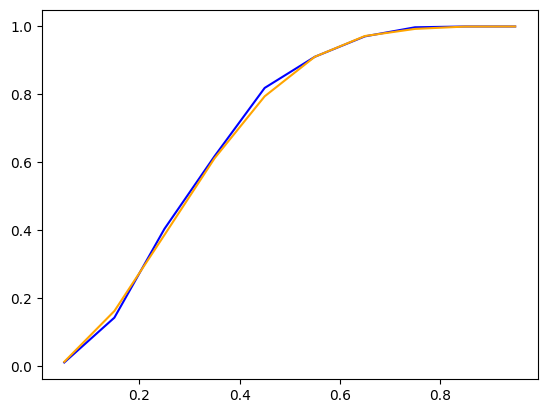

In [ ]:
print("external model: ", model_function.__name__)
print("mcdp model: ", model_function_mcdp.__name__)
#print("la model: ", model_function_la.__name__)
print("\n")
plot_confidence(study_inputs, study_labels, n_models=5, mode_type="external", model_datasize=model_datasize,
                create_model_function=model_function, end_plotting=False, color=colors[0], output_shape=(max(full_labels)+1))

plot_confidence(study_inputs, study_labels, n_models=n_models, mode_type="external", model_datasize=model_datasize,
                create_model_function=model_function, end_plotting=False, color=colors[1], output_shape=(max(full_labels)+1))

plot_confidence(study_inputs, study_labels, n_models=n_models, mode_type="dp",
                create_model_function=model_function_mcdp, end_plotting=False, color=colors[2], output_shape=(max(full_labels)+1))

plot_confidence(study_inputs, study_labels, n_models=1000, mode_type="la",
                create_model_function=model_function_la, end_plotting=False, color=colors[3], output_shape=(max(full_labels)+1))

plot_confidence(study_inputs, study_labels, n_models=20, mode_type="vi",
                create_model_function=model_function, end_plotting=False, color=colors[4], output_shape=(max(full_labels)+1))

plot_confidence(study_inputs, study_labels, n_models=20, mode_type="swag",
                create_model_function=model_function, end_plotting=True, color=colors[5], output_shape=(max(full_labels)+1))


## Plot Flatness of models:

In [ ]:
def compute_flatness_tf(model, x, y, n_samples=512, mode="normal", use_logits=False):
    """
    Estimates the loss landscape flatness of a TensorFlow model using random
    Hessian-vector products (Hutchinson's stochastic trace estimator).
    Returns the average curvature and model loss.
    """

    if mode == "dp":
        for layer in model.layers:
            if isinstance(layer, tf.keras.layers.BatchNormalization):
                layer.trainable = False
        training = True
    else:
        training = False
    n_batches= find_divisor(len(y))

    loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=use_logits)
    tf_vars = get_tf_vars(model)
    x = tf.convert_to_tensor(x)
    y = tf.convert_to_tensor(y)

    batch_losses = []
    for i in range(0, len(y), n_batches):
        xb, yb = x[i:i+n_batches], y[i:i+n_batches]
        batch_losses.append(float(loss_fn(yb, model(xb, training=training))))
    loss_val = float(np.mean(batch_losses))

    vhv_samples = []
    for _ in range(n_samples):
        vs = [2 * tf.cast(tf.random.uniform(tf.shape(v)) > 0.5, v.dtype) - 1
              for v in tf_vars]

        batch_vhvs = []
        for i in range(0, len(y), n_batches):
            xb, yb = x[i:i+n_batches], y[i:i+n_batches]

            with tf.GradientTape() as tape:
                with tf.autodiff.ForwardAccumulator(primals=tf_vars, tangents=vs) as acc:
                    outputs = model(xb, training=training)
                    loss = loss_fn(yb, outputs)
                jvp = acc.jvp(loss)

            hvp = tape.gradient(jvp, tf_vars)
            vhv = sum(tf.reduce_sum(vi * hvi) for vi, hvi in zip(vs, hvp))
            batch_vhvs.append(vhv)

        vhv_samples.append(tf.reduce_mean(tf.stack(batch_vhvs)))

    return float(tf.reduce_mean(tf.stack(vhv_samples))), loss_val

In [ ]:
def compute_flatness_torch(model, x, y, n_samples=512):
    """
    Estimates the loss landscape flatness of a Torch model using random
    Hessian-vector products (Hutchinson's stochastic trace estimator).
    Returns the average curvature and model loss.
    """

    loss_fn = torch.nn.CrossEntropyLoss()

    n_batches = find_divisor(len(y))
    was_training = model.training
    model.eval()

    device = next(model.parameters()).device

    if not isinstance(x, torch.Tensor):
        x = torch.as_tensor(x)
        if x.ndim == 4 and x.shape[-1] in (1, 3):
            x = x.permute(0, 3, 1, 2).contiguous()
    if not isinstance(y, torch.Tensor):
        y = torch.as_tensor(y, dtype=torch.long)

    x = x.to(device)
    y = y.to(device)

    params = [p for p in model.parameters() if p.requires_grad]

    with torch.no_grad():
        batch_losses = []
        for i in range(0, len(y), n_batches):
            xb, yb = x[i:i+n_batches], y[i:i+n_batches]
            batch_losses.append(loss_fn(model(xb), yb).item())
        loss_val = float(np.mean(batch_losses))

    vhv_samples = []
    for _ in range(n_samples):
        vs = [2 * (torch.rand_like(p) > 0.5).to(p.dtype) - 1 for p in params]

        batch_vhvs = []
        for i in range(0, len(y), n_batches):
            xb, yb = x[i:i+n_batches], y[i:i+n_batches]

            outputs = model(xb)
            loss = loss_fn(outputs, yb)
            grads = torch.autograd.grad(loss, params, create_graph=True)

            jvp = sum((g * vi).sum() for g, vi in zip(grads, vs))
            hvp = torch.autograd.grad(jvp, params)  # = Hv

            vhv = sum((vi * hvi).sum() for vi, hvi in zip(vs, hvp))
            batch_vhvs.append(vhv.item())

        vhv_samples.append(float(np.mean(batch_vhvs)))

    model.train(was_training)
    return float(np.mean(vhv_samples)), loss_val

In [ ]:
def plot_flattness_comparison(model_type, data_inputs, data_labels, n_samples=512, model_datasize=-1, n_models=1, model_name=None, create_model_function=None, end_plotting=True, color="orange", output_shape=10):
    """
    Computes and plots the relationship between model loss and loss-landscape
    flatness for one or multiple models of a given type.
    """
    use_logits = False
    if model_name == None:
        model_name = create_model_function.__name__

    flatness_scores = np.zeros(n_models)
    baseline_losses = np.zeros(n_models)
    for n in range(n_models):
        if model_type == "external":
            # Check if folder exists:
            path = f"{BASE_DIR}/saved_models_external"
            os.makedirs(path, exist_ok=True)
            model = tf.keras.models.load_model(f"{path}/shadow_model_offline_TOT_points={model_datasize},{n}_external_{model_name}.keras", compile=True)
        elif model_type == "dp":
            # Check if folder exists:
            path = f"{BASE_DIR}/saved_models_dp"
            os.makedirs(path, exist_ok=True)
            model = tf.keras.models.load_model(f"{path}/shadow_model_offline_{model_name}.keras", compile=True)
        elif model_type == "la":

            input_shape = data_inputs.shape[1:]
            la_model, model = load_laplace(create_model_function, input_shape, output_shape, model_name=model_name, load_model=True)

            flatness_scores, baseline_losses = compute_flatness_torch(model, data_inputs, data_labels, n_samples=n_samples)
            break

        elif model_type == "vi":
            use_logits = True
            # Check if folder exists:
            path = f"{BASE_DIR}/saved_models_vi"
            os.makedirs(path, exist_ok=True)

            model = create_model_function(input_shape=data_inputs.shape[1:], output_shape = output_shape, training=False, use_logits=True)

            trainer = GFSVITrainer(
                model,
                num_classes=output_shape,
            )

            trainer.load(model_name)

            model = trainer.model
        elif model_type == "swag":
            # Check if folder exists:
            path = f"{BASE_DIR}/saved_models_swag"
            os.makedirs(path, exist_ok=True)
            model = tf.keras.models.load_model(f"{path}/shadow_model_offline,{n}_{model_name}.keras", compile=True)
        else:
            raise ValueError(f"Unknown model type: {model_type}")

        flatness_scores[n], baseline_losses[n] = compute_flatness_tf(model, data_inputs, data_labels, n_samples=n_samples, mode=model_type, use_logits=use_logits)

    flatness_scores = np.squeeze(flatness_scores)
    baseline_losses = np.squeeze(baseline_losses)

    plt.plot(baseline_losses, flatness_scores, linestyle='None', marker='o', color=color, label=f"{model_type} - {model_name} with average flatness={np.mean(flatness_scores):.2f}")
    if end_plotting:
            plt.xlabel("model loss")
            plt.ylabel("flatness at the optimum")
            plt.legend(fontsize=7)
            plt.tight_layout()
            plt.grid()
            plt.show()

### Study flatness of models

In [ ]:
i=0
study_inputs = full_inputs[1000*i:1000*(i+1), :]
study_labels = full_labels[1000*i:1000*(i+1)]
num_samples_flatness = 256
colors = ["orange", "red", "black", "green", "purple"]

external model:  resnet_model
mcdp model:  drop_out_resnet_model
la model:  laplace_resnet_model


Do dp:




/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'SGD', because it has 27 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Do LA:


Do VI:


Do SWAG:




/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'SGD', because it has 25 variables whereas the saved optimizer has 67 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


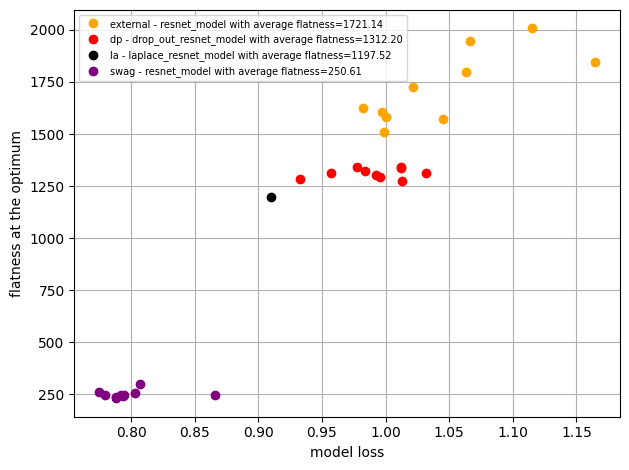

In [ ]:
print("external model: ", model_function.__name__)
print("mcdp model: ", model_function_mcdp.__name__)
print("la model: ", model_function_la.__name__)
print("\n")

plot_flattness_comparison("external", study_inputs, study_labels, n_samples=num_samples_flatness, model_datasize=model_datasize,
                n_models=10, create_model_function=model_function, end_plotting=False, color=colors[0],
                output_shape=(max(full_labels)+1))

print("Do dp:")
print("\n")
plot_flattness_comparison("dp", study_inputs, study_labels, n_samples=num_samples_flatness,
                          n_models=10, create_model_function=drop_out_resnet_model, end_plotting=False, color=colors[1],
                output_shape=(max(full_labels)+1))
print("Do LA:")
print("\n")
plot_flattness_comparison("la", study_inputs, study_labels, n_samples=num_samples_flatness,
                create_model_function=model_function_la, end_plotting=False, color=colors[2], output_shape=(max(full_labels)+1))
print("Do VI:")
print("\n")
plot_flattness_comparison("vi", study_inputs, study_labels, n_samples=num_samples_flatness,
                create_model_function=model_function, end_plotting=False, color=colors[3],
                 output_shape=(max(full_labels)+1))
print("Do SWAG:")
print("\n")
plot_flattness_comparison("swag", study_inputs, study_labels, n_samples=num_samples_flatness,
                          n_models=10, create_model_function=model_function, end_plotting=True, color=colors[4], output_shape=(max(full_labels)+1))


## Weights Distribution Analysis

In [84]:
def plot_shadow_models_weights(n_models, chosen_w=-1, dataset_size=-1, model_name=None, model_function=None, seed=None):
    """
    Loads multiple shadow models and plots the distribution of a selected
    weight parameter across the models to visualize weight variability.
    """

    if model_name is None:
        model_name = model_function.__name__

    # Check if folder exists:
    path = f"{BASE_DIR}/saved_models_external"
    os.makedirs(path, exist_ok=True)

    current_model = tf.keras.models.load_model(
        f"{path}/shadow_model_offline_TOT_points={dataset_size},{0}_external_{model_name}.keras",
        compile=True
    )
    tot_len = 0
    for var in current_model.trainable_variables:
        if var.name != "gamma" and var.name != "beta":
            tot_len += len(var.numpy().flatten())
    print("Total size of the model: ", tot_len)

    if chosen_w < 0:
        chosen_w = np.random.randint(0, tot_len)
    var_array = np.zeros(n_models)

    for n in range(n_models):
        current_model = tf.keras.models.load_model(
            f"{path}/shadow_model_offline_TOT_points={dataset_size},{n}_external_{model_name}.keras",
            compile=True
        )
        i_shift = 0
        for var in current_model.trainable_variables:
            if var.name != "gamma" and var.name != "beta":
                var_len = len(var.numpy().flatten())
                if i_shift + var_len < chosen_w:
                    i_shift += var_len
                    continue
                var_array[n] = var.numpy().flatten()[chosen_w - i_shift]
                break

    mean_val = np.mean(var_array)
    std_val = np.std(var_array)

    plt.hist(var_array, bins=30, density=True, alpha=0.7, edgecolor="black", label="histogram")

    x_vals = np.linspace(np.min(var_array), np.max(var_array), 1000)

    gauss = 1 / (np.sqrt(2 * np.pi) * std_val) * np.exp(-0.5 * ((x_vals - mean_val) / std_val) ** 2)
    plt.plot(x_vals, gauss, linewidth=2, label="gaussian fit")

    plt.xlabel(f"{chosen_w}th weight's values")
    plt.ylabel("probability density")
    plt.legend()
    plt.tight_layout()
    plt.show()

### Study Weight Distribution

Total size of the model:  11147114


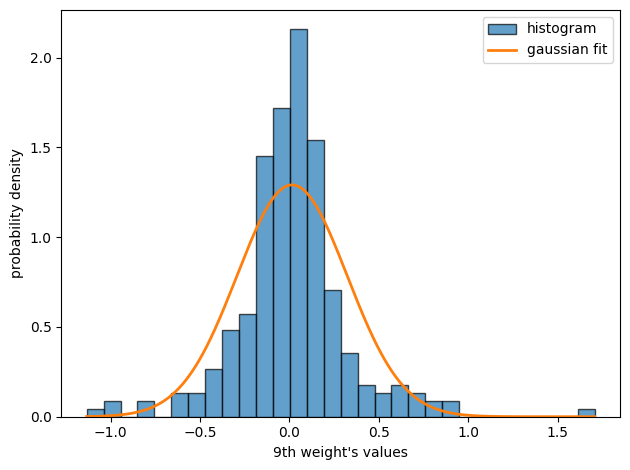

In [76]:
model_datasize= 146154 # Cinic10
chosen_w = 9
plot_shadow_models_weights(n_models=240, chosen_w=chosen_w, dataset_size=model_datasize, model_function=model_function, seed=41)

Total size of the model:  11147114


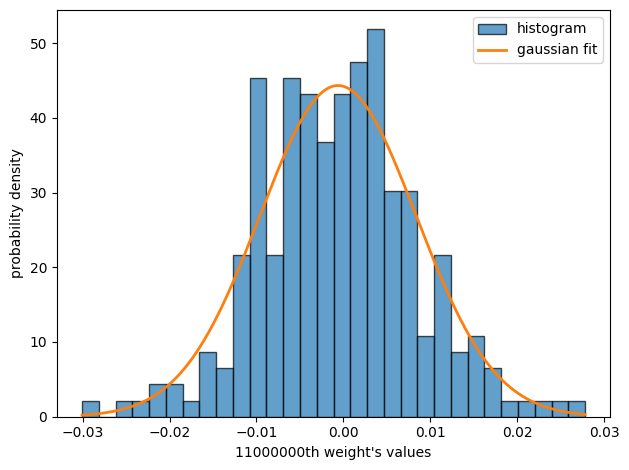

In [73]:
model_datasize= 146154 # Cinic10
chosen_w = 11000000
plot_shadow_models_weights(n_models=240, chosen_w=chosen_w, dataset_size=model_datasize, model_function=model_function, seed=41)

# Optional functions

### Define Large Convolutional Neural Network

In [ ]:
def mixup(batch_x, batch_y, out_shape, alpha=0.2):
    # batch_x: [B,H,W,C], batch_y: integer labels
    lam = np.random.beta(alpha, alpha)
    B = tf.shape(batch_x)[0]
    idx = tf.random.shuffle(tf.range(B))
    x2 = tf.gather(batch_x, idx)
    y2 = tf.gather(batch_y, idx)
    x = lam * batch_x + (1.0 - lam) * x2
    # one-hot labels with mixing
    y = tf.one_hot(batch_y, depth=out_shape) * lam + tf.one_hot(y2, depth=out_shape) * (1.0 - lam)
    return x, y

In [ ]:
def cnn_complex100_model(input_shape=(32, 32, 3), output_shape = 100, kernel_size=(2,2), train_inputs = np.array([]), train_labels = np.array([]),
                             epochs=24, batch_size=128,  mixup_prob=0.7, training=True, verbose=False, augmentation=True, sample_weights=False, use_logits=False):
    """
    Assumes images as unnormalized inputs and N separate labels as probability outcomes
    """
    # Random seed:
    if sample_weights:
        start_count = (epochs) * len(train_inputs) // batch_size - 200
        weight_stats = WeightStatsCallback(start_count=start_count, k=20, skip_batches=5)

    if len(train_inputs) != 0:
        if np.abs(np.max(train_inputs)) <= 1:
            raise warnings.warn("The input seems to be normalized, while the model expects an unnormalized input")

    seed = int(np.random.randint(0, 2**31 - 1))
    ki = tf.keras.initializers.HeNormal(seed=seed)

    model = tf.keras.Sequential([
        tf.keras.layers.Rescaling(1./255),

        tf.keras.layers.Conv2D(64, kernel_size, padding="same", activation="relu",
                               input_shape=input_shape, kernel_initializers=ki, kernel_regularizer=regularizers.l2(1e-4)),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Conv2D(64, kernel_size, padding="same",
                               activation="relu", kernel_initializers=ki, kernel_regularizer=regularizers.l2(1e-4)),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D((2,2)),

        tf.keras.layers.Conv2D(128, kernel_size, padding="same",
                               activation="relu",  kernel_initializers=ki, kernel_regularizer=regularizers.l2(1e-4)),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Conv2D(128, kernel_size, padding="same",
                               activation="relu",  kernel_initializers=ki, kernel_regularizer=regularizers.l2(1e-4)),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D((2,2)),

        tf.keras.layers.Conv2D(256, kernel_size, padding="same",
                               activation="relu",  kernel_initializers=ki, kernel_regularizer=regularizers.l2(1e-4)),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Conv2D(256, kernel_size, padding="same",
                               activation="relu",  kernel_initializers=ki, kernel_regularizer=regularizers.l2(1e-4)),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D((2,2)),

        tf.keras.layers.GlobalAveragePooling2D(),
        tf.keras.layers.Dense(512,  kernel_initializers=ki, activation="relu"),
        tf.keras.layers.Dense(int(output_shape),  kernel_initializers=ki, activation=None if use_logits else "softmax")
        ])

    if sample_weights:
        optimizer = tf.keras.optimizers.SGD(learning_rate=0.05, momentum=0.9)
    else:
        optimizer=tf.keras.optimizers.SGD(
            learning_rate=0.01, momentum=0.9, nesterov=True
        )

    loss = tf.keras.losses.CategoricalCrossentropy()
    model.compile(optimizer=optimizer, loss=loss, metrics=['accuracy'])


    if training and np.ndim(train_inputs) == 4 and np.ndim(train_labels) == 1:
        AUTOTUNE = tf.data.AUTOTUNE
        if augmentation:
            # augmented training
            data_augmentation = tf.keras.Sequential([
                tf.keras.layers.RandomFlip("horizontal"),
                tf.keras.layers.RandomRotation(0.06),        # ~±2% of a full rotation (~±6°)
                tf.keras.layers.Resizing(36, 36),
                tf.keras.layers.RandomCrop(32, 32),
                ], name="data_augmentation")

            def apply_mixup(xb, yb, out_shape = int(output_shape)):
              if tf.random.uniform([]) < mixup_prob:
                  xb2, yb2 = tf.py_function(func=mixup, inp=[xb, yb, out_shape], Tout=[tf.float32, tf.float32])
                  xb2.set_shape(xb.shape)
                  yb2.set_shape([xb.shape[0], out_shape])
                  return xb2, yb2
              else:
                  return xb, tf.one_hot(yb, out_shape)

            ds = tf.data.Dataset.from_tensor_slices((train_inputs, train_labels))
            ds  = ds.map(lambda x, y: (data_augmentation(x, training=True), y), num_parallel_calls=AUTOTUNE)
            ds = ds.batch(batch_size).prefetch(AUTOTUNE)
            ds = ds.map(apply_mixup, num_parallel_calls=AUTOTUNE)

            if verbose:
                if sample_weights:
                    model.fit(ds, epochs=epochs, callbacks=[weight_stats], verbose=2)
                else:
                    model.fit(ds, epochs=epochs, verbose=2)
            else:
                if sample_weights:
                    model.fit(ds, epochs=epochs, callbacks=[weight_stats], verbose=0)
                else:
                    model.fit(ds, epochs=epochs, verbose=0)


        loss = tf.keras.losses.SparseCategoricalCrossentropy()
        model.compile(optimizer=optimizer, loss=loss, metrics=['accuracy'])
        ds = tf.data.Dataset.from_tensor_slices((train_inputs, train_labels))
        ds = ds.batch(batch_size).prefetch(AUTOTUNE)
        epochs=2
        if verbose:
            if sample_weights:
                model.fit(ds, epochs=epochs, callbacks=[weight_stats], verbose=2)
            else:
                model.fit(ds, epochs=epochs, verbose=2)
        else:
            if sample_weights:
                model.fit(ds, epochs=epochs, callbacks=[weight_stats], verbose=0)
            else:
                model.fit(ds, epochs=epochs, verbose=0)

    if sample_weights:
        return model, weight_stats

    else:
        return model

### Define Large Convolutional Neural Network

In [ ]:
def mixup(batch_x, batch_y, out_shape, alpha=0.2):
    # batch_x: [B,H,W,C], batch_y: integer labels
    lam = np.random.beta(alpha, alpha)
    B = tf.shape(batch_x)[0]
    idx = tf.random.shuffle(tf.range(B))
    x2 = tf.gather(batch_x, idx)
    y2 = tf.gather(batch_y, idx)
    x = lam * batch_x + (1.0 - lam) * x2
    # one-hot labels with mixing
    y = tf.one_hot(batch_y, depth=out_shape) * lam + tf.one_hot(y2, depth=out_shape) * (1.0 - lam)
    return x, y

In [ ]:
def cnn_complex100_model(input_shape=(32, 32, 3), output_shape = 100, kernel_size=(2,2), train_inputs = np.array([]), train_labels = np.array([]),
                             epochs=24, batch_size=128,  mixup_prob=0.7, training=True, verbose=False, augmentation=True, sample_weights=False, use_logits=False):
    """
    Assumes images as unnormalized inputs and N separate labels as probability outcomes
    """
    # Random seed:
    if sample_weights:
        start_count = (epochs) * len(train_inputs) // batch_size - 200
        weight_stats = WeightStatsCallback(start_count=start_count, k=20, skip_batches=5)

    if len(train_inputs) != 0:
        if np.abs(np.max(train_inputs)) <= 1:
            raise warnings.warn("The input seems to be normalized, while the model expects an unnormalized input")

    seed = int(np.random.randint(0, 2**31 - 1))
    ki = tf.keras.initializers.HeNormal(seed=seed)

    model = tf.keras.Sequential([
        tf.keras.layers.Rescaling(1./255),

        tf.keras.layers.Conv2D(64, kernel_size, padding="same", activation="relu",
                               input_shape=input_shape, kernel_initializers=ki, kernel_regularizer=regularizers.l2(1e-4)),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Conv2D(64, kernel_size, padding="same",
                               activation="relu", kernel_initializers=ki, kernel_regularizer=regularizers.l2(1e-4)),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D((2,2)),

        tf.keras.layers.Conv2D(128, kernel_size, padding="same",
                               activation="relu",  kernel_initializers=ki, kernel_regularizer=regularizers.l2(1e-4)),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Conv2D(128, kernel_size, padding="same",
                               activation="relu",  kernel_initializers=ki, kernel_regularizer=regularizers.l2(1e-4)),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D((2,2)),

        tf.keras.layers.Conv2D(256, kernel_size, padding="same",
                               activation="relu",  kernel_initializers=ki, kernel_regularizer=regularizers.l2(1e-4)),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Conv2D(256, kernel_size, padding="same",
                               activation="relu",  kernel_initializers=ki, kernel_regularizer=regularizers.l2(1e-4)),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D((2,2)),

        tf.keras.layers.GlobalAveragePooling2D(),
        tf.keras.layers.Dense(512,  kernel_initializers=ki, activation="relu"),
        tf.keras.layers.Dense(int(output_shape),  kernel_initializers=ki, activation=None if use_logits else "softmax")
        ])

    if sample_weights:
        optimizer = tf.keras.optimizers.SGD(learning_rate=0.05, momentum=0.9)
    else:
        optimizer=tf.keras.optimizers.SGD(
            learning_rate=0.01, momentum=0.9, nesterov=True
        )

    loss = tf.keras.losses.CategoricalCrossentropy()
    model.compile(optimizer=optimizer, loss=loss, metrics=['accuracy'])


    if training and np.ndim(train_inputs) == 4 and np.ndim(train_labels) == 1:
        AUTOTUNE = tf.data.AUTOTUNE
        if augmentation:
            # augmented training
            data_augmentation = tf.keras.Sequential([
                tf.keras.layers.RandomFlip("horizontal"),
                tf.keras.layers.RandomRotation(0.06),        # ~±2% of a full rotation (~±6°)
                tf.keras.layers.Resizing(36, 36),
                tf.keras.layers.RandomCrop(32, 32),
                ], name="data_augmentation")

            def apply_mixup(xb, yb, out_shape = int(output_shape)):
              if tf.random.uniform([]) < mixup_prob:
                  xb2, yb2 = tf.py_function(func=mixup, inp=[xb, yb, out_shape], Tout=[tf.float32, tf.float32])
                  xb2.set_shape(xb.shape)
                  yb2.set_shape([xb.shape[0], out_shape])
                  return xb2, yb2
              else:
                  return xb, tf.one_hot(yb, out_shape)

            ds = tf.data.Dataset.from_tensor_slices((train_inputs, train_labels))
            ds  = ds.map(lambda x, y: (data_augmentation(x, training=True), y), num_parallel_calls=AUTOTUNE)
            ds = ds.batch(batch_size).prefetch(AUTOTUNE)
            ds = ds.map(apply_mixup, num_parallel_calls=AUTOTUNE)

            if verbose:
                if sample_weights:
                    model.fit(ds, epochs=epochs, callbacks=[weight_stats], verbose=2)
                else:
                    model.fit(ds, epochs=epochs, verbose=2)
            else:
                if sample_weights:
                    model.fit(ds, epochs=epochs, callbacks=[weight_stats], verbose=0)
                else:
                    model.fit(ds, epochs=epochs, verbose=0)


        loss = tf.keras.losses.SparseCategoricalCrossentropy()
        model.compile(optimizer=optimizer, loss=loss, metrics=['accuracy'])
        ds = tf.data.Dataset.from_tensor_slices((train_inputs, train_labels))
        ds = ds.batch(batch_size).prefetch(AUTOTUNE)
        epochs=2
        if verbose:
            if sample_weights:
                model.fit(ds, epochs=epochs, callbacks=[weight_stats], verbose=2)
            else:
                model.fit(ds, epochs=epochs, verbose=2)
        else:
            if sample_weights:
                model.fit(ds, epochs=epochs, callbacks=[weight_stats], verbose=0)
            else:
                model.fit(ds, epochs=epochs, verbose=0)

    if sample_weights:
        return model, weight_stats

    else:
        return model

## Alternative MC Dropout ResNet models

### 0

In [ ]:
def build_dp_resnet_alt(input_shape=(32, 32, 3), num_classes=10, weight_decay=1e-4, drop_out_rate = 0.00):
    inputs = tf.keras.layers.Input(shape=input_shape)
    inputs = tf.keras.layers.Rescaling(1./127.5, offset=-1)(inputs)

    x = tf.keras.layers.Conv2D(
        32, kernel_size=3, strides=1, padding="same", use_bias=False, ############### changed from 128
        kernel_regularizer=tf.keras.regularizers.l2(weight_decay)
    )(inputs)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.ReLU()(x)

    x = dp_residual_block(x, 64, drop_out_rate = drop_out_rate)
    x = dp_residual_block(x, 64, drop_out_rate = drop_out_rate)

    x = dp_residual_block(x, 128, stride=2, drop_out_rate = drop_out_rate)
    x = dp_residual_block(x, 128, drop_out_rate = drop_out_rate)

    x = dp_residual_block(x, 256, stride=2, drop_out_rate = drop_out_rate)
    x = dp_residual_block(x, 256, drop_out_rate = drop_out_rate)

    x = dp_residual_block(x, 512, stride=2, drop_out_rate = drop_out_rate)
    x = dp_residual_block(x, 512, drop_out_rate = drop_out_rate, last_layer=1024)

    x = tf.keras.layers.GlobalAveragePooling2D()(x)

    outputs = tf.keras.layers.Dense(num_classes, activation="softmax")(x)

    return tf.keras.models.Model(inputs, outputs)

def alt_drop_out_resnet_model(input_shape=(32, 32, 3), output_shape = 10, train_inputs = np.array([]), train_labels = np.array([]), epochs=9, batch_size=128, training=True, verbose=False):
    model = build_dp_resnet_alt(input_shape=input_shape, num_classes=int(output_shape))

    model.compile(
        optimizer=tf.keras.optimizers.SGD(
            learning_rate=0.1, momentum=0.9, nesterov=True
        ),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(),
        metrics=["accuracy"]
    )
    callbacks = [
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="loss", factor=0.1, patience=5, verbose=1
    )
    ]

    if training and np.ndim(train_inputs) == 4 and np.ndim(train_labels) == 1:
        AUTOTUNE = tf.data.AUTOTUNE
        # training set creation
        ds = tf.data.Dataset.from_tensor_slices((train_inputs, train_labels))
        ds = ds.shuffle(buffer_size=len(train_inputs))
        ds = ds .batch(batch_size).prefetch(AUTOTUNE)
        if verbose:
            with tf.device('/GPU:0'):
                history = model.fit(ds, epochs=epochs, callbacks=callbacks, verbose=2)
        else:
            with tf.device('/GPU:0'):
                history = model.fit(ds, epochs=epochs, callbacks=callbacks, verbose=0)

        model.compile(
        optimizer=tf.keras.optimizers.SGD(
            learning_rate=0.01, momentum=0.9, nesterov=True
        ),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(),
        metrics=["accuracy"]
        )
        if verbose:
            with tf.device('/GPU:0'):
                history = model.fit(ds, epochs=5, callbacks=callbacks, verbose=2)
        else:
            with tf.device('/GPU:0'):
                history = model.fit(ds, epochs=5, callbacks=callbacks, verbose=0)

        for layer in model.layers:
                if isinstance(layer, tf.keras.layers.BatchNormalization):
                    layer.trainable = False

        model.compile(
        optimizer=tf.keras.optimizers.SGD(
            learning_rate=0.01, momentum=0.9, nesterov=True
        ),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(),
        metrics=["accuracy"]
        )
        '''
        if verbose:
            with tf.device('/GPU:0'):
                history = model.fit(ds, epochs=epochs, callbacks=callbacks, verbose=2)
        else:
            with tf.device('/GPU:0'):
                history = model.fit(ds, epochs=epochs, callbacks=callbacks, verbose=0)


        for layer in model.layers:
                if isinstance(layer, tf.keras.layers.BatchNormalization):
                    layer.trainable = False

        model.compile(
        optimizer=tf.keras.optimizers.SGD(
            learning_rate=0.01, momentum=0.9, nesterov=True
        ),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(),
        metrics=["accuracy"]
        )
        '''
    return model

### 1

In [ ]:
def build_dp_resnet_alt1(input_shape=(32, 32, 3), num_classes=10, weight_decay=1e-4, drop_out_rate = 0.00):
    inputs = tf.keras.layers.Input(shape=input_shape)
    inputs = tf.keras.layers.Rescaling(1./127.5, offset=-1)(inputs)

    x = tf.keras.layers.Conv2D(
        32, kernel_size=3, strides=1, padding="same", use_bias=False, ############### changed from 128
        kernel_regularizer=tf.keras.regularizers.l2(weight_decay)
    )(inputs)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.ReLU()(x)

    x = dp_residual_block(x, 64, drop_out_rate = drop_out_rate)
    x = dp_residual_block(x, 64, drop_out_rate = drop_out_rate)

    x = dp_residual_block(x, 128, stride=2, drop_out_rate = drop_out_rate)
    x = dp_residual_block(x, 128, drop_out_rate = drop_out_rate)

    x = dp_residual_block(x, 256, stride=2, drop_out_rate = drop_out_rate)
    x = dp_residual_block(x, 256, drop_out_rate = drop_out_rate)

    x = dp_residual_block(x, 512, stride=2, drop_out_rate = drop_out_rate)
    x = dp_residual_block(x, 1024, drop_out_rate = 0.75, last_layer_dropout=0.75)
    outputs = tf.keras.layers.GlobalAveragePooling2D()(x)
    outputs = tf.keras.layers.Dense(num_classes, activation="softmax")(outputs)

    return tf.keras.models.Model(inputs, outputs)

def alt1_drop_out_resnet_model(input_shape=(32, 32, 3), output_shape = 10, train_inputs = np.array([]), train_labels = np.array([]), epochs=9, batch_size=128, training=True, verbose=False):
    model = build_dp_resnet_alt1(input_shape=input_shape, num_classes=int(output_shape))

    model.compile(
        optimizer=tf.keras.optimizers.SGD(
            learning_rate=0.1, momentum=0.9, nesterov=True
        ),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(),
        metrics=["accuracy"]
    )
    callbacks = [
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="loss", factor=0.1, patience=5, verbose=1
    )
    ]

    if training and np.ndim(train_inputs) == 4 and np.ndim(train_labels) == 1:
        AUTOTUNE = tf.data.AUTOTUNE
        # training set creation
        ds = tf.data.Dataset.from_tensor_slices((train_inputs, train_labels))
        ds = ds.shuffle(buffer_size=len(train_inputs))
        ds = ds .batch(batch_size).prefetch(AUTOTUNE)
        if verbose:
            with tf.device('/GPU:0'):
                history = model.fit(ds, epochs=epochs, callbacks=callbacks, verbose=2)
        else:
            with tf.device('/GPU:0'):
                history = model.fit(ds, epochs=epochs, callbacks=callbacks, verbose=0)

        model.compile(
        optimizer=tf.keras.optimizers.SGD(
            learning_rate=0.01, momentum=0.9, nesterov=True
        ),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(),
        metrics=["accuracy"]
        )
        if verbose:
            with tf.device('/GPU:0'):
                history = model.fit(ds, epochs=epochs, callbacks=callbacks, verbose=2)
        else:
            with tf.device('/GPU:0'):
                history = model.fit(ds, epochs=epochs, callbacks=callbacks, verbose=0)

        for layer in model.layers:
                if isinstance(layer, tf.keras.layers.BatchNormalization):
                    layer.trainable = False

        model.compile(
        optimizer=tf.keras.optimizers.SGD(
            learning_rate=0.01, momentum=0.9, nesterov=True
        ),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(),
        metrics=["accuracy"]
        )
        '''
        if verbose:
            with tf.device('/GPU:0'):
                history = model.fit(ds, epochs=epochs, callbacks=callbacks, verbose=2)
        else:
            with tf.device('/GPU:0'):
                history = model.fit(ds, epochs=epochs, callbacks=callbacks, verbose=0)


        for layer in model.layers:
                if isinstance(layer, tf.keras.layers.BatchNormalization):
                    layer.trainable = False

        model.compile(
        optimizer=tf.keras.optimizers.SGD(
            learning_rate=0.01, momentum=0.9, nesterov=True
        ),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(),
        metrics=["accuracy"]
        )
        '''
    return model

### 2

In [ ]:
def build_dp_resnet_alt2(input_shape=(32, 32, 3), num_classes=10, weight_decay=1e-4, drop_out_rate = 0.00):
    inputs = tf.keras.layers.Input(shape=input_shape)
    inputs = tf.keras.layers.Rescaling(1./127.5, offset=-1)(inputs)

    x = tf.keras.layers.Conv2D(
        32, kernel_size=3, strides=1, padding="same", use_bias=False, ############### changed from 128
        kernel_regularizer=tf.keras.regularizers.l2(weight_decay)
    )(inputs)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.ReLU()(x)

    x = dp_residual_block(x, 64, drop_out_rate = drop_out_rate)
    x = dp_residual_block(x, 64, drop_out_rate = drop_out_rate)

    x = dp_residual_block(x, 128, stride=2, drop_out_rate = drop_out_rate)
    x = dp_residual_block(x, 128, drop_out_rate = drop_out_rate)

    x = dp_residual_block(x, 256, stride=2, drop_out_rate = drop_out_rate)
    x = dp_residual_block(x, 256, drop_out_rate = drop_out_rate)

    x = dp_residual_block(x, 512, stride=2, drop_out_rate = drop_out_rate, last_layer=512)
    x = tf.layers.Dropout(0.72)(x)
    x = dp_residual_block(x, 1024, drop_out_rate = 0.72)

    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    outputs = tf.keras.layers.Dense(num_classes, activation="softmax")(x)

    return tf.keras.models.Model(inputs, outputs)

def alt2_drop_out_resnet_model(input_shape=(32, 32, 3), output_shape = 10, train_inputs = np.array([]), train_labels = np.array([]), epochs=9, batch_size=128, training=True, verbose=False):
    model = build_dp_resnet_alt2(input_shape=input_shape, num_classes=int(output_shape))

    model.compile(
        optimizer=tf.keras.optimizers.SGD(
            learning_rate=0.1, momentum=0.9, nesterov=True
        ),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(),
        metrics=["accuracy"]
    )
    callbacks = [
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="loss", factor=0.1, patience=5, verbose=1
    )
    ]

    if training and np.ndim(train_inputs) == 4 and np.ndim(train_labels) == 1:
        AUTOTUNE = tf.data.AUTOTUNE
        # training set creation
        ds = tf.data.Dataset.from_tensor_slices((train_inputs, train_labels))
        ds = ds.shuffle(buffer_size=len(train_inputs))
        ds = ds .batch(batch_size).prefetch(AUTOTUNE)
        if verbose:
            with tf.device('/GPU:0'):
                history = model.fit(ds, epochs=epochs, callbacks=callbacks, verbose=2)
        else:
            with tf.device('/GPU:0'):
                history = model.fit(ds, epochs=epochs, callbacks=callbacks, verbose=0)

        model.compile(
        optimizer=tf.keras.optimizers.SGD(
            learning_rate=0.01, momentum=0.9, nesterov=True
        ),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(),
        metrics=["accuracy"]
        )
        if verbose:
            with tf.device('/GPU:0'):
                history = model.fit(ds, epochs=epochs, callbacks=callbacks, verbose=2)
        else:
            with tf.device('/GPU:0'):
                history = model.fit(ds, epochs=epochs, callbacks=callbacks, verbose=0)

        for layer in model.layers:
                if isinstance(layer, tf.keras.layers.BatchNormalization):
                    layer.trainable = False

        model.compile(
        optimizer=tf.keras.optimizers.SGD(
            learning_rate=0.01, momentum=0.9, nesterov=True
        ),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(),
        metrics=["accuracy"]
        )
        '''
        if verbose:
            with tf.device('/GPU:0'):
                history = model.fit(ds, epochs=epochs, callbacks=callbacks, verbose=2)
        else:
            with tf.device('/GPU:0'):
                history = model.fit(ds, epochs=epochs, callbacks=callbacks, verbose=0)


        for layer in model.layers:
                if isinstance(layer, tf.keras.layers.BatchNormalization):
                    layer.trainable = False

        model.compile(
        optimizer=tf.keras.optimizers.SGD(
            learning_rate=0.01, momentum=0.9, nesterov=True
        ),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(),
        metrics=["accuracy"]
        )
        '''
    return model

### 3

In [ ]:
def build_dp_resnet_alt3(input_shape=(32, 32, 3), num_classes=10, weight_decay=1e-4, drop_out_rate = 0.00):
    inputs = tf.keras.layers.Input(shape=input_shape)
    inputs = tf.keras.layers.Rescaling(1./127.5, offset=-1)(inputs)

    x = tf.keras.layers.Conv2D(
        32, kernel_size=3, strides=1, padding="same", use_bias=False, ############### changed from 128
        kernel_regularizer=tf.keras.regularizers.l2(weight_decay)
    )(inputs)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.ReLU()(x)

    x = dp_residual_block(x, 64, drop_out_rate = drop_out_rate)
    x = dp_residual_block(x, 64, drop_out_rate = drop_out_rate)

    x = dp_residual_block(x, 128, stride=2, drop_out_rate = drop_out_rate)
    x = dp_residual_block(x, 128, drop_out_rate = drop_out_rate)

    x = dp_residual_block(x, 256, stride=2, drop_out_rate = drop_out_rate)
    x = dp_residual_block(x, 256, drop_out_rate = drop_out_rate)

    x = dp_residual_block(x, 1024, stride=2, drop_out_rate = 0.72)
    x = dp_residual_block(x, 1024, drop_out_rate = 0.72)

    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    outputs = tf.keras.layers.Dense(num_classes, activation="softmax")(x)

    return tf.keras.models.Model(inputs, outputs)

def alt3_drop_out_resnet_model(input_shape=(32, 32, 3), output_shape = 10, train_inputs = np.array([]), train_labels = np.array([]), epochs=9, batch_size=128, training=True, verbose=False):
    model = build_dp_resnet_alt3(input_shape=input_shape, num_classes=int(output_shape))

    model.compile(
        optimizer=tf.keras.optimizers.SGD(
            learning_rate=0.1, momentum=0.9, nesterov=True
        ),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(),
        metrics=["accuracy"]
    )
    callbacks = [
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="loss", factor=0.1, patience=5, verbose=1
    )
    ]

    if training and np.ndim(train_inputs) == 4 and np.ndim(train_labels) == 1:
        AUTOTUNE = tf.data.AUTOTUNE
        # training set creation
        ds = tf.data.Dataset.from_tensor_slices((train_inputs, train_labels))
        ds = ds.shuffle(buffer_size=len(train_inputs))
        ds = ds .batch(batch_size).prefetch(AUTOTUNE)
        if verbose:
            with tf.device('/GPU:0'):
                history = model.fit(ds, epochs=epochs, callbacks=callbacks, verbose=2)
        else:
            with tf.device('/GPU:0'):
                history = model.fit(ds, epochs=epochs, callbacks=callbacks, verbose=0)

        model.compile(
        optimizer=tf.keras.optimizers.SGD(
            learning_rate=0.01, momentum=0.9, nesterov=True
        ),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(),
        metrics=["accuracy"]
        )
        if verbose:
            with tf.device('/GPU:0'):
                history = model.fit(ds, epochs=epochs, callbacks=callbacks, verbose=2)
        else:
            with tf.device('/GPU:0'):
                history = model.fit(ds, epochs=epochs, callbacks=callbacks, verbose=0)

        for layer in model.layers:
                if isinstance(layer, tf.keras.layers.BatchNormalization):
                    layer.trainable = False

        model.compile(
        optimizer=tf.keras.optimizers.SGD(
            learning_rate=0.01, momentum=0.9, nesterov=True
        ),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(),
        metrics=["accuracy"]
        )
        '''
        if verbose:
            with tf.device('/GPU:0'):
                history = model.fit(ds, epochs=epochs, callbacks=callbacks, verbose=2)
        else:
            with tf.device('/GPU:0'):
                history = model.fit(ds, epochs=epochs, callbacks=callbacks, verbose=0)


        for layer in model.layers:
                if isinstance(layer, tf.keras.layers.BatchNormalization):
                    layer.trainable = False

        model.compile(
        optimizer=tf.keras.optimizers.SGD(
            learning_rate=0.01, momentum=0.9, nesterov=True
        ),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(),
        metrics=["accuracy"]
        )
        '''
    return model

### Define Large Dropout CNN Model

In [ ]:
def drop_out_cnn_complex100_model(input_shape=(32, 32, 3), output_shape = 100, kernel_size=(2,2), train_inputs = np.array([]), train_labels = np.array([]),
                             epochs=24, batch_size=128,  mixup_prob=0.7, training=True, verbose=False, augmentation=True):
    """
    Assumes images as inputs and N separate labels as probability outcomes
    """

    model = tf.keras.Sequential([
        tf.keras.layers.Conv2D(128, kernel_size, padding="same", activation="relu",
                               input_shape=input_shape, kernel_regularizer=regularizers.l2(3e-4)),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.SpatialDropout2D(0.5),

        tf.keras.layers.Conv2D(128, kernel_size, padding="same",
                               activation="relu", kernel_regularizer=regularizers.l2(3e-4)),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.SpatialDropout2D(0.5),

        tf.keras.layers.MaxPooling2D((2,2)),

        tf.keras.layers.Conv2D(256, kernel_size, padding="same",
                               activation="relu", kernel_regularizer=regularizers.l2(3e-4)),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.SpatialDropout2D(0.5),

        tf.keras.layers.Conv2D(256, kernel_size, padding="same",
                               activation="relu", kernel_regularizer=regularizers.l2(3e-4)),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.SpatialDropout2D(0.5),

        tf.keras.layers.MaxPooling2D((2,2)),

        tf.keras.layers.Conv2D(512, kernel_size, padding="same",
                               activation="relu", kernel_regularizer=regularizers.l2(3e-4)),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.SpatialDropout2D(0.5),

        tf.keras.layers.Conv2D(512, kernel_size, padding="same",
                               activation="relu", kernel_regularizer=regularizers.l2(3e-4)),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.SpatialDropout2D(0.5),

        tf.keras.layers.MaxPooling2D((2,2)),

        tf.keras.layers.GlobalAveragePooling2D(),
        tf.keras.layers.Dense(1024, activation="relu"),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(int(output_shape), activation="softmax")
        ])


    optimizer = tf.keras.optimizers.Adam()
    loss = tf.keras.losses.CategoricalCrossentropy()
    model.compile(optimizer=optimizer, loss=loss, metrics=['accuracy'])


    if training and np.ndim(train_inputs) == 4 and np.ndim(train_labels) == 1:
        AUTOTUNE = tf.data.AUTOTUNE
        if augmentation:
            # augmented training
            data_augmentation = tf.keras.Sequential([
                tf.keras.layers.RandomFlip("horizontal"),
                tf.keras.layers.RandomRotation(0.06),        # ~±2% of a full rotation (~±6°)
                tf.keras.layers.Resizing(36, 36),
                tf.keras.layers.RandomCrop(32, 32),
                ], name="data_augmentation")

            def apply_mixup(xb, yb, out_shape = int(output_shape)):
              if tf.random.uniform([]) < mixup_prob:
                  xb2, yb2 = tf.py_function(func=mixup, inp=[xb, yb, out_shape], Tout=[tf.float32, tf.float32])
                  xb2.set_shape(xb.shape)
                  yb2.set_shape([xb.shape[0], out_shape])
                  return xb2, yb2
              else:
                  return xb, tf.one_hot(yb, out_shape)

            ds = tf.data.Dataset.from_tensor_slices((train_inputs, train_labels))
            ds  = ds.map(lambda x, y: (data_augmentation(x, training=True), y), num_parallel_calls=AUTOTUNE)
            ds = ds.batch(batch_size).prefetch(AUTOTUNE)
            ds = ds.map(apply_mixup, num_parallel_calls=AUTOTUNE)

            if verbose:
                with tf.device('/GPU:0'):
                  model.fit(ds, epochs=epochs, verbose=2)
            else:
                with tf.device('/GPU:0'):
                  model.fit(ds, epochs=epochs, verbose=0)


        loss = tf.keras.losses.SparseCategoricalCrossentropy()
        model.compile(optimizer=optimizer, loss=loss, metrics=['accuracy'])
        ds = tf.data.Dataset.from_tensor_slices((train_inputs, train_labels))
        ds = ds.batch(batch_size).prefetch(AUTOTUNE)
        if verbose:
            with tf.device('/GPU:0'):
              model.fit(ds, epochs=4, verbose=2)
        else:
            with tf.device('/GPU:0'):
              model.fit(ds, epochs=4, verbose=0)


        for layer in model.layers:
              if isinstance(layer, tf.keras.layers.BatchNormalization):
                  layer.trainable = False

        model.compile(
        optimizer=tf.keras.optimizers.SGD(
            learning_rate=0.1, momentum=0.9, nesterov=True
        ),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(),
        metrics=["accuracy"]
    )
    return model

### Large CNN Model

In [ ]:
class CNNComplex100(nn.Module):
    def __init__(self, input_shape=(32, 32, 3), output_shape=100, kernel_size=(2, 2)):
        super().__init__()
        in_channels = input_shape[2]

        k_h, k_w = kernel_size
        padding = (k_h // 2, k_w // 2)

        self.net = nn.Sequential(
            nn.Conv2d(in_channels, 64, kernel_size=kernel_size, padding=padding, bias=True),
            nn.ReLU(inplace=True),
            nn.BatchNorm2d(64),

            nn.Conv2d(64, 64, kernel_size=kernel_size, padding=padding, bias=True),
            nn.ReLU(inplace=True),
            nn.BatchNorm2d(64),

            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(64, 128, kernel_size=kernel_size, padding=padding, bias=True),
            nn.ReLU(inplace=True),
            nn.BatchNorm2d(128),

            nn.Conv2d(128, 128, kernel_size=kernel_size, padding=padding, bias=True),
            nn.ReLU(inplace=True),
            nn.BatchNorm2d(128),

            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(128, 256, kernel_size=kernel_size, padding=padding, bias=True),
            nn.ReLU(inplace=True),
            nn.BatchNorm2d(256),

            nn.Conv2d(256, 256, kernel_size=kernel_size, padding=padding, bias=True),
            nn.ReLU(inplace=True),
            nn.BatchNorm2d(256),

            nn.MaxPool2d(kernel_size=2),

            nn.AdaptiveAvgPool2d((1, 1)),
        )

        self.fc1 = nn.Linear(256, 512)
        self.fc2 = nn.Linear(512, output_shape)

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode="fan_out", nonlinearity="relu")
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, mode="fan_out", nonlinearity="relu")
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        # x: [B, C, H, W]
        x = x.float() / 255.0
        x = self.net(x)
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x), inplace=True)
        logits = self.fc2(x)
        return logits

In [ ]:
def cnn_complex100_model_torch(
    input_shape=(32, 32, 3),
    output_shape=100,
    kernel_size=(2, 2),
    loader=None,
    epochs=24,
    batch_size=128,
    training=True,
    verbose=False,
):
    seed = int(np.random.randint(0, 2**31 - 1))
    torch.manual_seed(seed)
    np.random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    model = CNNComplex100(
        input_shape=input_shape,
        output_shape=int(output_shape),
        kernel_size=kernel_size
    )

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)

    if not training or loader==None:
        return model


    optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
    criterion = nn.CrossEntropyLoss()

    def run_epoch():
        model.train()
        total_loss = 0.0
        total_correct = 0
        total_count = 0

        for xb, yb in loader:
            xb = xb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * xb.size(0)
            total_correct += (logits.argmax(dim=1) == yb).sum().item()
            total_count += xb.size(0)

        return total_loss / total_count, total_correct / total_count

    for epoch in range(epochs):
        loss, acc = run_epoch()
        if verbose:
            print(f"Epoch {epoch+1:03d}/{epochs} | loss={loss:.4f} | acc={acc:.4f}")

    return model

### Laplace Large CNN

In [ ]:
def laplace_large_cnn_model(input_shape=(32, 32, 3), output_shape = 10, train_inputs = np.array([]), train_labels = np.array([]), val_inputs = np.array([]), val_labels = np.array([]), epochs=15, batch_size=128, training=True, verbose=False, seed=42):

    if len(train_inputs) != 0 and len(train_labels) != 0:
        train_loader = make_loader(train_inputs, train_labels, batch_size=batch_size, shuffle=True)
    else:
        train_loader = None

    model = cnn_complex100_model_torch(
        input_shape=input_shape,
        output_shape=output_shape,
        loader=train_loader,
        epochs=epochs,
        batch_size=batch_size,
        training=training,
        verbose=verbose,
        seed=seed
    )
    if train_loader is not None:
        laplace_loader = make_loader(train_inputs, train_labels,
                                    batch_size=batch_size, shuffle=True, drop_last=True)
        metrics = evaluate_model(model, train_loader)
        if training:
            print("Train: ")
            print(metrics)
    else:
        laplace_loader = None

    if len(val_inputs) != 0 and len(val_labels) != 0:
        val_loader = make_loader(val_inputs, val_labels, batch_size=batch_size, shuffle=True, drop_last=True)
        metrics = evaluate_model(model, val_loader)
        if training:
            print("Validation: ")
            print(metrics)
    else:
        val_loader = None

    la = train_laplace(model, laplace_loader, val_loader, training=training)

    return model, la
